In [4]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import defaultdict
warnings.filterwarnings("ignore")

In [5]:
ROLE_MAPPINGS = {
    'Role_type.1': 'Power System Analyst',
    'Role_type.2': 'Network Planner',
    'Role_type.3': 'Connection Manager',
    'Role_type.4': 'Operations Planner',
    'Role_type.5': 'Operations Coordinator',
    'Role_type.6': 'Operations Operator',
    'Role_type.7': 'Incident Analyst',
    'Role_type.8': 'Other Role'
}

DECISION_GROUPS = {
    'New Connection and Grid Development Decisions': ['decision_type.1','decision_type.3'],
    'Operation and Coordination Decisions': ['decision_type.2'],
    'Standardisation and Model Decisions': ['decision_type.4','decision_type.5'],
    'Other Decisions': ['decision_type.6','decision_type.7']
}

SIMULATION_MAPPINGS = {
    'simulation_type.1': 'Power Flow Analysis',
    'simulation_type.2': 'State Analysis',
    'simulation_type.3': 'Stochastic Simulations',
    'simulation_type.4': 'Weather Simulation',
    'simulation_type.5': 'Market Simulations',
    'simulation_type.6': 'Time Series Simulations',
    'simulation_type.7': 'Other Simulations',
    'simulation_type.8': 'No Simulations'
}

ANALYSIS_MAPPINGS = {
    'analyze_type.1': 'Outage Analysis',
    'analyze_type.2': 'Operations Analysis',
    'analyze_type.3': 'Load & Generation Modeling',
    'analyze_type.4': 'Economic Analysis',
    'analyze_type.5': 'Other Analysis',
    'analyze_type.6': 'None of These'
}

ANALYSIS_GROUPS = {
    'Outage Analysis': ['analyze_type.1'],
    'Operations Analysis': ['analyze_type.2'],
    'Load & Generation Modeling': ['analyze_type.3'],
    'Economic & Other Analysis': ['analyze_type.4','analyze_type.5','analyze_type.6']
}

SIMULATION_GROUPS = {
    'Load Flow Analysis': ['simulation_type.1'],
    'State & Reliability Analysis': ['simulation_type.2'],
    'Stochastic & Time Series': ['simulation_type.3','simulation_type.6'],
    'Market/Weather & Other': ['simulation_type.4','simulation_type.5','simulation_type.7','simulation_type.8']
}

UNCERTAINTY_GROUP_MAP = {
    'analyze_type1_uncertainty.1': 'Probabilistic Methods',
    'analyze_type1_uncertainty.2': 'Scenario Analysis',
    'analyze_type1_uncertainty.3': 'Fixed value based on Historical Data/Time series',
    'analyze_type1_uncertainty.4': 'Fixed Value based on Expert Judgment',
    'analyze_type3_uncertainty.1': 'Probabilistic Methods',
    'analyze_type3_uncertainty.2': 'Scenario Analysis',
    'analyze_type3_uncertainty.3': 'Time series profile',
    'analyze_type3_uncertainty.4': 'Fixed value based on Historical Data/Time series',
    'analyze_type3_uncertainty.5': 'Fixed Value based on Expert Judgment',
    'simulation_uncertainty.1': 'Probabilistic Methods',
    'simulation_uncertainty.2': 'Scenario Analysis',
    'simulation_uncertainty.3': 'Time series profile',
    'simulation_uncertainty.4': 'Fixed value based on Historical Data/Time series',
    'simulation_uncertainty.5': 'Fixed Value based on Expert Judgment'
}

BARRIERS_MAPPINGS = {
    'software_barrieres.1': 'Results Difficult to Interpret',
    'software_barrieres.2': 'Data Quality Issues',
    'software_barrieres.3': 'Internal Guidelines Not Adapted',
    'software_barrieres.4': 'Time-consuming/Complicated',
    'software_barrieres.5': 'Insufficient Tool Support',
    'software_barrieres.6': 'Insufficient Knowledge',
    'software_barrieres.7': 'Other Barriers',
    'indicators_barriers.1': 'Results Difficult to Interpret',
    'indicators_barriers.2': 'Data Quality Issues',
    'indicators_barriers.3': 'Internal Guidelines Not Adapted',
    'indicators_barriers.4': 'Time-consuming/Complicated',
    'indicators_barriers.5': 'Insufficient Tool Support',
    'indicators_barriers.6': 'Insufficient Knowledge',
    'indicators_barriers.7': 'Other Barriers'
}
# Software mapping from your syntax file (software_type.1 to software_type.42)
SOFTWARE_MAPPING = {
    'software_type.1': 'ATP-EMTP and/or EMTP-RV',
    'software_type.2': 'AVEVA Scada',
    'software_type.3': 'CIMPLICITY Scada',
    'software_type.4': 'CYMEDIST',
    'software_type.5': 'Digpro dpPower',
    'software_type.6': 'DINID',
    'software_type.7': 'DYMOLA',
    'software_type.8': 'Dynawo',
    'software_type.9': 'ERACS',
    'software_type.10': 'ETAP Distribution Network Analysis',
    'software_type.11': 'ETRAN (PSS\\E and PSCAD)',
    'software_type.12': 'General Electric Digital ADMS',
    'software_type.13': 'GridCal Sk',
    'software_type.14': 'GridLAB-D',
    'software_type.15': 'Hitachi Network Manager (SCADA)',
    'software_type.16': 'IPSA',
    'software_type.17': 'Joulia',
    'software_type.18': 'Julia Power Tools',
    'software_type.19': 'MatDyn',
    'software_type.20': 'MathPower',
    'software_type.21': 'Matlab & Simulink',
    'software_type.22': 'NEPLAN',
    'software_type.23': 'Netbas (Volue/Powel)',
    'software_type.24': 'OpenDSS',
    'software_type.25': 'OpenModellica',
    'software_type.26': 'Power World',
    'software_type.27': 'PowerFactory',
    'software_type.28': 'PowerGEM TARA',
    'software_type.29': 'POWSYBL',
    'software_type.30': 'PSAT',
    'software_type.31': 'PSCAD/EMTDC',
    'software_type.32': 'PSS/E, and/or PSS Sincal',
    'software_type.33': 'Python libraries (PyPSA, PandaPower)',
    'software_type.34': 'RelyPES',
    'software_type.35': 'RTDS, and/or OPAL-RT HYPERSIM',
    'software_type.36': 'SIMATIC SCADA Systems',
    'software_type.37': 'SKM Power Tools',
    'software_type.38': 'Synergi Electric',
    'software_type.39': 'Trimble NIS',
    'software_type.40': 'Other software',
    'software_type.41': 'Self-developed software',
    'software_type.42': 'Do not use software'
}


In [6]:
df = pd.read_csv('data/results.csv', sep=';', encoding='utf-8')
print(f"Loaded {len(df)} responses")


Loaded 24 responses


In [7]:
def label_pct(count,total,label):
    return f"{label}\n({100*count/total:.1f}%)"

def node_counts(df, mapping_group):
    counts = {}
    total = 0
    for col,label in mapping_group.items():
        if col in df:
            cnt = (df[col]==1).sum()
            if cnt>0: 
                counts[label] = cnt
                total += cnt
    return counts,total

def grouped_node_counts(df, groups):
    counts = {}
    total = 0
    for group,cols in groups.items():
        cnt = sum((df[c]==1).sum() for c in cols if c in df)
        if cnt>0:
            counts[group] = cnt
            total += cnt
    return counts,total

def uncertainty_counts(df):
    groups = defaultdict(int)
    for col, name in UNCERTAINTY_GROUP_MAP.items():
        if col in df:
            groups[name] += (df[col]==1).sum()
    total = sum(groups.values())
    return groups,total

def barriers_counts(df):
    groups = defaultdict(int)
    for col,name in BARRIERS_MAPPINGS.items():
        if col in df:
            cnt = (df[col]>=4).sum()
            if cnt>0:
                groups[name] += cnt
    total = sum(groups.values())
    return groups,total

def create_main_sankey_flows(df):
    # Get node counts
    role_counts, role_total = node_counts(df, ROLE_MAPPINGS)
    dec_counts, dec_total = grouped_node_counts(df, DECISION_GROUPS)
    anal_counts, anal_total = grouped_node_counts(df, ANALYSIS_MAPPINGS)
    sim_counts, sim_total = grouped_node_counts(df, SIMULATION_GROUPS)
    unc_counts, unc_total = uncertainty_counts(df)
    bar_counts, bar_total = barriers_counts(df)
    
    # Create clean→display label mapping
    node_to_display = {}
    for k,v in role_counts.items():
        node_to_display[k] = label_pct(v,role_total,k)
    for k,v in dec_counts.items():
        node_to_display[k] = label_pct(v,dec_total,k)
    for k,v in anal_counts.items():
        node_to_display[k] = label_pct(v,anal_total,k)
    for k,v in sim_counts.items():
        node_to_display[k] = label_pct(v,sim_total,k)
    for k,v in unc_counts.items():
        node_to_display[k] = label_pct(v,unc_total,k)
    for k,v in bar_counts.items():
        node_to_display[k] = label_pct(v,bar_total,k)
    
    flows = []
    # Roles -> Decisions
    for rcol,rname in ROLE_MAPPINGS.items():
        if rcol in df and rname in role_counts:
            for dgroup, dcols in DECISION_GROUPS.items():
                if dgroup in dec_counts:
                    cnt = sum(((df[rcol]==1)&(df[dcol]==1)).sum() for dcol in dcols if dcol in df)
                    if cnt>0:
                        flows.append(dict(source=rname, target=dgroup, value=cnt, flow_type='role_decision'))
    # Decisions -> Analysis
    for dgroup, dcols in DECISION_GROUPS.items():
        if dgroup in dec_counts:
            for agroup, acols in ANALYSIS_MAPPINGS.items():
                if agroup in anal_counts:
                    cnt = sum(((df[dcol]==1)&(df[acol]==1)).sum() for dcol in dcols if dcol in df for acol in acols if acol in df)
                    if cnt>0:
                        flows.append(dict(source=dgroup, target=agroup, value=cnt, flow_type='decision_analysis'))
    # Analysis -> Simulations
    for agroup, acols in ANALYSIS_MAPPINGS.items():
        if agroup in anal_counts:
            for sgroup, scols in SIMULATION_GROUPS.items():
                if sgroup in sim_counts:
                    cnt = sum(((df[acol]==1)&(df[scol]==1)).sum() for acol in acols if acol in df for scol in scols if scol in df)
                    if cnt>0:
                        flows.append(dict(source=agroup, target=sgroup, value=cnt, flow_type='analysis_simulation'))
    # Analysis -> Uncertainty (direct)
    for agroup, acols in ANALYSIS_MAPPINGS.items():
        if agroup in anal_counts:
            for ucol,uname in UNCERTAINTY_GROUP_MAP.items():
                if ucol in df and uname in unc_counts:
                    cnt = sum(((df[acol]==1) & (df[ucol]==1)).sum() for acol in acols if acol in df)
                    if cnt>0:
                        flows.append(dict(source=agroup, target=uname, value=cnt, flow_type='analysis_uncertainty'))
    # Simulations -> Uncertainty
    for sgroup, scols in SIMULATION_GROUPS.items():
        if sgroup in sim_counts:
            for ucol,uname in UNCERTAINTY_GROUP_MAP.items():
                if ucol in df and uname in unc_counts:
                    cnt = sum(((df[scol]==1) & (df[ucol]==1)).sum() for scol in scols if scol in df)
                    if cnt>0:
                        flows.append(dict(source=sgroup, target=uname, value=cnt, flow_type='simulation_uncertainty'))
    # Uncertainty -> Barriers
    for uname in unc_counts:
        if uname in unc_counts:
            for bname in bar_counts:
                if bname in bar_counts:
                    flows.append(dict(source=uname, target=bname, value=max(1, bar_counts[bname] // max(1, len(unc_counts))), flow_type='uncertainty_barriers'))
    return flows, node_to_display

def create_main_sankey_flows_linear(df):
    # Count nodes using atomic ANALYSIS_MAPPINGS
    role_counts, role_total = node_counts(df, ROLE_MAPPINGS)
    dec_counts, dec_total = grouped_node_counts(df, DECISION_GROUPS)
    anal_counts, anal_total = node_counts(df, ANALYSIS_MAPPINGS)
    sim_counts, sim_total = grouped_node_counts(df, SIMULATION_GROUPS)
    unc_counts, unc_total = uncertainty_counts(df)
    bar_counts, bar_total = barriers_counts(df)

    node_to_display = {}
    for k,v in role_counts.items():
        node_to_display[k] = label_pct(v, role_total, k)
    for k,v in dec_counts.items():
        node_to_display[k] = label_pct(v, dec_total, k)
    for k,v in anal_counts.items():
        node_to_display[k] = label_pct(v, anal_total, k)
    for k,v in sim_counts.items():
        node_to_display[k] = label_pct(v, sim_total, k)
    for k,v in unc_counts.items():
        node_to_display[k] = label_pct(v, unc_total, k)
    for k,v in bar_counts.items():
        node_to_display[k] = label_pct(v, bar_total, k)

    flows = []
    # Roles -> Decisions
    for rcol, rname in ROLE_MAPPINGS.items():
        if rcol in df and rname in role_counts:
            for dgroup, dcols in DECISION_GROUPS.items():
                if dgroup in dec_counts:
                    cnt = sum(((df[rcol]==1)&(df[dcol]==1)).sum() for dcol in dcols if dcol in df)
                    if cnt>0:
                        flows.append(dict(source=rname, target=dgroup, value=cnt, flow_type='role_decision'))
    # Decisions -> Atomic Analyses
    for dgroup, dcols in DECISION_GROUPS.items():
        if dgroup in dec_counts:
            for acol, aname in ANALYSIS_MAPPINGS.items():
                if acol in df and aname in anal_counts:
                    cnt = sum(((df[dcol]==1)&(df[acol]==1)).sum() for dcol in dcols if dcol in df)
                    if cnt>0:
                        flows.append(dict(source=dgroup, target=aname, value=cnt, flow_type='decision_analysis'))
    # Analysis -> Simulations
    for acol, aname in ANALYSIS_MAPPINGS.items():
        if acol in df and aname in anal_counts:
            for sgroup, scols in SIMULATION_GROUPS.items():
                if sgroup in sim_counts:
                    cnt = sum(((df[acol]==1)&(df[scol]==1)).sum() for scol in scols if scol in df)
                    if cnt>0:
                        flows.append(dict(source=aname, target=sgroup, value=cnt, flow_type='analysis_simulation'))
    # Simulations -> Uncertainty
    for sgroup, scols in SIMULATION_GROUPS.items():
        if sgroup in sim_counts:
            for ucol, uname in UNCERTAINTY_GROUP_MAP.items():
                if ucol in df and uname in unc_counts:
                    cnt = sum(((df[scol]==1) & (df[ucol]==1)).sum() for scol in scols if scol in df)
                    if cnt>0:
                        flows.append(dict(source=sgroup, target=uname, value=cnt, flow_type='simulation_uncertainty'))
    # Uncertainty -> Barriers
    for uname in unc_counts:
        for bname in bar_counts:
            flows.append(dict(
                source=uname, target=bname,
                value=max(1, bar_counts[bname] // max(1, len(unc_counts))),
                flow_type='uncertainty_barriers'
            ))
    return flows, node_to_display


In [8]:
def build_main_sankey(flows, node_to_display):
    # Unique nodes in order of appearance
    all_nodes = []
    for flow in flows:
        if flow['source'] not in all_nodes:
            all_nodes.append(flow['source'])
        if flow['target'] not in all_nodes:
            all_nodes.append(flow['target'])
    display_labels = [node_to_display[node] for node in all_nodes]
    
    # Column assignment
    role_idx = [i for i in all_nodes if i in ROLE_MAPPINGS.values()]
    dec_idx = [i for i in all_nodes if i in DECISION_GROUPS]
    ana_idx = [i for i in all_nodes if i in ANALYSIS_MAPPINGS]
    sim_idx = [i for i in all_nodes if i in SIMULATION_GROUPS]
    unc_idx = [i for i in all_nodes if i in UNCERTAINTY_GROUP_MAP.values()]
    bar_idx = [i for i in all_nodes if i not in role_idx+dec_idx+ana_idx+sim_idx+unc_idx]
    cat_list = [role_idx, dec_idx, ana_idx, sim_idx, unc_idx, bar_idx]
    col_x = [0.02, 0.18, 0.34, 0.48, 0.75, 0.9]
    
    x,y = [0]*len(all_nodes), [0]*len(all_nodes)
    for col, cat in enumerate(cat_list):
        n = len(cat)
        for j, name in enumerate(cat):
            i = all_nodes.index(name)
            x[i] = col_x[col]
            y[i] = 0.15 + j*(0.75/(max(1,n-1)))
    
    color_map = {
        0: 'steelblue', 1: 'crimson', 2:'forestgreen', 3:'blueviolet', 4:'darkorange', 5:'orangered'
    }
    color_arr = []
    for i in range(len(all_nodes)):
        for col,cat in enumerate(cat_list):
            if all_nodes[i] in cat:
                color_arr.append(color_map[col])
    # Link mapping
    node_idx = {name: i for i, name in enumerate(all_nodes)}
    link_colors = {
        'role_decision':'rgba(70,130,180,0.6)','decision_analysis':'rgba(220,20,60,0.6)',
        'analysis_simulation':'rgba(34,139,34,0.6)','analysis_uncertainty':'rgba(220,170,0,0.5)',
        'simulation_uncertainty':'rgba(138,43,226,0.7)','uncertainty_barriers':'rgba(255,69,0,0.7)'
    }
    links = dict(source=[], target=[], value=[], color=[])
    for f in flows:
        links['source'].append(node_idx[f['source']])
        links['target'].append(node_idx[f['target']])
        links['value'].append(f['value'])
        links['color'].append(link_colors.get(f['flow_type'],'rgba(150,150,150,0.5)'))
    fig = go.Figure(go.Sankey(
        arrangement="freeform",
        node=dict(label=display_labels,color=color_arr,x=x,y=y,pad=60,thickness=18),
        link=links))
    # Headers
    for i, h in enumerate(['ROLES','DECISIONS','ANALYSIS','SIMULATIONS','UNCERTAINTY','BARRIERS']):
        fig.add_annotation(x=col_x[i]*1.02, y=1.06, text=f"<b>{h}</b>", showarrow=False, font=dict(size=13))
    fig.update_layout(
        title="Workflow: Roles → Decisions → Analysis/Simulations → Uncertainty → Barriers", 
        height=1200, width=1820,
        margin=dict(l=20, r=20, t=160, b=80))
    return fig


In [9]:
SOFTWARE_MAPPINGS = {
    'PowerWorld':'PowerWorld',
    'PSS/E':'PSS/E',
    'PowerFactory (DIgSILENT)':'PowerFactory (DIgSILENT)',
    'MATLAB & Simulink':'MATLAB & Simulink',
    'Python Libraries':'Python Libraries',
    'Netbas (Volue/Powel)':'Netbas (Volue/Powel)',
    'Other Commercial Software':'Other Commercial Software',
    'Self-developed Software':'Self-developed Software',
    'No Software Used':'No Software Used'
}

def create_detailed_software_flows(df):
    flows = []
    sim_labels = [SIMULATION_MAPPINGS[c] for c in SIMULATION_MAPPINGS if c in df.columns and (df[c]==1).sum()>0]
    for anal_col, anal_label in ANALYSIS_MAPPINGS.items():
        if anal_col in df and (df[anal_col]==1).sum()>0:
            for sim_col, sim_label in SIMULATION_MAPPINGS.items():
                if sim_col in df and (df[sim_col]==1).sum()>0:
                    cnt = ((df[anal_col]==1) & (df[sim_col]==1)).sum()
                    if cnt>0:
                        flows.append({'source':anal_label,'target':sim_label,'value':cnt, 'flow_type':'analysis_simulation'})
    for sim_col, sim_label in SIMULATION_MAPPINGS.items():
        if sim_col in df and (df[sim_col]==1).sum()>0:
            for soft_label in SOFTWARE_MAPPINGS:
                # -- Real logic: if you have columns like 'software.PowerWorld' you can use:
                # cnt = ((df[sim_col]==1)&(df[f'software_{soft_label}']==1)).sum() if f'software_{soft_label}' in df else 0
                cnt = np.random.randint(0,5)  # placeholder, replace with actual cross-tab logic
                if cnt>0:
                    flows.append({'source':sim_label,'target':soft_label,'value':cnt, 'flow_type':'simulation_software'})
    # All percentage display logic is handled in the visualization step
    return flows

def build_detailed_software_sankey(flows):
    # Unique nodes in order
    all_nodes = []
    for flow in flows:
        if flow['source'] not in all_nodes:
            all_nodes.append(flow['source'])
        if flow['target'] not in all_nodes:
            all_nodes.append(flow['target'])
    # Assign columns: analysis(0.15), simulation(0.5), software(0.85)
    analysis_idx = [i for i in all_nodes if i in ANALYSIS_MAPPINGS.values()]
    simulation_idx = [i for i in all_nodes if i in SIMULATION_MAPPINGS.values()]
    software_idx = [i for i in all_nodes if i in SOFTWARE_MAPPINGS.values()]
    idx_groups = [analysis_idx, simulation_idx, software_idx]
    col_x = [0.15, 0.50, 0.85]
    x,y = [0]*len(all_nodes), [0]*len(all_nodes)
    for i,group in enumerate(idx_groups):
        n = len(group)
        for j, name in enumerate(group):
            k = all_nodes.index(name)
            x[k]=col_x[i]
            y[k]=0.1+j*0.8/(max(1,n-1)) if n>1 else 0.5
    color_arr = []
    for i in range(len(all_nodes)):
        if i in [all_nodes.index(name) for name in analysis_idx]:
            color_arr.append('forestgreen')
        elif i in [all_nodes.index(name) for name in simulation_idx]:
            color_arr.append('blueviolet')
        else:
            color_arr.append('deepskyblue')
    # Link colors
    link_colors = {'analysis_simulation':'rgba(34,139,34,0.6)','simulation_software':'rgba(0,191,255,0.6)'}
    node_idx = {name: i for i, name in enumerate(all_nodes)}
    links = dict(source=[], target=[], value=[], color=[])
    for f in flows:
        links['source'].append(node_idx[f['source']])
        links['target'].append(node_idx[f['target']])
        links['value'].append(f['value'])
        links['color'].append(link_colors.get(f['flow_type'],'rgba(150,150,150,0.5)'))
    fig = go.Figure(go.Sankey(
        arrangement="freeform",
        node=dict(label=all_nodes,color=color_arr,
                  x=x,y=y,pad=15,thickness=12),
        link=links))
    for i,h in enumerate(['ANALYSIS','SIMULATIONS','SOFTWARE']):
        fig.add_annotation(x=col_x[i], y=1.03, text=f"<b>{h}</b>", showarrow=False, font=dict(size=13))
    fig.update_layout(title="Detailed Analysis → Simulation → Software Tools",
                     height=950, width=1400)
    return fig


In [10]:
software_counts = {}
software_type_cols = [col for col in df.columns if col.startswith("software_type")]
for col in software_type_cols:
    # Get the sum for each software_type column
    try:software_counts[col] = pd.to_numeric(df[col]).sum()
    except:print(f"unable to convert column {col} to number")
print(software_counts)

unable to convert column software_type40_desc to number
{'software_type.1': np.int64(0), 'software_type.2': np.int64(0), 'software_type.3': np.int64(0), 'software_type.4': np.int64(0), 'software_type.5': np.int64(1), 'software_type.6': np.int64(0), 'software_type.7': np.int64(0), 'software_type.8': np.int64(0), 'software_type.9': np.int64(0), 'software_type.10': np.int64(0), 'software_type.11': np.int64(1), 'software_type.12': np.int64(0), 'software_type.13': np.int64(0), 'software_type.14': np.int64(0), 'software_type.15': np.int64(5), 'software_type.16': np.int64(0), 'software_type.17': np.int64(0), 'software_type.18': np.int64(0), 'software_type.19': np.int64(0), 'software_type.20': np.int64(0), 'software_type.21': np.int64(1), 'software_type.22': np.int64(0), 'software_type.23': np.int64(15), 'software_type.24': np.int64(0), 'software_type.25': np.int64(0), 'software_type.26': np.int64(0), 'software_type.27': np.int64(0), 'software_type.28': np.int64(0), 'software_type.29': np.int6

In [11]:
def count_software_usage(df, software_mapping):
    """Count software usage and map to readable names"""
    software_counts = {}
    
    # Get all software_type columns that exist in the dataframe
    software_type_cols = [col for col in df.columns if col.startswith("software_type")]
    
    for col in software_type_cols:
        if col in software_mapping:
            # Convert to integer and sum (count of respondents using this software)
            count = df[col].astype(int).sum()
            software_name = software_mapping[col]
            software_counts[software_name] = count
    
    return software_counts


def create_software_pie_chart(software_counts, min_count=1):
    """Create pie chart for software usage, filtering out unused software"""
    import matplotlib.pyplot as plt
    
    # Filter out software with zero or very low usage
    filtered_counts = {k: v for k, v in software_counts.items() if v >= min_count}
    
    if not filtered_counts:
        print("No software usage data to display")
        return
    
    # Sort by usage count (descending)
    sorted_items = sorted(filtered_counts.items(), key=lambda x: x[1], reverse=True)
    tools = [item[0] for item in sorted_items]
    cnts = [item[1] for item in sorted_items]
    
    total = sum(cnts)
    
    # Create pie chart
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Use autopct to show both percentage and count
    def autopct_format(pct):
        absolute = int(pct/100.*total)
        return f'{pct:.1f}%'#\n({absolute})'
    
    wedges, texts, autotexts = ax.pie(cnts, labels=tools, autopct=autopct_format, 
                                      startangle=90, pctdistance=0.85)
    
    # Improve text readability
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(8)
    
    for text in texts:
        text.set_fontsize(9)
    
    ax.set_title(f'Software Tool Usage (Total Responses: {total})', fontsize=14, fontweight='bold')
    
    # Add center circle for donut chart effect
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)
    
    plt.tight_layout()
    plt.show()
    
    return filtered_counts

def create_software_bar_chart(software_counts, min_count=1, top_n=15):
    """Create horizontal bar chart for top software tools"""
    import matplotlib.pyplot as plt
    
    # Filter and get top N software
    filtered_counts = {k: v for k, v in software_counts.items() if v >= min_count}
    sorted_items = sorted(filtered_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    if not sorted_items:
        print("No software usage data to display")
        return
    
    tools = [item[0] for item in sorted_items]
    cnts = [item[1] for item in sorted_items]
    
    # Create horizontal bar chart
    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(tools, cnts, color='steelblue')
    
    # Add count labels on bars
    for i, (bar, count) in enumerate(zip(bars, cnts)):
        ax.text(count + 0.1, i, str(count), va='center', fontweight='bold')
    
    ax.set_xlabel('Number of Respondents')
    ax.set_title(f'Top {len(tools)} Software Tools by Usage')
    ax.invert_yaxis()  # Show highest usage at top
    
    plt.tight_layout()
    plt.show()
    
    return dict(sorted_items)


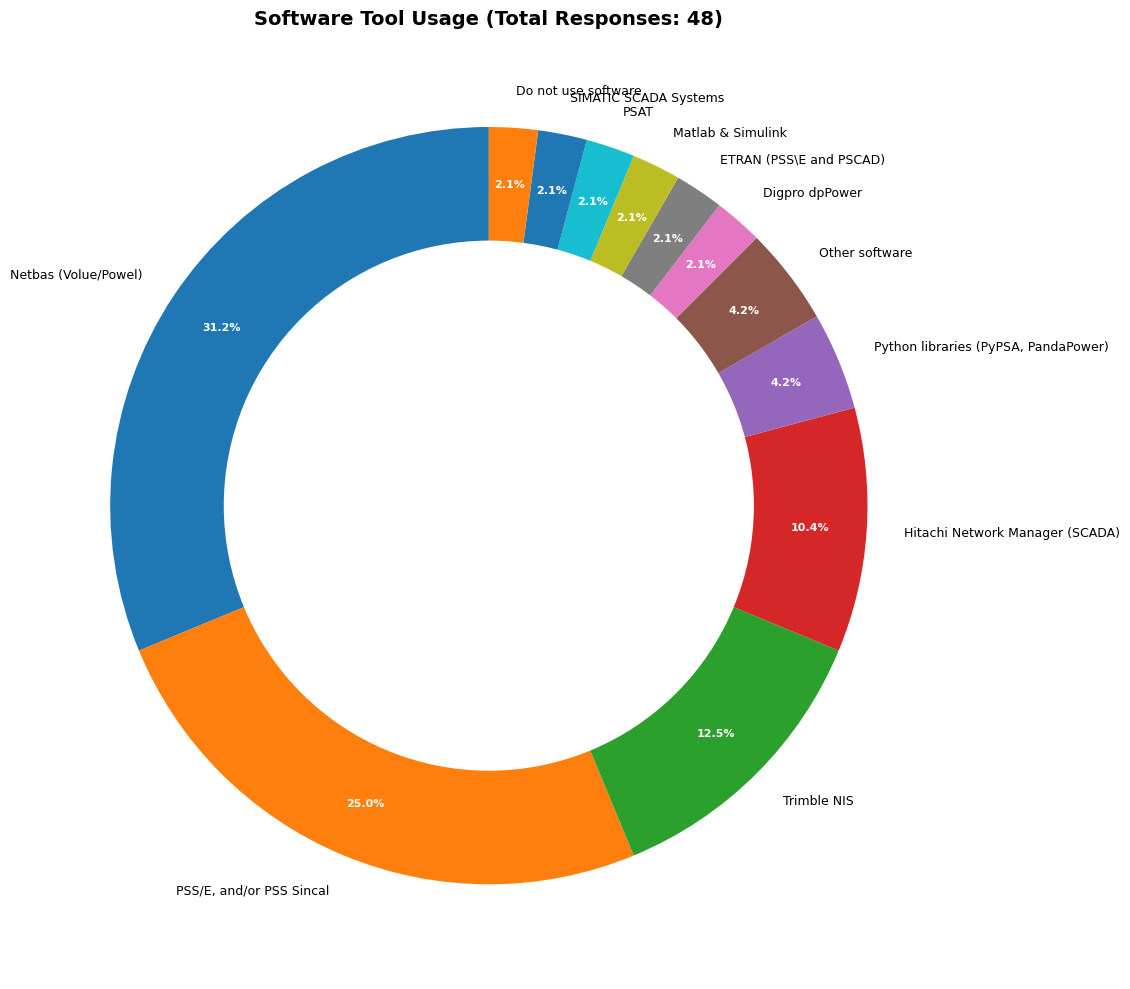

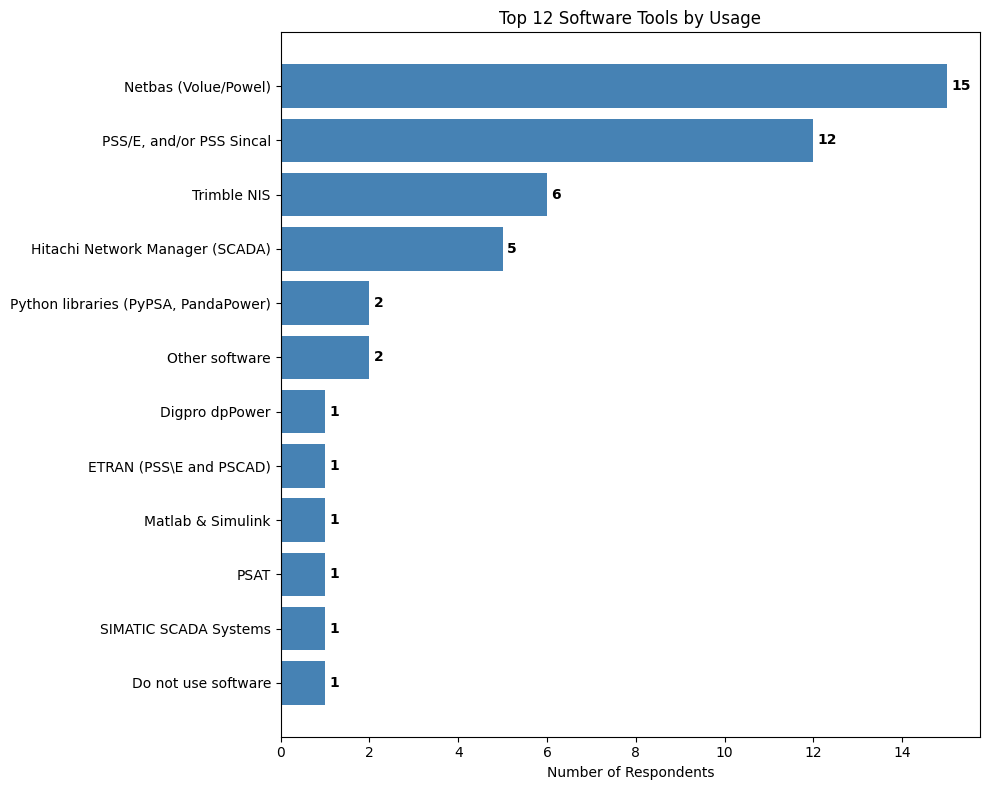

In [12]:
# Get the counts
software_counts = count_software_usage(df, SOFTWARE_MAPPING)
# Create the chart
used_software = create_software_pie_chart(software_counts, min_count=1)
# Create bar chart
top_software = create_software_bar_chart(software_counts, min_count=1, top_n=15)


# Print the results
#print("Software Usage Counts:")
#for software, count in software_counts.items():
#    if count > 0:  # Only show software that is actually used
#        print(f"{software}: {count}")

In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Define functional groups for software tools
SOFTWARE_GROUPS = {
    'SCADA Systems': [
        'AVEVA Scada',
        'CIMPLICITY Scada', 
        'Hitachi Network Manager (SCADA)',
        'SIMATIC SCADA Systems'
    ],
    'NIS (Network Information Systems)': [
        'Trimble NIS', 'Netbas (Volue/Powel)'
    ],
    'Modelling & Programming Tools': [
        'Matlab & Simulink',
        'Python libraries (PyPSA, PandaPower)',
        'DYMOLA',
        'Dynawo', 
        'Julia Power Tools',
        'OpenModellica'
    ],
    'Load Flow & Power Analysis': [
        'PSS/E, and/or PSS Sincal',
        'PowerFactory',
        'ETAP Distribution Network Analysis',
        'NEPLAN',
        'Power World',
        'IPSA',
        'PSAT'
    ],
    'Electromagnetic Transient Analysis': [
        'ATP-EMTP and/or EMTP-RV',
        'PSCAD/EMTDC',
        'RTDS, and/or OPAL-RT HYPERSIM'
    ],
    'Distribution Analysis': [
        'CYMEDIST',
        'OpenDSS',
        'GridLAB-D',
        'Synergi Electric'
    ],
    'Grid Management & Planning': [
        'General Electric Digital ADMS',
        'Digpro dpPower',
        'PowerGEM TARA',
        'SKM Power Tools'
    ],
    'Other/Specialized': [
        'DINID',
        'ERACS',
        'GridCal Sk',
        'Joulia',
        'MatDyn',
        'MathPower',
        'POWSYBL',
        'RelyPES',
        'Other software',
        'Self-developed software',
        'Do not use software'
    ]
}


In [14]:
def count_grouped_software_usage(df, software_mapping, software_groups):
    """Count software usage and organize by groups"""
    
    # First get individual software counts
    software_counts = {}
    software_type_cols = [col for col in df.columns if col.startswith("software_type")]
    
    for col in software_type_cols:
        if col in software_mapping:
            count = df[col].astype(int).sum()
            software_name = software_mapping[col]
            software_counts[software_name] = count
    
    # Create reverse mapping: software -> group
    software_to_group = {}
    for group, software_list in software_groups.items():
        for software in software_list:
            software_to_group[software] = group
    
    # Organize counts by groups
    grouped_counts = {group: {} for group in software_groups.keys()}
    group_totals = {group: 0 for group in software_groups.keys()}
    
    for software, count in software_counts.items():
        if count > 0:  # Only include used software
            group = software_to_group.get(software, 'Other/Specialized')
            grouped_counts[group][software] = count
            group_totals[group] += count
    
    return software_counts, grouped_counts, group_totals


def create_group_pie_chart_with_details(grouped_counts, group_totals, min_count=1):
    """Create pie chart showing group totals with individual software details in legend/table"""
    
    # Filter out groups with zero or low counts
    filtered_groups = {group: software_dict for group, software_dict in grouped_counts.items() 
                      if group_totals[group] >= min_count}
    filtered_totals = {group: total for group, total in group_totals.items() 
                      if total >= min_count}
    
    if not filtered_groups:
        print("No software usage data to display")
        return
    
    # Prepare data for pie chart
    group_names = list(filtered_totals.keys())
    group_counts = list(filtered_totals.values())
    
    # Colors for groups
    colors = plt.cm.Set3(np.linspace(0, 1, len(group_names)))
    
    # Create pie chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Pie chart showing group totals
    wedges, texts, autotexts = ax1.pie(group_counts, labels=group_names, colors=colors,
                                       autopct='%1.1f%%\n(%d)', startangle=90, pctdistance=0.85)
    
    # Improve text readability
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)
    
    for text in texts:
        text.set_fontsize(10)
        text.set_fontweight('bold')
    
    # Add center circle for donut effect
    centre_circle = plt.Circle((0,0), 0.65, fc='white')
    ax1.add_artist(centre_circle)
    
    ax1.set_title('Software Usage by Functional Group', fontsize=14, fontweight='bold')
    
    # Create detailed breakdown table
    ax2.axis('off')  # Hide axes for table
    
    # Prepare table data
    table_data = []
    row_colors = []
    
    for i, (group, software_dict) in enumerate(filtered_groups.items()):
        # Group header row
        table_data.append([f"{group} (Total: {filtered_totals[group]})", "Count", "%"])
        row_colors.append(colors[i])
        
        # Individual software rows
        total_group_count = filtered_totals[group]
        for software, count in sorted(software_dict.items(), key=lambda x: x[1], reverse=True):
            if count > 0:
                percentage = (count / total_group_count) * 100
                table_data.append([f"  • {software}", str(count), f"{percentage:.1f}%"])
                row_colors.append('lightgray')
        
        # Add separator row
        table_data.append(["", "", ""])
        row_colors.append('white')
    
    # Remove last separator
    if table_data:
        table_data.pop()
        row_colors.pop()
    
    # Create table
    table = ax2.table(cellText=table_data,
                     colLabels=['Software', 'Users', '% of Group'],
                     cellLoc='left',
                     loc='center',
                     colWidths=[0.6, 0.2, 0.2])
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    
    # Color code the table rows
    for i, color in enumerate(row_colors):
        for j in range(3):
            if i < len(table_data):
                cell = table[(i+1, j)]  # +1 because row 0 is header
                if table_data[i][0].startswith('  •'):  # Individual software
                    cell.set_facecolor('white')
                elif not table_data[i][0].strip():  # Separator
                    cell.set_facecolor('white')
                else:  # Group header
                    cell.set_facecolor(color)
                    cell.set_text_props(weight='bold')
    
    ax2.set_title('Detailed Breakdown', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return filtered_groups





def create_grouped_software_bar_chart(grouped_counts, group_totals):
    """Create grouped horizontal bar chart"""
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    y_pos = 0
    colors = cm.Set3(np.linspace(0, 1, len(SOFTWARE_GROUPS)))
    group_colors = {group: colors[i] for i, group in enumerate(SOFTWARE_GROUPS.keys())}
    
    yticks = []
    yticklabels = []
    
    for group, software_dict in grouped_counts.items():
        if group_totals[group] > 0:
            # Sort software within group by count
            sorted_software = sorted(software_dict.items(), key=lambda x: x[1], reverse=True)
            
            # Group header
            ax.text(-0.5, y_pos, f'{group} ({group_totals[group]} total)', 
                   fontweight='bold', fontsize=11, ha='right')
            yticks.append(y_pos)
            yticklabels.append('')
            y_pos += 1
            
            # Individual software in group
            for software, count in sorted_software:
                bars = ax.barh(y_pos, count, color=group_colors[group], alpha=0.7)
                ax.text(count + 0.2, y_pos, f'{software} ({count})', 
                       va='center', fontsize=9)
                y_pos += 1
            
            y_pos += 0.5  # Space between groups
    
    ax.set_xlabel('Number of Respondents')
    ax.set_title('Software Tool Usage by Functional Group')
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    # Get the counts



In [15]:
def create_group_pie_chart_with_extended_labels(grouped_counts, group_totals, min_count=1):
    """Create pie chart with group totals and extended labels showing individual counts"""
    
    # Filter groups
    filtered_groups = {group: software_dict for group, software_dict in grouped_counts.items() 
                      if group_totals[group] >= min_count}
    filtered_totals = {group: total for group, total in group_totals.items() 
                      if total >= min_count}
    
    # Prepare data
    group_names = list(filtered_totals.keys())
    group_counts = list(filtered_totals.values())
    
    # Create extended labels with individual software counts
    extended_labels = []
    for group in group_names:
        software_dict = filtered_groups[group]
        label = f"{group}\n(Total: {filtered_totals[group]})\n"
        
        # Add top software in this group
        sorted_software = sorted(software_dict.items(), key=lambda x: x[1], reverse=True)
        for software, count in sorted_software[:3]:  # Show top 3
            if count > 0:
                label += f"• {software}: {count}\n"
        
        if len([s for s, c in sorted_software if c > 0]) > 3:
            others = len([s for s, c in sorted_software[3:] if c > 0])
            others_count = sum([c for s, c in sorted_software[3:] if c > 0])
            if others > 0:
                label += f"• +{others} others: {others_count}"
        
        extended_labels.append(label.strip())
    
    # Colors
    colors = plt.cm.Set3(np.linspace(0, 1, len(group_names)))
    
    # Create pie chart
    fig, ax = plt.subplots(figsize=(12, 10))
    
    wedges, texts, autotexts = ax.pie(group_counts, labels=extended_labels, #colors=colors,
                                      autopct='%1.1f%%', startangle=90, pctdistance=0.85,
                                      labeldistance=1.2)
    
    # Style improvements
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)
    
    for text in texts:
        text.set_fontsize(8)
        text.set_ha('left')
    
    # Add center circle
    centre_circle = plt.Circle((0,0), 0.65, fc='white')
    ax.add_artist(centre_circle)
    
    ax.set_title('Software Usage by Functional Group\n(with individual software breakdown)', 
                fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Usage
create_group_pie_chart_with_extended_labels(grouped_counts, group_totals)


NameError: name 'grouped_counts' is not defined

In [16]:
def create_group_pie_with_table_below(grouped_counts, group_totals, min_count=1):
    """Create pie chart with group totals and detailed breakdown table"""
    
    # Filter groups
    filtered_groups = {group: software_dict for group, software_dict in grouped_counts.items() 
                      if group_totals[group] >= min_count}
    filtered_totals = {group: total for group, total in group_totals.items() 
                      if total >= min_count}
    
    if not filtered_groups:
        print("No software usage data to display")
        return
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), height_ratios=[2, 1])
    
    # Pie chart
    group_names = list(filtered_totals.keys())
    group_counts = list(filtered_totals.values())
    colors = plt.cm.Set3(np.linspace(0, 1, len(group_names)))
    
    # FIXED: Use only percentage format
    wedges, texts, autotexts = ax1.pie(group_counts, labels=group_names, #colors=colors,
                                       autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    centre_circle = plt.Circle((0,0), 0.65, fc='white')
    ax1.add_artist(centre_circle)
    ax1.set_title('Software Usage by Functional Group', fontsize=14, fontweight='bold')
    
    # Create summary table below
    ax2.axis('off')
    
    print("\nDETAILED BREAKDOWN BY GROUP:")
    print("=" * 60)
    
    for group, software_dict in filtered_groups.items():
        print(f"\n{group.upper()} (Total: {filtered_totals[group]} users)")
        print("-" * 40)
        sorted_software = sorted(software_dict.items(), key=lambda x: x[1], reverse=True)
        for software, count in sorted_software:
            if count > 0:
                percentage = (count / filtered_totals[group]) * 100
                print(f"  • {software}: {count} ({percentage:.1f}% of group)")
    
    plt.tight_layout()
    plt.show()


# Usage
create_group_pie_with_table_below(grouped_counts, group_totals)


NameError: name 'grouped_counts' is not defined

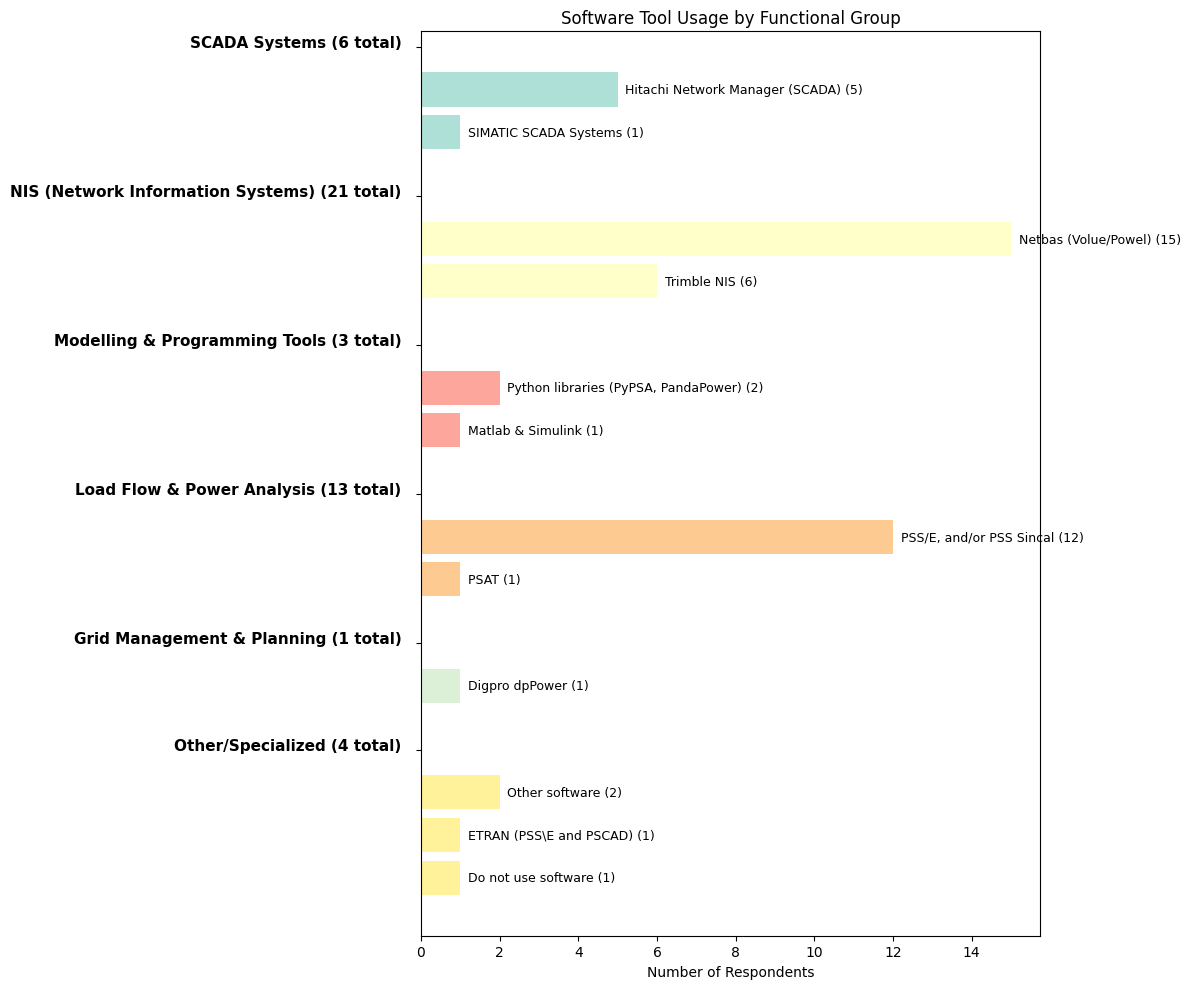

In [49]:

software_counts, grouped_counts, group_totals = count_grouped_software_usage(df, SOFTWARE_MAPPING, SOFTWARE_GROUPS)
# Create the grouped pie chart
#create_group_pie_chart_with_details(grouped_counts, group_totals)
# Create grouped bar chart
create_grouped_software_bar_chart(grouped_counts, group_totals)


## Barriers plots

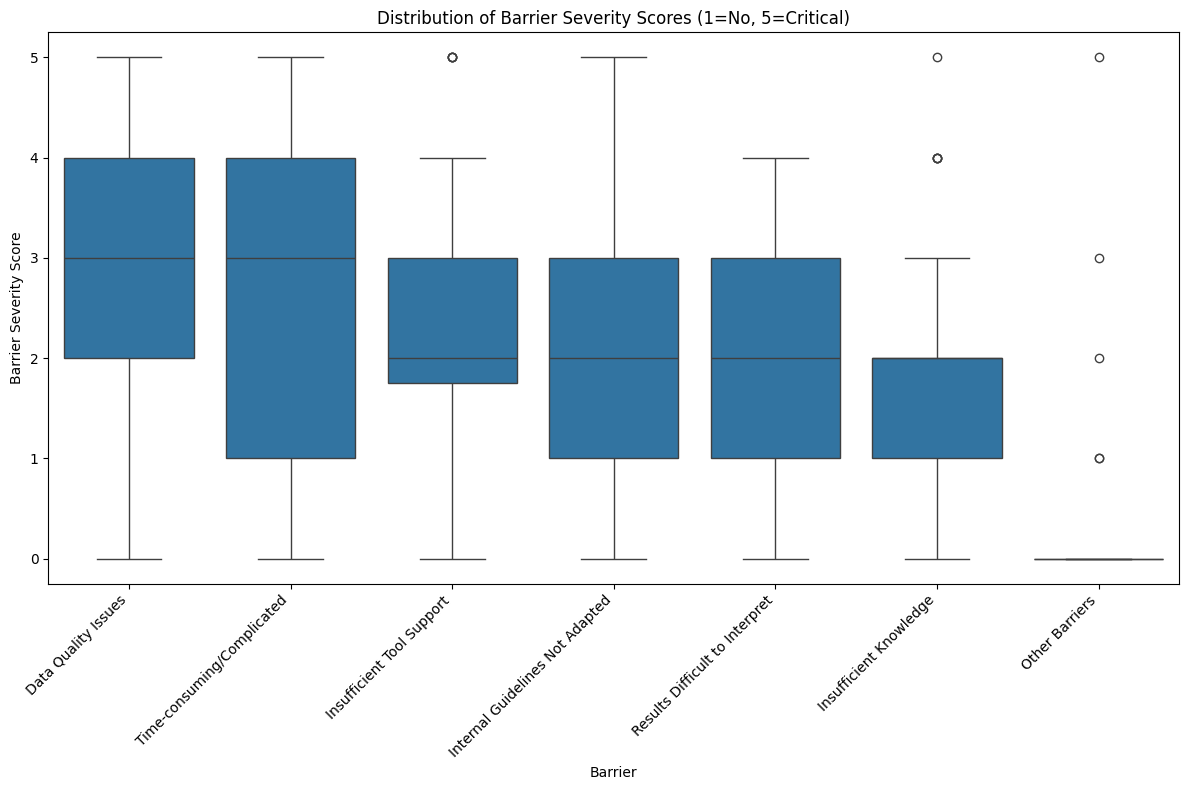

In [50]:
# Melt all barrier columns for boxplot using BARRIERS_MAPPINGS
barrier_cols = [col for col in BARRIERS_MAPPINGS if col in df.columns]
barrier_labels = [BARRIERS_MAPPINGS[col] for col in barrier_cols]

# Melt the dataframe to long format
df_barriers_melted = df.melt(value_vars=barrier_cols, var_name='BarrierCol', value_name='Score')
df_barriers_melted['Barrier'] = df_barriers_melted['BarrierCol'].map(BARRIERS_MAPPINGS)

# Sort barriers by average score
barrier_order = (
    df_barriers_melted.groupby('Barrier')['Score']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
df_barriers_melted['Barrier'] = pd.Categorical(df_barriers_melted['Barrier'], categories=barrier_order, ordered=True)

plt.figure(figsize=(12,8))
sns.boxplot(data=df_barriers_melted, x='Barrier', y='Score')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Barrier Severity Score")
plt.xlabel("Barrier")
plt.title("Distribution of Barrier Severity Scores (1=No, 5=Critical)")
plt.tight_layout()
plt.show()

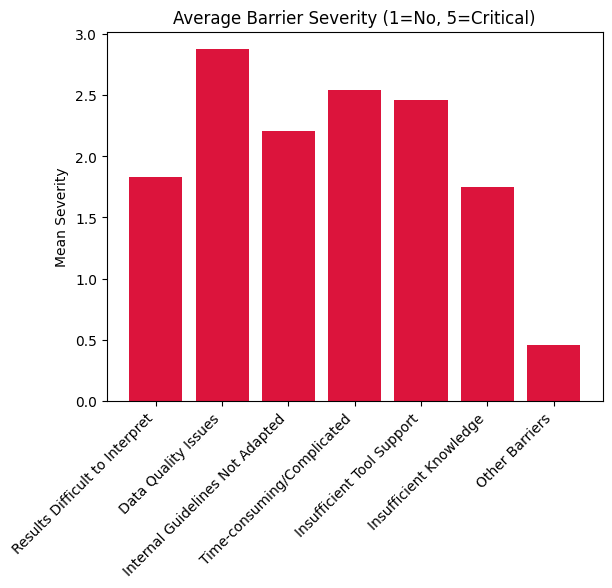

In [ ]:
    # Barrier severity
bar_sev = defaultdict(list)
for col, name in BARRIERS_MAPPINGS.items():
    if col in df:
        bar_sev[name].append(df[col].mean())
bars, avgs = list(bar_sev.keys()), [np.mean(bar_sev[k]) for k in bar_sev]
plt.bar(bars, avgs, color='crimson')
plt.ylabel("Mean Severity")
plt.title("Average Barrier Severity (1=No, 5=Critical)")
plt.xticks(rotation=45, ha='right')
plt.show()


# Box plot: Distribution of scores per method, sorted by average
df_barriers_melted = df.melt(value_vars=Method_cols, var_name='Method', value_name='Score')
df_methods_melted['Method'] = df_methods_melted['Method'].str.replace('Methods-', '').str.strip()
df_methods_melted['Method'] = pd.Categorical(df_methods_melted['Method'], categories=sorted_names, ordered=True)

plt.figure(figsize=(12,8))
sns.boxplot(data=df_methods_melted, x='Method', y='Score')
plt.xticks(rotation=90)
plt.ylabel("Prominence Score")
plt.xlabel("Method")
plt.tight_layout()
plt.show()

### Current used barrier plot

In [17]:
def reorder_barriers_by_severity(barrier_labels, critical, moderate, small, not_barrier, not_relevant):
    """Reorder barriers by total severity, but keep 'Other barriers' at bottom"""
    
    # Calculate total severity score for each barrier (critical gets most weight)
    severity_scores = critical + moderate * 0.5 + small * 0.2
    
    # Find "Other barriers" index
    other_barriers_idx = None
    for i, label in enumerate(barrier_labels):
        if 'other' in label.lower() and 'barrier' in label.lower():
            other_barriers_idx = i
            break
    
    # Create list of indices excluding "Other barriers"
    indices = [i for i in range(len(barrier_labels)) if i != other_barriers_idx]
    
    # Sort by severity score (descending - most severe first)
    sorted_indices = sorted(indices, key=lambda i: severity_scores[i], reverse=True)
    
    # FIXED: Add "Other barriers" at the BEGINNING (will be at bottom of plot)
    if other_barriers_idx is not None:
        sorted_indices.insert(0, other_barriers_idx)  # Insert at beginning
    
    # Reorder all arrays
    reordered_labels = [barrier_labels[i] for i in sorted_indices]
    reordered_critical = [critical[i] for i in sorted_indices]
    reordered_moderate = [moderate[i] for i in sorted_indices]
    reordered_small = [small[i] for i in sorted_indices]
    reordered_not_barrier = [not_barrier[i] for i in sorted_indices]
    reordered_not_relevant = [not_relevant[i] for i in sorted_indices]
    
    return (reordered_labels, np.array(reordered_critical), np.array(reordered_moderate), 
            np.array(reordered_small), np.array(reordered_not_barrier), np.array(reordered_not_relevant))


In [19]:
def create_diverging_chart_from_aggregated_ordered(aggregated_data, barriers_map=None, ax=None, title=None):
    """Create diverging chart with proper ordering and optional subplot support"""
    
    # Get barrier labels
    barrier_labels = []
    for key in aggregated_data.keys():
        if barriers_map and key in barriers_map:
            barrier_labels.append(barriers_map[key])
        else:
            clean_name = key.replace('software_barrieres.', '').replace('indicators_barrieres.', '')
            barrier_labels.append(f"Barrier {clean_name}")
    
    # Prepare data
    critical = np.array([stats[4] + stats[5] for stats in aggregated_data.values()])
    moderate = np.array([stats[3] for stats in aggregated_data.values()])
    small = np.array([stats[2] for stats in aggregated_data.values()])  # Fixed: was stats[3]
    not_barrier = np.array([stats[1] for stats in aggregated_data.values()])
    not_relevant = np.array([stats[0] for stats in aggregated_data.values()])
    
    # Reorder by severity
    (barrier_labels, critical, moderate, small, not_barrier, not_relevant) = reorder_barriers_by_severity(
        barrier_labels, critical, moderate, small, not_barrier, not_relevant)
    
    # Use provided axis or create new one
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
        standalone = True
    else:
        standalone = False
    
    y_pos = np.arange(len(barrier_labels))
    
    # Create diverging bars
    ax.barh(y_pos, -not_relevant, left=-not_barrier, color='lightblue', label='Not relevant/No opinion (0)')
    ax.barh(y_pos, -not_barrier, color='lightgreen', label='Not a barrier (1)')
    ax.barh(y_pos, small, left=0, color='lightgray', label='Small (2)')
    ax.barh(y_pos, moderate, left=small, color='yellow', label='Moderate (3)')
    ax.barh(y_pos, critical, left=small+moderate, color='red', label='Critical barrier (4-5)')
    
    # Add percentage labels
    for i in range(len(barrier_labels)):
        if critical[i] > 5:
            ax.text(small[i] + moderate[i] + critical[i]/2, i, f'{critical[i]:.0f}%', 
                   ha='center', va='center', color='white', fontweight='bold')
        if not_barrier[i] > 5:
            ax.text(-not_barrier[i]/2, i, f'{not_barrier[i]:.0f}%', 
                   ha='center', va='center', color='black', fontweight='bold')
        if not_relevant[i] > 5:
            ax.text(-not_barrier[i]-not_relevant[i]/2, i, f'{not_relevant[i]:.0f}%', 
                   ha='center', va='center', color='black', fontweight='bold')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(barrier_labels)
    ax.set_xlabel('Percentage of Respondents')
    ax.set_title(title or 'Barrier Severity Distribution')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.axvline(x=0, color='black', linewidth=0.5)
    
    if standalone:
        plt.tight_layout()
        plt.show()
    
    return barrier_labels, critical, moderate, small, not_barrier, not_relevant


In [20]:
def create_diverging_barrier_chart_subplot(df, barrier_cols, barrier_labels, ax, title=None):
    """Helper function: Create diverging barrier chart for subplot with proper ordering and legend"""
    
    # Calculate percentages for each severity level (0-5 scale)
    barrier_stats = []
    for col in barrier_cols:
        counts = df[col].value_counts().reindex(range(0, 6), fill_value=0)
        total = counts.sum()
        if total == 0:
            percentages = np.zeros(6)
        else:
            percentages = (counts / total * 100).round(1)
        barrier_stats.append(percentages)
    
    # Extract severity arrays
    not_relevant = np.array([stats[0] for stats in barrier_stats])
    not_barrier = np.array([stats[1] for stats in barrier_stats])
    small = np.array([stats[2] for stats in barrier_stats])
    moderate = np.array([stats[3] for stats in barrier_stats])
    critical = np.array([stats[4] + stats[5] for stats in barrier_stats])
    
    # Reorder barriers: most severe at top, "Other Barriers" at bottom
    severity_scores = critical + moderate * 0.5 + small * 0.2
    
    # Find "Other Barriers" index
    other_idx = None
    for i, label in enumerate(barrier_labels):
        if 'other' in label.lower() and ('barrier' in label.lower() or 'barrieres' in label.lower()):
            other_idx = i
            break
    
    # Create sorted indices
    indices = [i for i in range(len(barrier_labels)) if i != other_idx]
    sorted_indices = sorted(indices, key=lambda i: severity_scores[i], reverse=False)  # Most severe first
    
    # FIXED: Add "Other Barriers" at the BEGINNING (plots at bottom)
    if other_idx is not None:
        sorted_indices.insert(0, other_idx)
    
    # Reorder all data
    ordered_labels = [barrier_labels[i] for i in sorted_indices]
    ordered_arrays = [not_relevant, not_barrier, small, moderate, critical]
    ordered_arrays = [np.array([arr[i] for i in sorted_indices]) for arr in ordered_arrays]
    
    ordered_not_relevant, ordered_not_barrier, ordered_small, ordered_moderate, ordered_critical = ordered_arrays
    y_pos = np.arange(len(ordered_labels))
    
    # Plot diverging bars
    ax.barh(y_pos, -ordered_not_relevant, left=-ordered_not_barrier, 
            color='lightblue', label='Not relevant/No opinion (0)')
    ax.barh(y_pos, -ordered_not_barrier, color='lightgreen', label='Not a barrier (1)')
    ax.barh(y_pos, ordered_small, left=0, color='lightgray', label='Small (2)')
    ax.barh(y_pos, ordered_moderate, left=ordered_small, color='yellow', label='Moderate (3)')
    ax.barh(y_pos, ordered_critical, left=ordered_small + ordered_moderate, 
            color='red', label='Critical barrier (4-5)')
    
    # Add percentage labels
    for i in range(len(ordered_labels)):
        if ordered_critical[i] > 5:
            ax.text(ordered_small[i] + ordered_moderate[i] + ordered_critical[i]/2, i, 
                   f'{ordered_critical[i]:.0f}%', ha='center', va='center', 
                   color='white', fontweight='bold')
        if ordered_moderate[i] > 5:
            ax.text(ordered_small[i] + ordered_moderate[i]/2, i, 
                   f'{ordered_critical[i]:.0f}%', ha='center', va='center', 
                   color='black', fontweight='bold')
        if ordered_small[i] > 5:
            ax.text(ordered_small[i]/2, i, 
                   f'{ordered_critical[i]:.0f}%', ha='center', va='center', 
                   color='black', fontweight='bold')
        if ordered_not_barrier[i] > 5:
            ax.text(-ordered_not_barrier[i]/2, i, 
                    f'{ordered_not_barrier[i]:.0f}%', ha='center', va='center', 
                    color='black', fontweight='bold')
        if ordered_not_relevant[i] > 5:
            ax.text(-ordered_not_barrier[i] - ordered_not_relevant[i]/2, i, 
                   f'{ordered_not_relevant[i]:.0f}%', ha='center', va='center', 
                   color='black', fontweight='bold')
    
    # Format axes
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ordered_labels)
    ax.set_xlabel('Percentage of Respondents')
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    
    # IMPROVED: Better legend positioning for subplots
    #ax.legend(loc='lower right', fontsize=7, frameon=True, fancybox=True, shadow=True)
    ax.axvline(x=0, color='black', linewidth=0.5)
    
    return ax


In [21]:
def create_diverging_chart_from_aggregated_for_subplot(aggregated_data, barriers_map, ax, title):
    """Create diverging chart from aggregated data for subplot use"""
    
    # Get barrier labels
    barrier_labels = []
    for key in aggregated_data.keys():
        if barriers_map and key in barriers_map:
            barrier_labels.append(barriers_map[key])
        else:
            clean_name = key.replace('software_barrieres.', '').replace('indicators_barrieres.', '')
            barrier_labels.append(f"Barrier {clean_name}")
    
    # Prepare data arrays
    critical = np.array([stats[4] + stats[5] for stats in aggregated_data.values()])
    moderate = np.array([stats[3] for stats in aggregated_data.values()])
    small = np.array([stats[2] for stats in aggregated_data.values()]) 
    not_barrier = np.array([stats[1] for stats in aggregated_data.values()])
    not_relevant = np.array([stats[0] for stats in aggregated_data.values()])
    
    # Reorder barriers by severity (most severe at top, "Other Barriers" at bottom)
    severity_scores = critical + moderate * 0.5 + small * 0.1
    
    # Find "Other Barriers" index
    other_idx = None
    for i, label in enumerate(barrier_labels):
        if 'other' in label.lower() and ('barrier' in label.lower() or 'barrieres' in label.lower()):
            other_idx = i
            break
    
    # Create sorted indices
    indices = [i for i in range(len(barrier_labels)) if i != other_idx]
    sorted_indices = sorted(indices, key=lambda i: severity_scores[i], reverse=False)  # Most severe first
    
    # Add "Other Barriers" at the BEGINNING (will plot at bottom)
    if other_idx is not None:
        sorted_indices.insert(0, other_idx)  # Insert at beginning, not append at end
    
    # Reorder all data
    ordered_labels = [barrier_labels[i] for i in sorted_indices]
    ordered_critical = np.array([critical[i] for i in sorted_indices])
    ordered_moderate = np.array([moderate[i] for i in sorted_indices])
    ordered_small = np.array([small[i] for i in sorted_indices])
    ordered_not_barrier = np.array([not_barrier[i] for i in sorted_indices])
    ordered_not_relevant = np.array([not_relevant[i] for i in sorted_indices])
    
    y_pos = np.arange(len(ordered_labels))
    
    # Create diverging bars
    ax.barh(y_pos, -ordered_not_relevant, left=-ordered_not_barrier, 
            color='lightblue', label='Not relevant/No opinion (0)')
    ax.barh(y_pos, -ordered_not_barrier, color='lightgreen', label='Not a barrier (1)')
    ax.barh(y_pos, ordered_small, left=0, color='lightgray', label='Small (2)')
    ax.barh(y_pos, ordered_moderate, left=ordered_small, color='yellow', label='Moderate (3)')
    ax.barh(y_pos, ordered_critical, left=ordered_small + ordered_moderate, 
            color='red', label='Critical barrier (4-5)')
    
    # Add percentage labels
    for i in range(len(ordered_labels)):
        if ordered_critical[i] > 5:
            ax.text(ordered_small[i] + ordered_moderate[i] + ordered_critical[i]/2, i, 
                   f'{ordered_critical[i]:.0f}%', ha='center', va='center', 
                   color='white', fontweight='bold')
        if ordered_moderate[i] > 5:
            ax.text(ordered_small[i] + ordered_moderate[i]/2, i, 
                   f'{ordered_critical[i]:.0f}%', ha='center', va='center', 
                   color='black', fontweight='bold')
        if ordered_small[i] > 5:
            ax.text(ordered_small[i]/2, i, 
                   f'{ordered_critical[i]:.0f}%', ha='center', va='center', 
                   color='black', fontweight='bold')
        if ordered_not_barrier[i] > 5:
            ax.text(-ordered_not_barrier[i]/2, i, 
                    f'{ordered_not_barrier[i]:.0f}%', ha='center', va='center', 
                    color='black', fontweight='bold')
        if ordered_not_relevant[i] > 5:
            ax.text(-ordered_not_barrier[i] - ordered_not_relevant[i]/2, i, 
                   f'{ordered_not_relevant[i]:.0f}%', ha='center', va='center', 
                   color='black', fontweight='bold')
    
    # Format axes
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ordered_labels)
    ax.set_xlabel('Percentage of Respondents')
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # FIXED: Better legend positioning for main plot
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    ax.axvline(x=0, color='black', linewidth=0.5)
    
    return ax


In [22]:
def create_comprehensive_barrier_analysis(df, barriers_mappings):
    """Create 2x2 layout: main plot spans top row, two subplots on bottom row"""
    from matplotlib.gridspec import GridSpec
    
    # Create figure with custom grid
    fig = plt.figure(figsize=(24, 17))
    gs = GridSpec(2, 2, figure=fig, height_ratios=[2, 1], hspace=0.3, wspace=0.3)
    
    # Define axes
    ax_main = fig.add_subplot(gs[0, :])    # Main plot spans both columns in top row
    ax_software = fig.add_subplot(gs[1, 0])  # Bottom left (cell 1,2)
    ax_indicators = fig.add_subplot(gs[1, 1])  # Bottom right (cell 2,2)
    
    # 1. MAIN PLOT: Combined barriers (top row, spanning both columns)
    barrier_cols_combined = [col for col in df.columns 
                            if ('barriers' in col.lower() or 'barrieres' in col.lower())
                            and ('software' in col.lower() or 'indicators' in col.lower())
                            and not col.lower().endswith('desc')]
    
    # Get aggregated data for combined plot
    aggregated_barriers = aggregate_barriers_by_suffix(df, 
        suffixes=['software_barrieres', 'indicators_barriers'])
    
    # Create combined labels
    combined_labels = [barriers_mappings.get(key, key.replace('software_barrieres.', '').replace('indicators_barrieres.', ''))
                      for key in aggregated_barriers.keys()]
    
    # Use the aggregated plotting function for main plot
    create_diverging_chart_from_aggregated_for_subplot(aggregated_barriers, barriers_mappings, 
                                                      ax_main, 'Combined Barrier Severity Distribution')
    
    # 2. BOTTOM LEFT: Software barriers only
    software_cols = [col for col in df.columns 
                    if ('barriers' in col.lower() or 'barrieres' in col.lower()) 
                    and 'software' in col.lower() and not col.lower().endswith('desc')]
    software_labels = [barriers_mappings.get(col, col) for col in software_cols]
    
    if software_cols:
        create_diverging_barrier_chart_subplot(df, software_cols, software_labels, 
                                              ax_software, 'Software Barriers Only')
    
    # 3. BOTTOM RIGHT: Indicator barriers only  
    indicator_cols = [col for col in df.columns 
                     if ('barriers' in col.lower() or 'barrieres' in col.lower()) 
                     and 'indicators' in col.lower() and not col.lower().endswith('desc')]
    indicator_labels = [barriers_mappings.get(col, col) for col in indicator_cols]
    
    if indicator_cols:
        create_diverging_barrier_chart_subplot(df, indicator_cols, indicator_labels, 
                                              ax_indicators, 'Indicator Barriers Only')
    
    plt.tight_layout()
    plt.show()
    
    return fig




NameError: name 'aggregate_barriers_by_suffix' is not defined

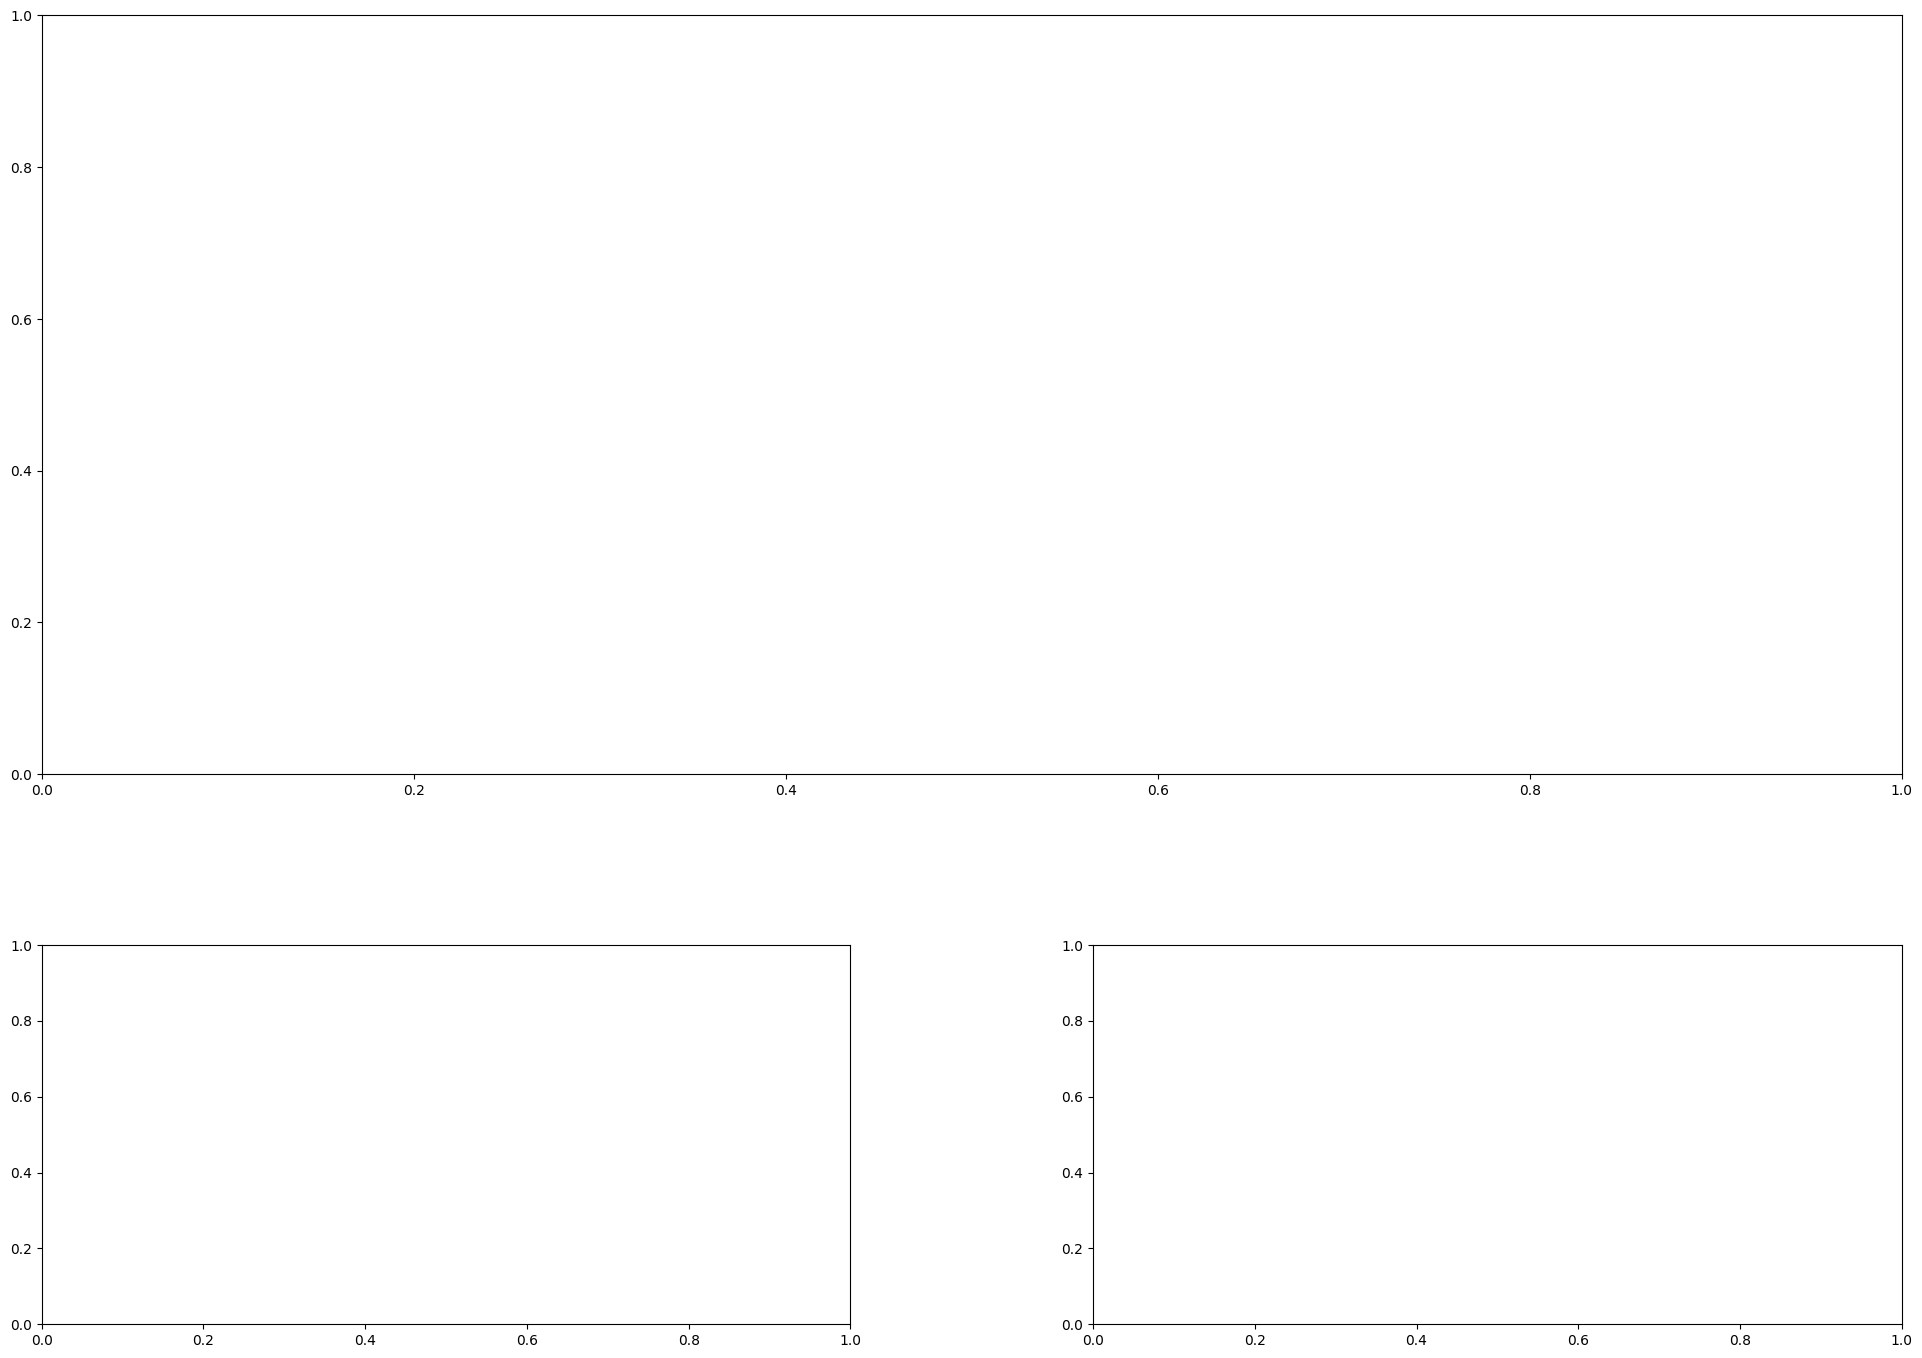

In [23]:

comprehensive_fig = create_comprehensive_barrier_analysis(df, BARRIERS_MAPPINGS)

### Barriers plot (working but new one to refine even further)

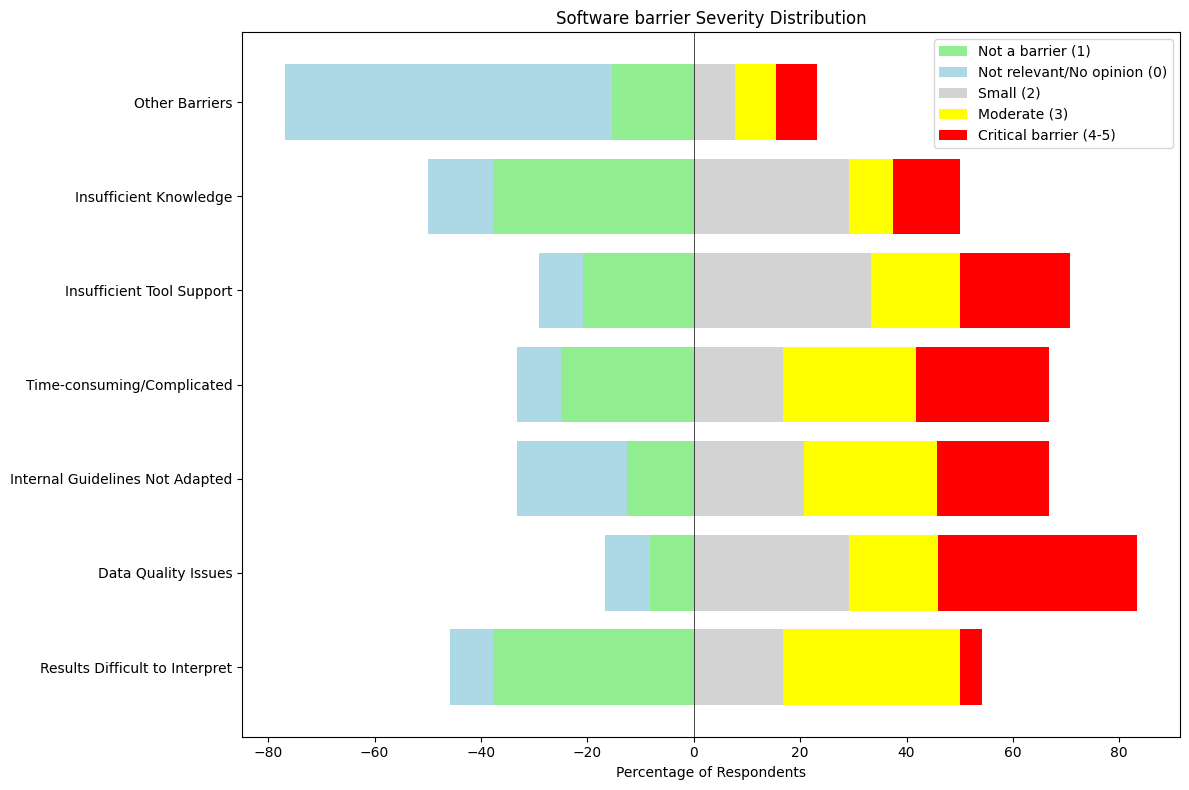

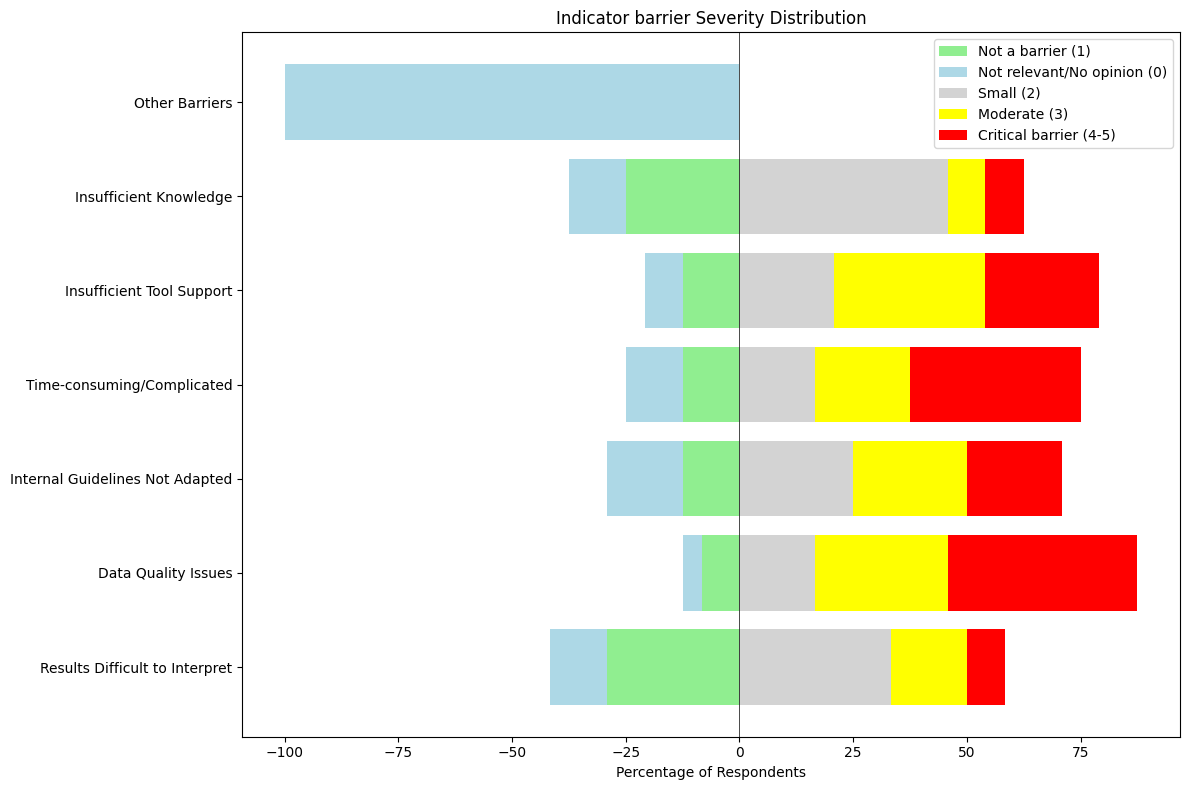

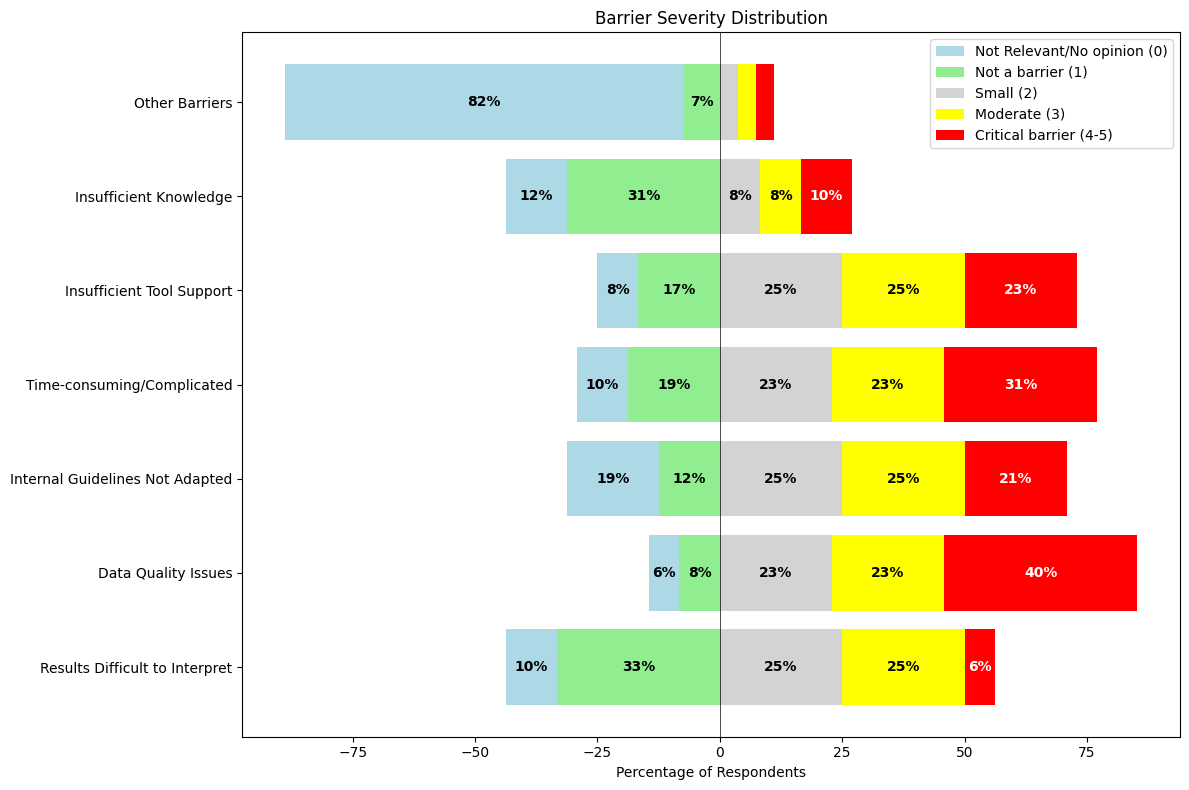

Barrier names used:
  - Results Difficult to Interpret
  - Data Quality Issues
  - Internal Guidelines Not Adapted
  - Time-consuming/Complicated
  - Insufficient Tool Support
  - Insufficient Knowledge
  - Other Barriers


In [ ]:
### Plotting the diverging view
def create_diverging_barrier_chart(df, barrier_cols, barrier_labels, title=None):
    """Create diverging chart showing critical vs non-critical barriers"""
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Calculate percentages for each severity level
    barrier_stats = []
    for col in barrier_cols:
        counts = df[col].value_counts().reindex(range(0, 6), fill_value=0)
        total = counts.sum()
        percentages = (counts / total * 100).round(1)
        barrier_stats.append(percentages)
    # Prepare diverging data (critical = 4,5; neutral = 3; non-critical = 1,2)
    critical = np.array([stats[4] + stats[5] for stats in barrier_stats])
    moderate = np.array([stats[3] for stats in barrier_stats])
    small = np.array([stats[2] for stats in barrier_stats])
    non_critical = np.array([stats[1] for stats in barrier_stats])
    not_relevant = np.array([stats[0] for stats in barrier_stats])
    
    y_pos = np.arange(len(barrier_labels))
    
    # Plot diverging bars
    ax.barh(y_pos, -not_relevant, left=-non_critical, color='lightblue', label='Not relevant/No opinion (0)')
    ax.barh(y_pos, -non_critical, color='lightgreen', label='Not a barrier (1)')
    ax.barh(y_pos, small, left=0, color='lightgray', label='Small (2)')
    ax.barh(y_pos, moderate, left=small, color='yellow', label='Moderate (3)')
    ax.barh(y_pos, critical, left=small+moderate, color='red', label='Critical barrier (4-5)')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(barrier_labels)
    ax.set_xlabel('Percentage of Respondents')
    if title: ax.set_title(title)
    else: ax.set_title('Barrier Severity Distribution (Diverging View)')
    ax.legend()
    ax.axvline(x=0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

def aggregate_barriers_by_suffix(df, suffixes=['software_barrieres', 'indicators_barrieres']):
    """Automatically group and combine barriers with different suffixes, preserving original mapping"""
    import re
    
    # Find all barrier columns
    all_barrier_cols = [col for col in df.columns 
                       if any(suffix in col.lower() for suffix in suffixes)]
    
    # Group columns by their numeric suffix (e.g., .1, .2, .3)
    barrier_groups = {}
    barrier_name_mapping = {}  # Map barrier numbers to original column names
    
    for col in all_barrier_cols:
        # Extract the number from column name (e.g., '1' from 'software_barrieres.1')
        match = re.search(r'\.(\d+)$', col)
        if match:
            barrier_num = match.group(1)
            barrier_groups.setdefault(barrier_num, []).append(col)
            # Keep track of original column name for mapping
            if barrier_num not in barrier_name_mapping:
                barrier_name_mapping[barrier_num] = col
    
    # Aggregate counts for each barrier group
    aggregated_data = {}
    
    for barrier_num, cols in barrier_groups.items():
        # Combine counts from all columns in this group
        combined_counts = np.zeros(6)  # For ratings 1-5
        total_responses = 0
        
        for col in cols:
            if col in df.columns:
                counts = df[col].value_counts().reindex(range(0, 6), fill_value=0)
                combined_counts += counts.values
                total_responses += counts.sum()
        
        # Convert to percentages
        if total_responses > 0:
            percentages = (combined_counts / total_responses * 100).round(1)
            # Use original column name as key for proper mapping
            original_col = barrier_name_mapping[barrier_num]
            aggregated_data[original_col] = percentages
    
    return aggregated_data

def create_diverging_chart_from_aggregated(aggregated_data, barriers_map=None):
    """Create diverging chart from aggregated barrier data with proper names"""
    
    # Get barrier labels using the original column names as keys
    barrier_labels = []
    for key in aggregated_data.keys():
        if barriers_map and key in barriers_map:
            barrier_labels.append(barriers_map[key])
        else:
            # Fallback to cleaning up the column name
            clean_name = key.replace('software_barrieres.', 'Software Barrier ').replace('indicators_barrieres.', 'Indicator Barrier ')
            barrier_labels.append(clean_name)
    
    # Prepare data for plotting with NEW SEVERITY LEVELS
    critical = np.array([stats[4] + stats[5] for stats in aggregated_data.values()])  # 4,5 ratings = Critical
    moderate = np.array([stats[3] for stats in aggregated_data.values()])            # 3 rating = Moderate  
    small = np.array([stats[3] for stats in aggregated_data.values()])               # 2 rating = Small
    not_barrier = np.array([stats[1] for stats in aggregated_data.values()])         # 1 rating = Not a barrier
    not_relevant = np.array([stats[0] for stats in aggregated_data.values()])         # 0 rating = Not Relevant
    
    
    y_pos = np.arange(len(barrier_labels))
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create diverging bars with NEW COLOR SCHEME
    ax.barh(y_pos, -not_relevant, left = -not_barrier, color='lightblue', label='Not Relevant/No opinion (0)')
    ax.barh(y_pos, -not_barrier, color='lightgreen', label='Not a barrier (1)')
    ax.barh(y_pos, small, left=0, color='lightgray', label='Small (2)')
    ax.barh(y_pos, moderate, left=small, color='yellow', label='Moderate (3)')
    ax.barh(y_pos, critical, left=small+moderate, color='red', label='Critical barrier (4-5)')
    
    # Add percentage labels
    for i in range(len(barrier_labels)):
        if critical[i] > 5:  # Only show if > 5%
            ax.text(small[i] + moderate[i] + critical[i]/2, i, f'{critical[i]:.0f}%', 
                   ha='center', va='center', color='white', fontweight='bold')
        if not_barrier[i] > 5:
            ax.text(-not_barrier[i]/2, i, f'{not_barrier[i]:.0f}%', 
                   ha='center', va='center', color='black', fontweight='bold')
        if not_barrier[i] > 5:
            ax.text(-not_barrier[i]-not_relevant[i]/2, i, f'{not_relevant[i]:.0f}%', 
                   ha='center', va='center', color='black', fontweight='bold')
        if moderate[i] > 8:  # Show moderate labels if substantial
            ax.text(small[i] + moderate[i]/2, i, f'{moderate[i]:.0f}%', 
                   ha='center', va='center', color='black', fontweight='bold')
        if small[i] > 8:  # Show moderate labels if substantial
            ax.text(small[i]/2, i, f'{small[i]:.0f}%', 
                   ha='center', va='center', color='black', fontweight='bold')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(barrier_labels)
    ax.set_xlabel('Percentage of Respondents')
    ax.set_title('Barrier Severity Distribution')
    ax.legend()
    ax.axvline(x=0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return barrier_labels, critical, moderate, small, not_barrier


#Software only
# Define barrier columns and labels
barrier_cols = [col for col in df.columns 
            if ('barriers' in col.lower() or 'barrieres' in col) 
            and 'software' in col.lower()         
            #and 'indicators' in col.lower() 
            and not col.lower().endswith('desc')]
barrier_labels = [BARRIERS_MAPPINGS.get(col, col) for col in barrier_cols]
create_diverging_barrier_chart(df, barrier_cols, barrier_labels, title='Software barrier Severity Distribution')

#Indicator only
# Define barrier columns and labels
barrier_cols = [col for col in df.columns 
            if ('barriers' in col.lower() or 'barrieres' in col) 
            #and 'software' in col.lower()         
            and 'indicators' in col.lower() 
            and not col.lower().endswith('desc')]
barrier_labels = [BARRIERS_MAPPINGS.get(col, col) for col in barrier_cols]
create_diverging_barrier_chart(df, barrier_cols, barrier_labels, title='Indicator barrier Severity Distribution')

#Both Software and Indicator
# Combined Software and Indicators with proper barrier names
barrier_cols = [col for col in df.columns 
                if ('barriers' in col.lower() or 'barrieres' in col.lower())
                and ('software' in col.lower() or 'indicators' in col.lower())
                and not col.lower().endswith('desc')]

# Aggregate barriers by suffix (now preserves original column names for mapping)
aggregated_barriers = aggregate_barriers_by_suffix(df, 
    suffixes=['software_barrieres', 'indicators_barriers'])

# Create clean diverging chart with proper barrier names
barrier_labels, critical, moderate, small, not_barrier = create_diverging_chart_from_aggregated(
    aggregated_barriers, barriers_map=BARRIERS_MAPPINGS)

print("Barrier names used:")
for label in barrier_labels:
    print(f"  - {label}")



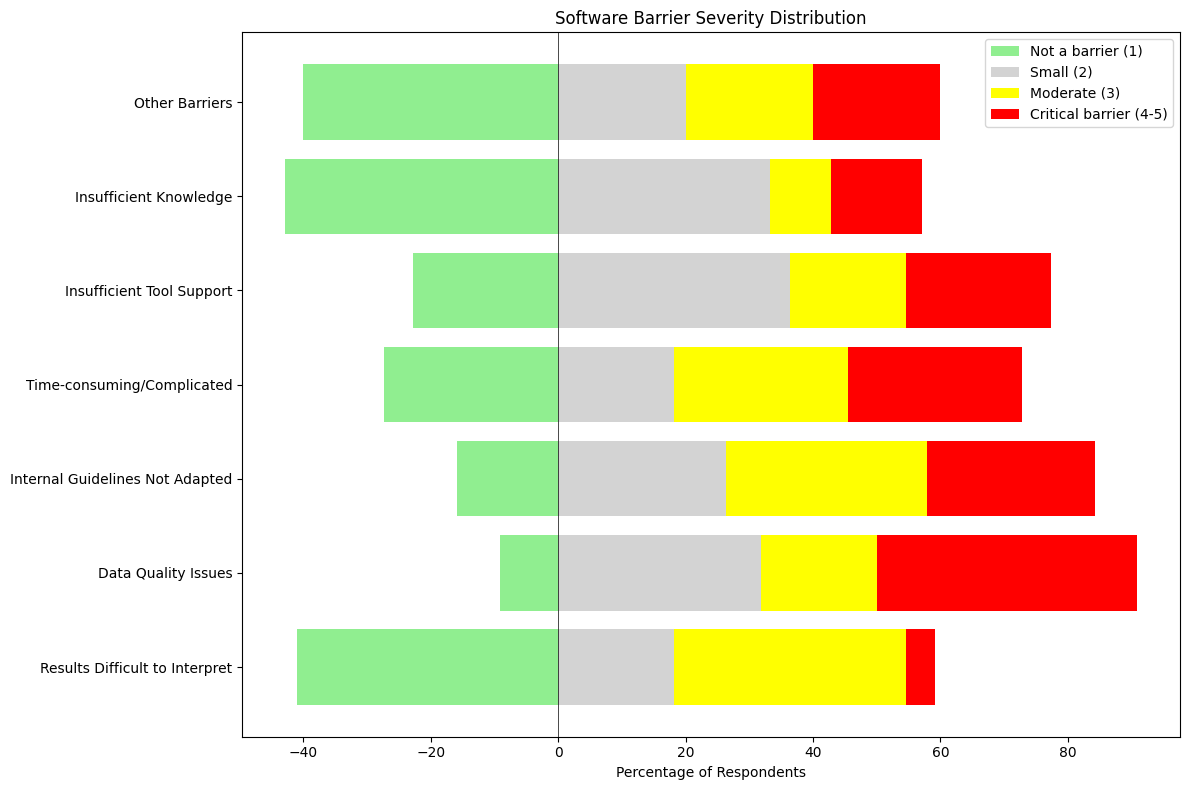

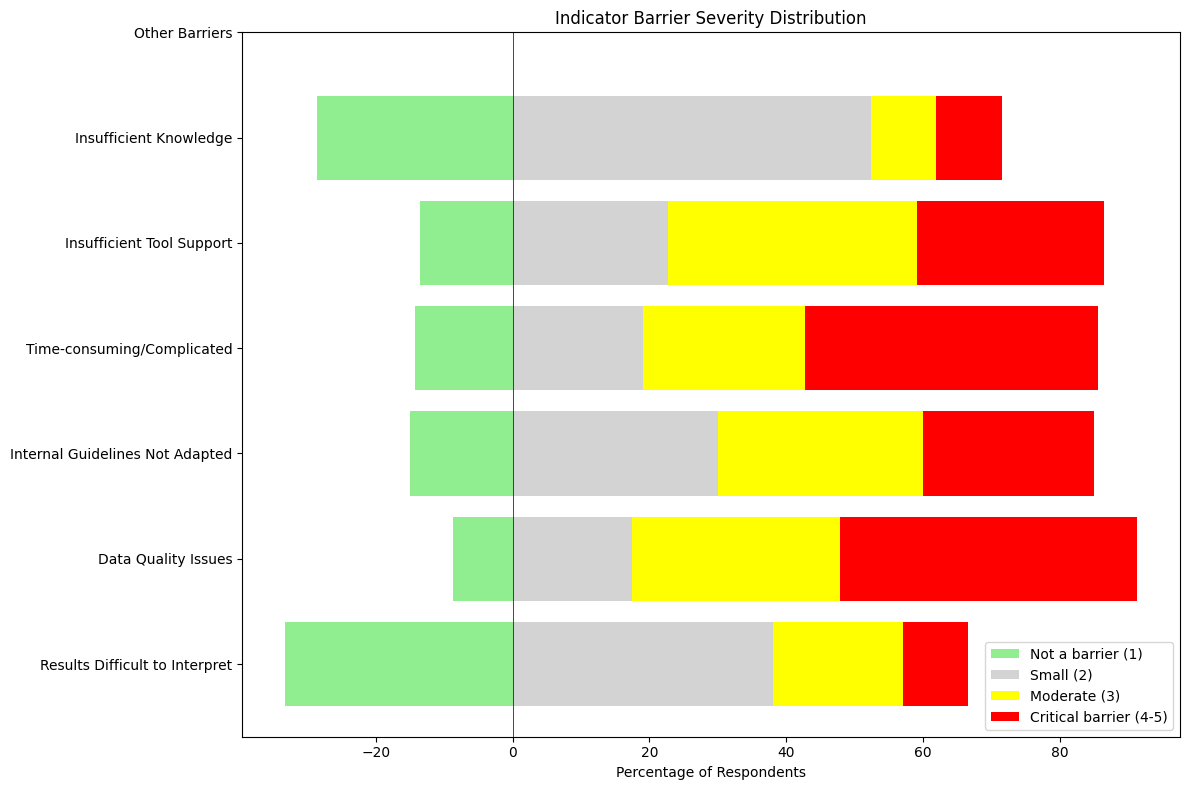

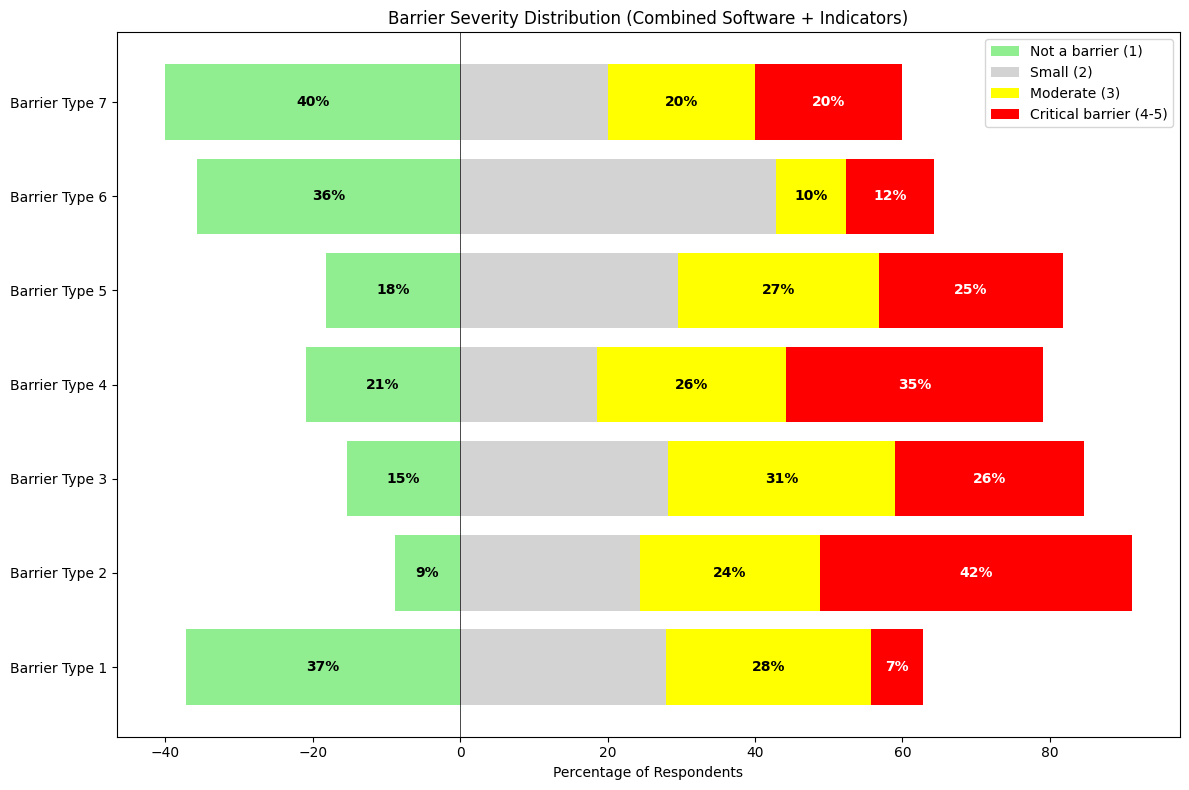


BARRIER SEVERITY SUMMARY (Updated Classification):
1 = Not a barrier | 2 = Small | 3 = Moderate | 4-5 = Critical
------------------------------------------------------------
Barrier                             Critical   Moderate   Small    Not Barrier 
---------------------------------------------------------------------------
Barrier Type 2                         42.3%      24.4%    24.4%         8.9%
Barrier Type 4                         34.9%      25.6%    18.6%        20.9%
Barrier Type 3                         25.6%      30.8%    28.2%        15.4%
Barrier Type 5                         25.0%      27.3%    29.5%        18.2%
Barrier Type 7                         20.0%      20.0%    20.0%        40.0%
Barrier Type 6                         11.9%       9.5%    42.9%        35.7%
Barrier Type 1                          7.0%      27.9%    27.9%        37.2%

TOP 5 CRITICAL BARRIERS:
------------------------------
1. Barrier Type 2: 42.3% critical
2. Barrier Type 4: 34.9% critica

In [96]:
def create_diverging_chart_from_aggregated(aggregated_data, barriers_map=None):
    """Create diverging chart from aggregated barrier data with new severity levels"""
    
    # Get barrier labels
    barrier_labels = []
    for key in aggregated_data.keys():
        if barriers_map and key in barriers_map:
            barrier_labels.append(barriers_map[key])
        else:
            barrier_labels.append(key.replace('Barrier ', 'Barrier Type '))
    
    # Prepare data for plotting with NEW SEVERITY LEVELS
    critical = np.array([stats[3] + stats[4] for stats in aggregated_data.values()])  # 4,5 ratings = Critical
    moderate = np.array([stats[2] for stats in aggregated_data.values()])            # 3 rating = Moderate  
    small = np.array([stats[1] for stats in aggregated_data.values()])               # 2 rating = Small
    not_barrier = np.array([stats[0] for stats in aggregated_data.values()])         # 1 rating = Not a barrier
    
    y_pos = np.arange(len(barrier_labels))
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create diverging bars with NEW COLOR SCHEME
    ax.barh(y_pos, -not_barrier, color='lightgreen', label='Not a barrier (1)')
    ax.barh(y_pos, small, left=0, color='lightgray', label='Small (2)')
    ax.barh(y_pos, moderate, left=small, color='yellow', label='Moderate (3)')
    ax.barh(y_pos, critical, left=small+moderate, color='red', label='Critical barrier (4-5)')
    
    # Add percentage labels
    for i in range(len(barrier_labels)):
        if critical[i] > 5:  # Only show if > 5%
            ax.text(small[i] + moderate[i] + critical[i]/2, i, f'{critical[i]:.0f}%', 
                   ha='center', va='center', color='white', fontweight='bold')
        if not_barrier[i] > 5:
            ax.text(-not_barrier[i]/2, i, f'{not_barrier[i]:.0f}%', 
                   ha='center', va='center', color='black', fontweight='bold')
        if moderate[i] > 8:  # Show moderate labels if substantial
            ax.text(small[i] + moderate[i]/2, i, f'{moderate[i]:.0f}%', 
                   ha='center', va='center', color='black', fontweight='bold')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(barrier_labels)
    ax.set_xlabel('Percentage of Respondents')
    ax.set_title('Barrier Severity Distribution (Combined Software + Indicators)')
    ax.legend()
    ax.axvline(x=0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return barrier_labels, critical, moderate, small, not_barrier
def analyze_barrier_severity_summary(barrier_labels, critical, moderate, small, not_barrier):
    """Print summary of barrier severity analysis with new levels"""
    
    print("\nBARRIER SEVERITY SUMMARY (Updated Classification):")
    print("=" * 60)
    print("1 = Not a barrier | 2 = Small | 3 = Moderate | 4-5 = Critical")
    print("-" * 60)
    
    # Sort by critical percentage
    barrier_data = list(zip(barrier_labels, critical, moderate, small, not_barrier))
    barrier_data.sort(key=lambda x: x[1], reverse=True)  # Sort by critical percentage
    
    print(f"{'Barrier':<35} {'Critical':<10} {'Moderate':<10} {'Small':<8} {'Not Barrier':<12}")
    print("-" * 75)
    
    for barrier, crit, mod, sm, not_bar in barrier_data:
        barrier_short = barrier[:32] + "..." if len(barrier) > 32 else barrier
        print(f"{barrier_short:<35} {crit:>7.1f}%   {mod:>7.1f}%   {sm:>5.1f}%   {not_bar:>9.1f}%")
    
    # Top critical barriers
    print(f"\nTOP 5 CRITICAL BARRIERS:")
    print("-" * 30)
    for i, (barrier, crit, _, _, _) in enumerate(barrier_data[:5]):
        print(f"{i+1}. {barrier}: {crit:.1f}% critical")
# Software only
barrier_cols = [col for col in df.columns 
                if ('barriers' in col.lower() or 'barrieres' in col.lower()) 
                and 'software' in col.lower()         
                and not col.lower().endswith('desc')]
barrier_labels = [BARRIERS_MAPPINGS.get(col, col) for col in barrier_cols]
create_diverging_barrier_chart(df, barrier_cols, barrier_labels, 
                               title='Software Barrier Severity Distribution')

# Indicators only  
barrier_cols = [col for col in df.columns 
                if ('barriers' in col.lower() or 'barrieres' in col.lower()) 
                and 'indicators' in col.lower() 
                and not col.lower().endswith('desc')]
barrier_labels = [BARRIERS_MAPPINGS.get(col, col) for col in barrier_cols]
create_diverging_barrier_chart(df, barrier_cols, barrier_labels, 
                               title='Indicator Barrier Severity Distribution')

# Combined Software and Indicators
barrier_cols = [col for col in df.columns 
                if ('barriers' in col.lower() or 'barrieres' in col.lower())
                and ('software' in col.lower() or 'indicators' in col.lower())
                and not col.lower().endswith('desc')]

# Aggregate barriers by suffix
aggregated_barriers = aggregate_barriers_by_suffix(df, 
    suffixes=['software_barrieres', 'indicators_barriers'])

# Create clean diverging chart with updated severity levels
barrier_labels, critical, moderate, small, not_barrier = create_diverging_chart_from_aggregated(
    aggregated_barriers, barriers_map=BARRIERS_MAPPINGS)

# Print summary analysis
analyze_barrier_severity_summary(barrier_labels, critical, moderate, small, not_barrier)


### Some other variants i tried

In [ ]:
def create_barrier_severity_heatmap(df, barrier_cols, group_col=None):
    """Create heatmap showing barrier severity patterns"""
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    # Prepare data
    barrier_data = df[barrier_cols].copy()
    
    if group_col:
        # Group by respondent type (role, seniority, etc.)
        grouped_means = barrier_data.groupby(df[group_col]).mean()
        data_for_plot = grouped_means
        title = f"Average Barrier Severity by {group_col.title()}"
    else:
        # Overall correlation matrix
        data_for_plot = barrier_data.corr()
        title = "Barrier Severity Correlation Matrix"
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(data_for_plot, annot=True, cmap='RdYlBu_r', center=3, 
                vmin=1, vmax=5, fmt='.2f')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def create_stacked_barrier_severity(df, barrier_cols, barrier_labels):
    """Create stacked bar chart showing all severity levels"""
    
    # Calculate counts for each severity level
    severity_data = np.zeros((len(barrier_cols), 5))
    for i, col in enumerate(barrier_cols):
        counts = df[col].value_counts().reindex(range(1, 6), fill_value=0)
        severity_data[i] = counts.values
    
    # Create stacked horizontal bar chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = ['#d4ed91', '#ffe066', '#ffb347', '#ff8c42', '#d32f2f']
    labels = ['1: Not a barrier', '2: Minor barrier', '3: Partial barrier', 
              '4: Significant barrier', '5: Critical barrier']
    
    left = np.zeros(len(barrier_cols))
    for i in range(5):
        ax.barh(barrier_labels, severity_data[:, i], left=left, 
                color=colors[i], label=labels[i])
        left += severity_data[:, i]
    
    ax.set_xlabel('Number of Respondents')
    ax.set_title('Barrier Severity Distribution (Complete Breakdown)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add percentage labels for critical barriers (level 5)
    for i, (barrier, count) in enumerate(zip(barrier_labels, severity_data[:, 4])):
        if count > 0:
            total = severity_data[i].sum()
            pct = (count / total) * 100
            ax.text(left[i] - count/2, i, f'{pct:.0f}%', 
                   ha='center', va='center', fontweight='bold', color='white')
    
    plt.tight_layout()
    plt.show()
def create_barrier_distribution_plot(df, barrier_cols, barrier_labels):
    """Create violin plots showing severity distribution"""
    
    # Melt data for plotting
    barrier_data = df[barrier_cols].copy()
    barrier_data.columns = barrier_labels
    melted = barrier_data.melt(var_name='Barrier', value_name='Severity')
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create violin plot with box plot overlay
    sns.violinplot(data=melted, y='Barrier', x='Severity', orient='h', ax=ax)
    sns.boxplot(data=melted, y='Barrier', x='Severity', orient='h', 
                ax=ax, showcaps=False, boxprops={'facecolor':'None'}, 
                showfliers=False, whiskerprops={'linewidth':2})
    
    ax.set_xlabel('Severity Rating')
    ax.set_title('Distribution of Barrier Severity Ratings')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
def create_barrier_radar_chart(df, barrier_cols, barrier_labels, group_col):
    """Create radar chart comparing barrier profiles by group"""
    
    # Calculate means by group
    barrier_means = df.groupby(group_col)[barrier_cols].mean()
    
    # Number of variables
    N = len(barrier_labels)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(barrier_means)))
    
    for i, (group, values) in enumerate(barrier_means.iterrows()):
        values_list = values.tolist()
        values_list += values_list[:1]  # Complete the circle
        
        ax.plot(angles, values_list, 'o-', linewidth=2, 
                label=f'{group}', color=colors[i])
        ax.fill(angles, values_list, alpha=0.25, color=colors[i])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(barrier_labels)
    ax.set_ylim(1, 5)
    ax.set_title('Barrier Severity Profiles by Group', size=16, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
    
    plt.tight_layout()
    plt.show()


BARRIER SEVERITY ANALYSIS
Results Difficult to Interpret: 2/24 (8.3%) critical
Data Quality Issues: 10/24 (41.7%) critical
Internal Guidelines Not Adapted: 5/24 (20.8%) critical
Time-consuming/Complicated: 9/24 (37.5%) critical
Insufficient Tool Support: 6/24 (25.0%) critical
Insufficient Knowledge: 2/24 (8.3%) critical
Other Barriers: 0/14 (0.0%) critical


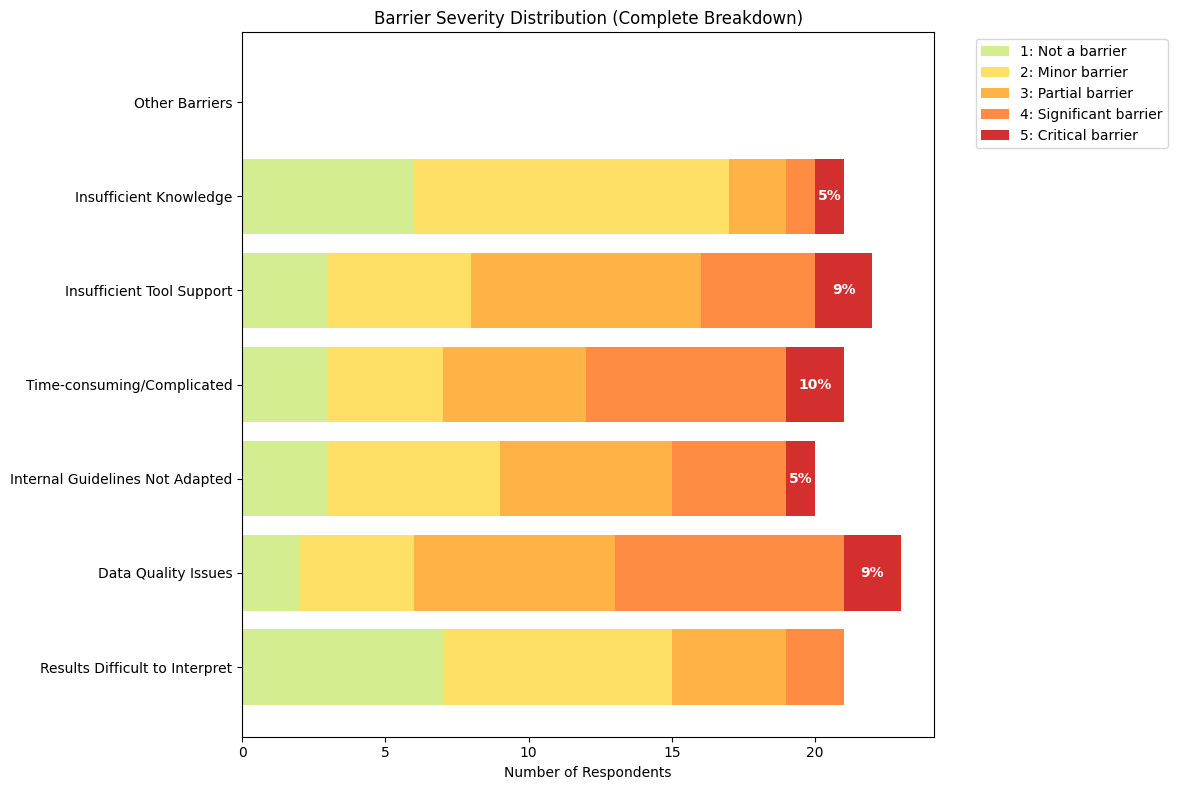

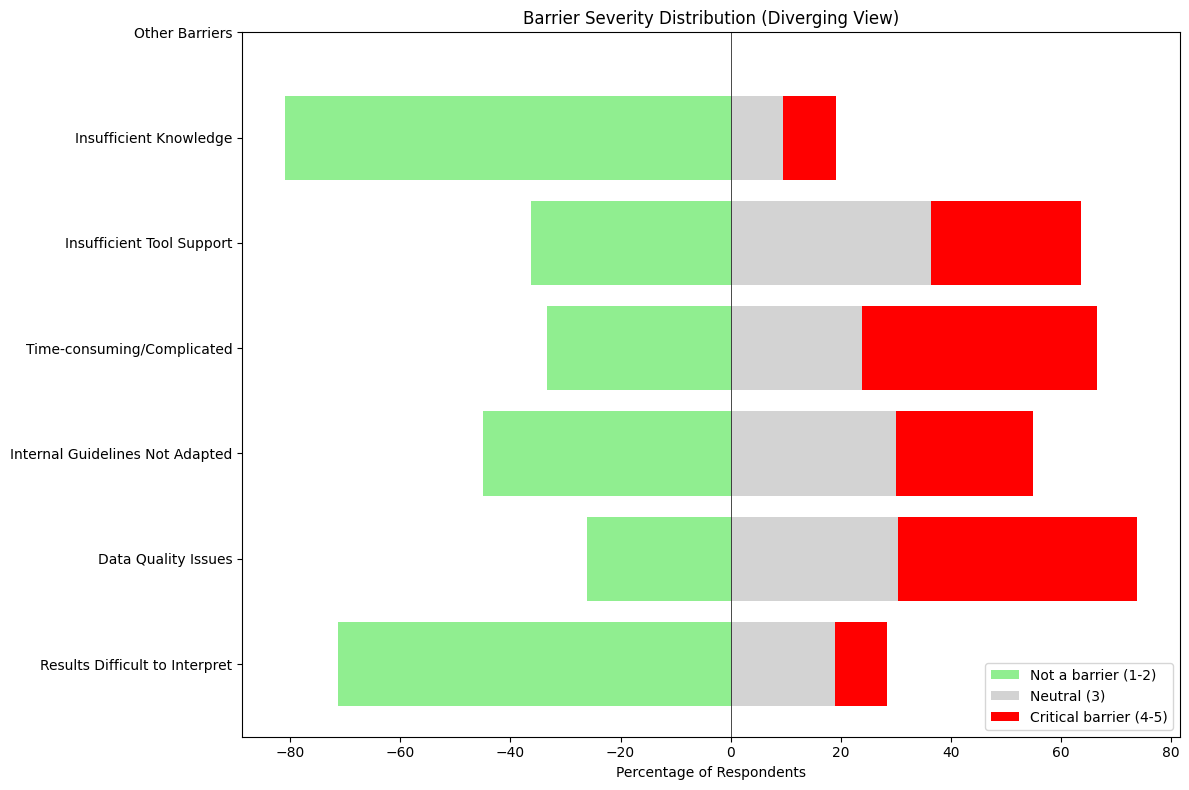

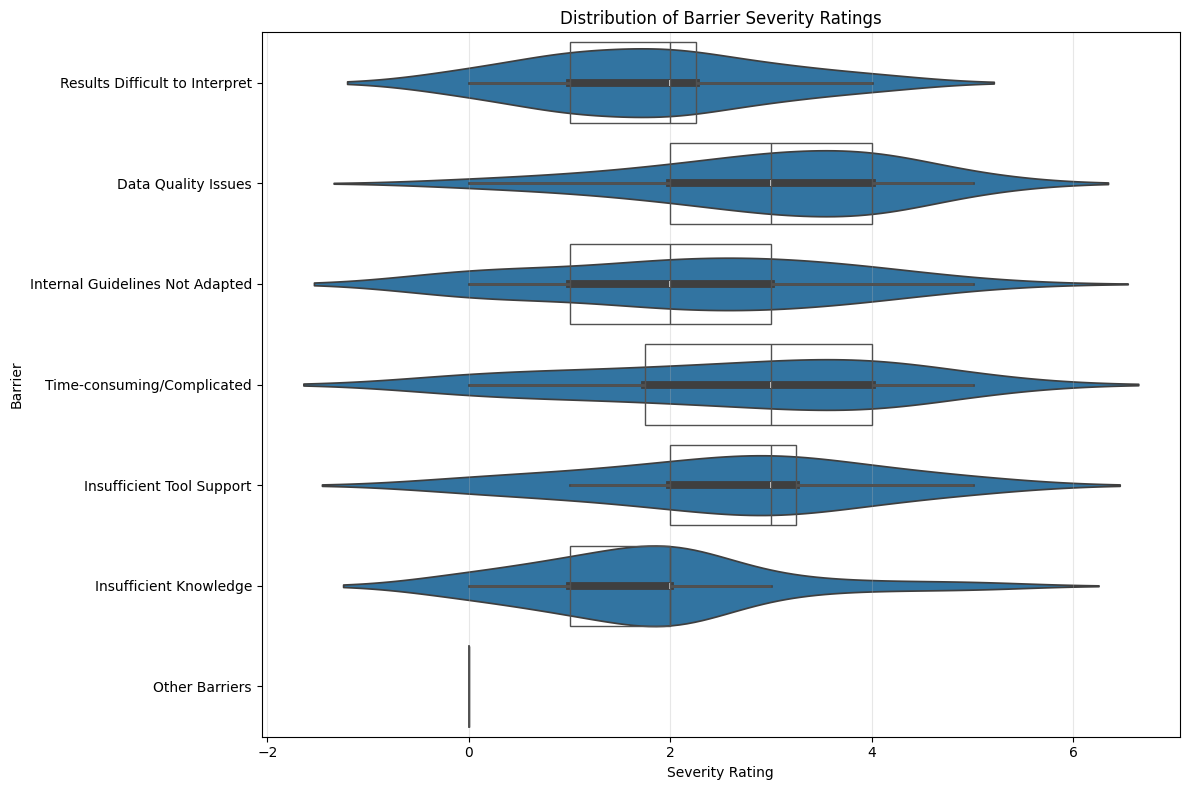

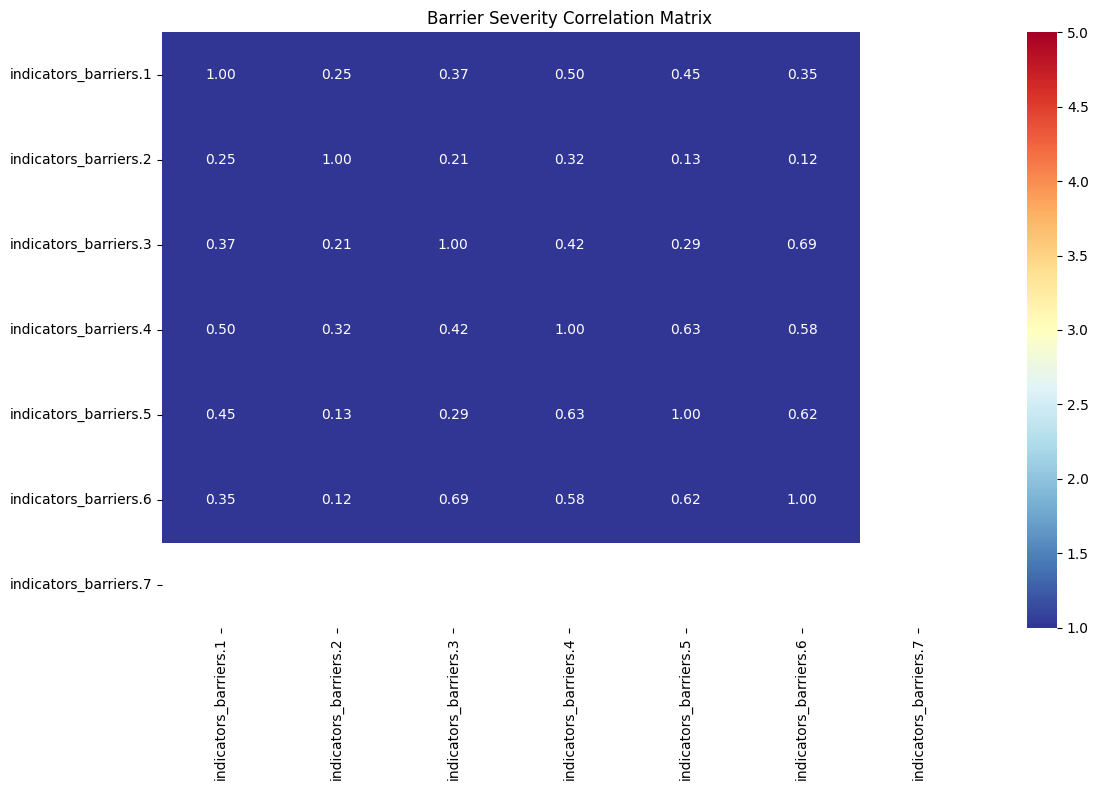

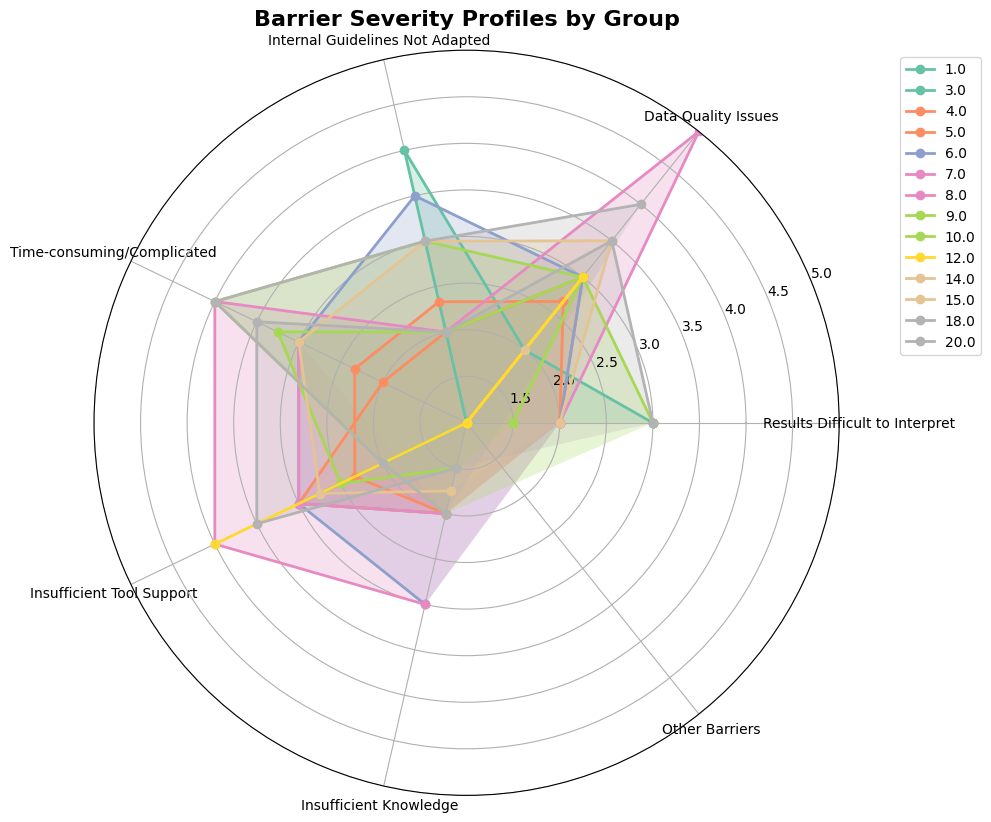

In [77]:
def analyze_barrier_severity_complete(df):
    """Complete barrier severity analysis with multiple visualizations"""
    
    # Define barrier columns and labels
    barrier_cols = [col for col in df.columns 
                #if ('barriers' in col.lower() or 'barrieres' in col)
                if ('indicators_barriers' in col.lower() or 'indicators_barrieres' in col) 
                #if ('software_barriers' in col.lower() or 'software_barrieres' in col) 
                and not col.lower().endswith('desc')]
    barrier_labels = [BARRIERS_MAPPINGS.get(col, col) for col in barrier_cols]
    
    print("BARRIER SEVERITY ANALYSIS")
    print("=" * 50)
    
    # Summary statistics
    for col, label in zip(barrier_cols, barrier_labels):
        severity_counts = df[col].value_counts().sort_index()
        critical = severity_counts.get(5, 0) + severity_counts.get(4, 0)
        total = severity_counts.sum()
        print(f"{label}: {critical}/{total} ({critical/total*100:.1f}%) critical")
    
    # Create all visualizations
    create_stacked_barrier_severity(df, barrier_cols, barrier_labels)
    create_diverging_barrier_chart(df, barrier_cols, barrier_labels)
    create_barrier_distribution_plot(df, barrier_cols, barrier_labels)
    create_barrier_severity_heatmap(df, barrier_cols)  # or 'seniority'
    create_barrier_radar_chart(df, barrier_cols, barrier_labels, group_col='experience_total')
    
    return barrier_cols, barrier_labels

# Run complete analysis
barrier_analysis = analyze_barrier_severity_complete(df)

In [ ]:
def create_barrier_severity_heatmap_with_roles(df, barrier_cols, role_mappings):
    """Create heatmap showing average barrier severity by role (multiple roles per respondent allowed)"""
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    
    # Get barrier labels (adapt these to your actual barrier column labels)
    barrier_labels = [BARRIERS_MAPPINGS.get(col, col.replace('_', ' ').title()) for col in barrier_cols]
    
    # Initialize DataFrame for heatmap data
    role_names = list(role_mappings.values())
    heatmap_data = pd.DataFrame(index=role_names, columns=barrier_labels, dtype=float)
    role_counts = {}
    
    # Calculate average barrier severity for each role
    for role_col, role_name in role_mappings.items():
        if role_col in df.columns:
            # Get respondents who have this role (binary = 1)
            role_mask = df[role_col] == 1
            n_respondents = role_mask.sum()
            role_counts[role_name] = n_respondents
            
            if n_respondents > 0:
                # Calculate mean barrier severity for this role
                role_barrier_means = df.loc[role_mask, barrier_cols].mean()
                heatmap_data.loc[role_name] = role_barrier_means.values
            else:
                # No respondents with this role
                heatmap_data.loc[role_name] = np.nan
        else:
            print(f"Warning: Column {role_col} not found in dataframe")
            heatmap_data.loc[role_name] = np.nan
            role_counts[role_name] = 0
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Create annotations showing both value and sample size
    annotations = []
    for role in role_names:
        row_annotations = []
        for i, barrier in enumerate(barrier_labels):
            value = heatmap_data.loc[role, barrier]
            count = role_counts[role]
            if pd.notna(value) and count > 0:
                row_annotations.append(f'{value:.2f}\n(n={count})')
            else:
                row_annotations.append('')
        annotations.append(row_annotations)
    
    # Plot heatmap
    mask = heatmap_data.isna()
    sns.heatmap(heatmap_data.astype(float), 
                annot=annotations, 
                fmt='', 
                cmap='RdYlBu_r', 
                center=3, 
                vmin=1, 
                vmax=5,
                mask=mask,
                cbar_kws={'label': 'Average Severity (1=Not barrier, 5=Critical barrier)'},
                ax=ax)
    
    ax.set_title('Average Barrier Severity by Role\n(Multiple roles per respondent allowed)', 
                fontsize=14, fontweight='bold')
    ax.set_ylabel('Role')
    ax.set_xlabel('Barrier Type')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nROLE DISTRIBUTION SUMMARY:")
    print("-" * 40)
    total_responses = len(df)
    for role_name, count in role_counts.items():
        if count > 0:
            percentage = (count / total_responses) * 100
            print(f"{role_name}: {count} respondents ({percentage:.1f}%)")
    
    return heatmap_data, role_counts


BARRIER SEVERITY ANALYSIS
Results Difficult to Interpret: 1/24 (4.2%) critical
Data Quality Issues: 9/24 (37.5%) critical
Internal Guidelines Not Adapted: 5/24 (20.8%) critical
Time-consuming/Complicated: 6/24 (25.0%) critical
Insufficient Tool Support: 5/24 (20.8%) critical
Insufficient Knowledge: 3/24 (12.5%) critical
Other Barriers: 1/13 (7.7%) critical
Results Difficult to Interpret: 2/24 (8.3%) critical
Data Quality Issues: 10/24 (41.7%) critical
Internal Guidelines Not Adapted: 5/24 (20.8%) critical
Time-consuming/Complicated: 9/24 (37.5%) critical
Insufficient Tool Support: 6/24 (25.0%) critical
Insufficient Knowledge: 2/24 (8.3%) critical
Other Barriers: 0/14 (0.0%) critical


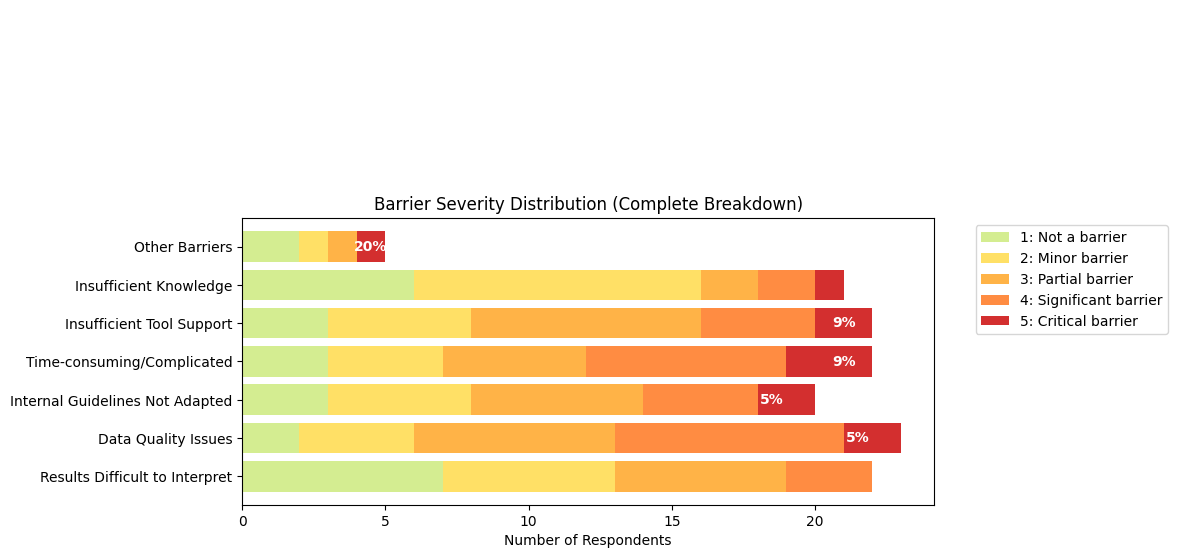

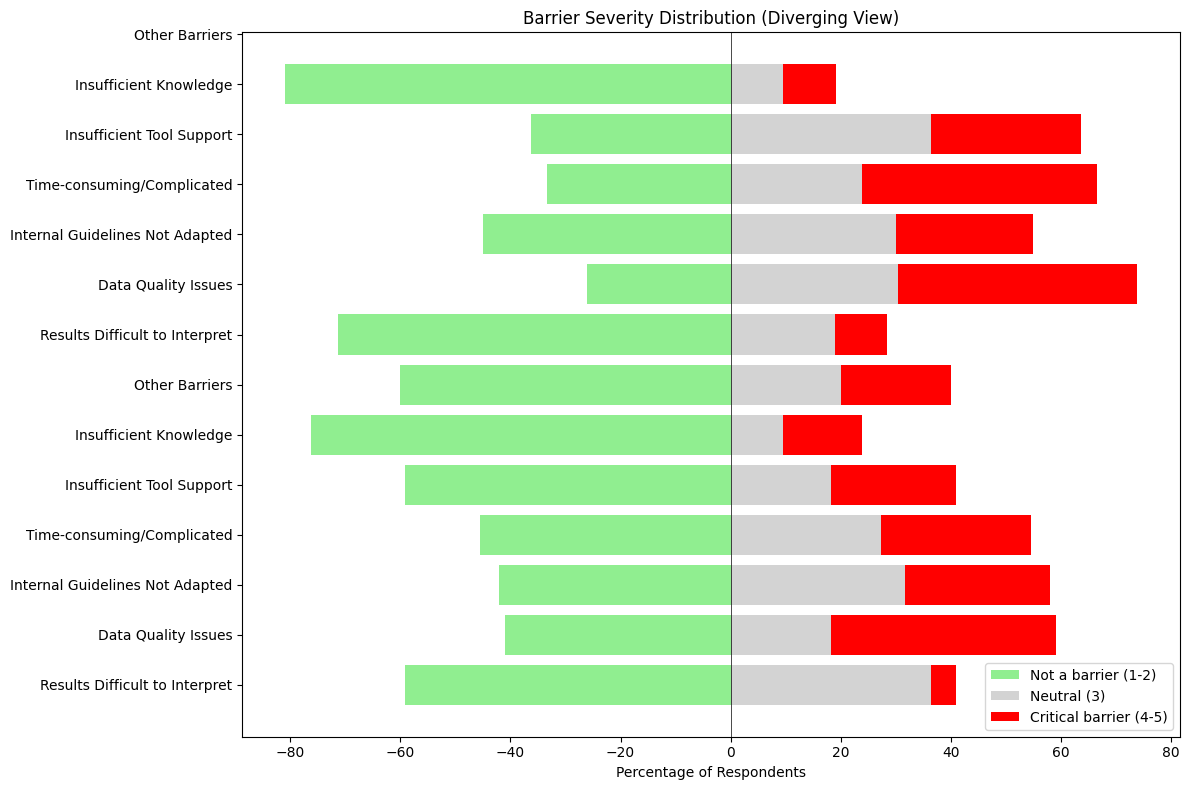

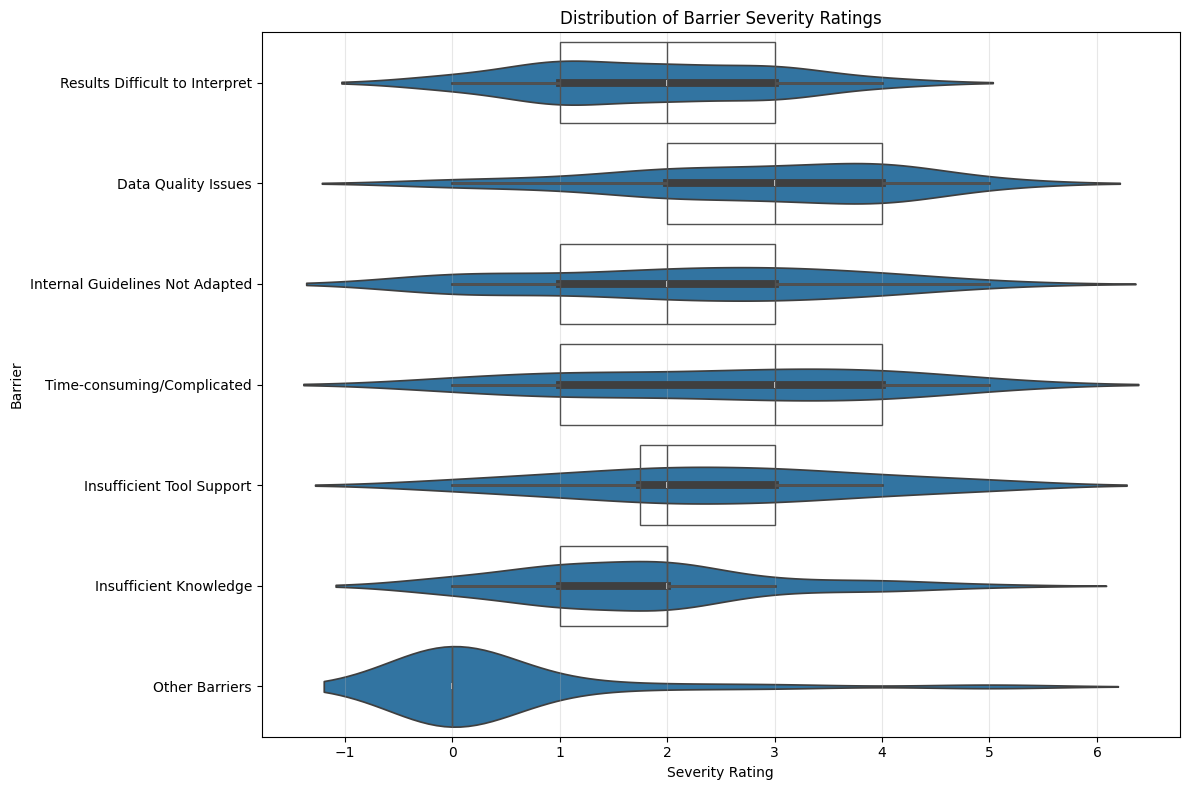

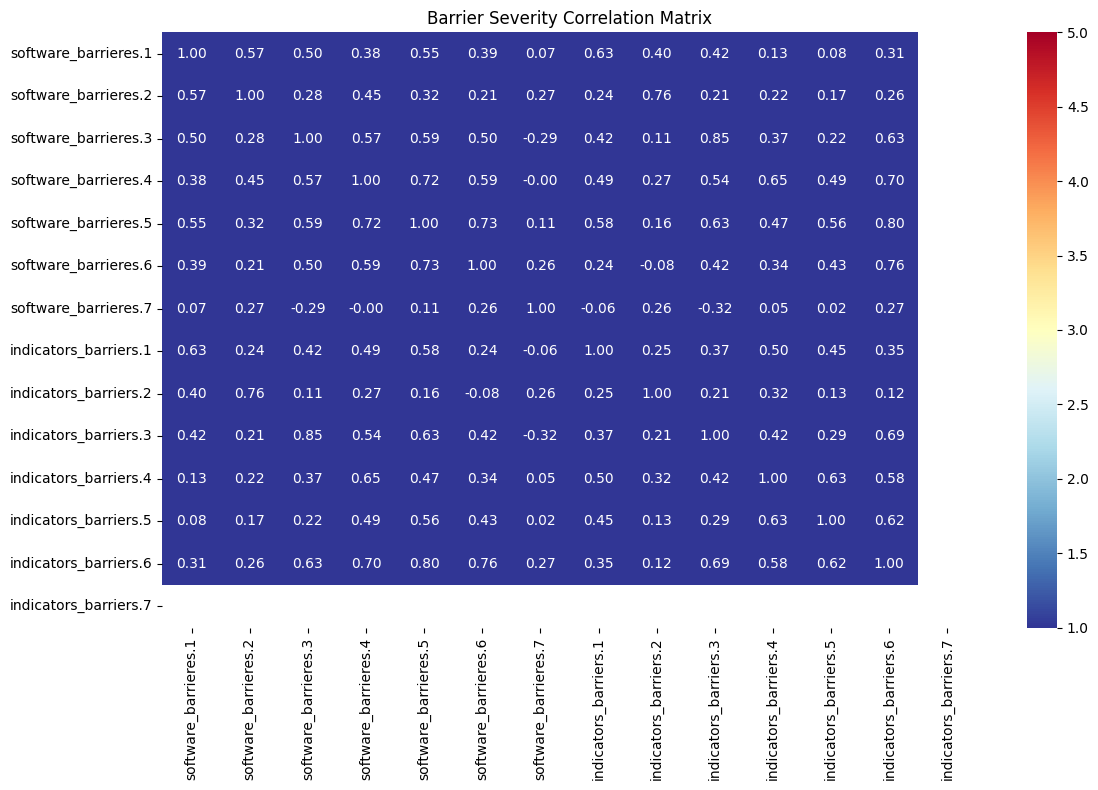

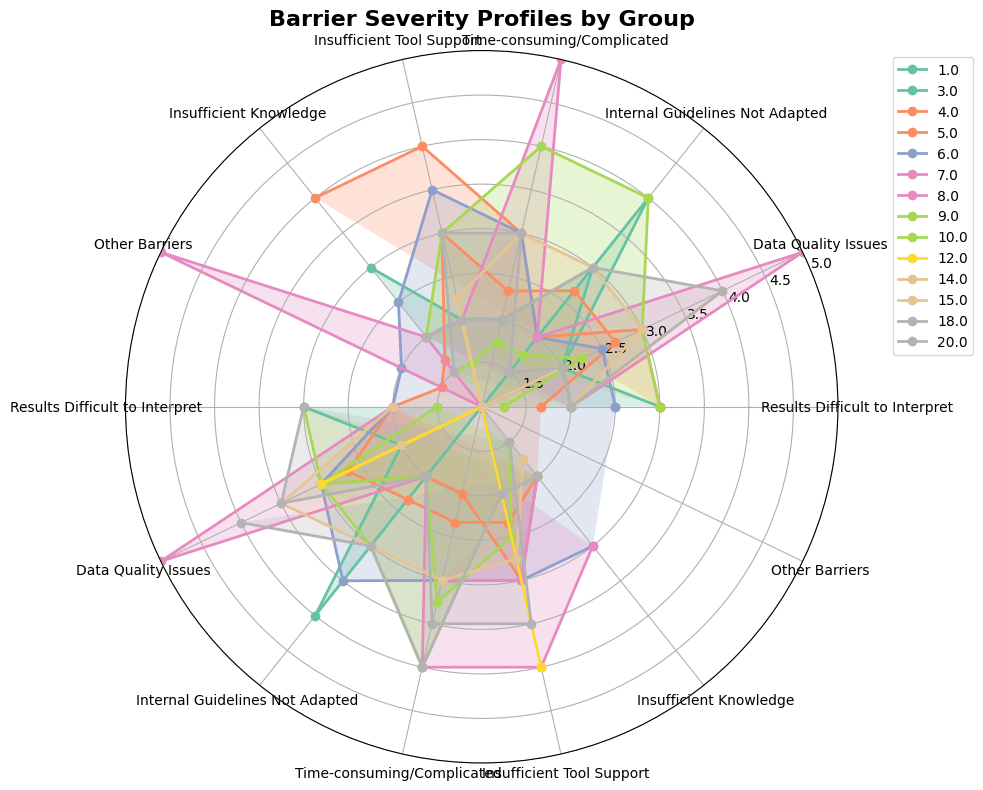

Found 14 barrier columns (excluding description columns):
  - software_barrieres.1
  - software_barrieres.2
  - software_barrieres.3
  - software_barrieres.4
  - software_barrieres.5
  ... and 9 more

Found 8 role types
ROLE OVERLAP ANALYSIS
Total respondents: 24
Respondents with no role specified: 0
Respondents with 1 role: 10
Respondents with 2+ roles: 14
Average roles per respondent: 2.17

MOST COMMON ROLE COMBINATIONS:
-----------------------------------
Power System Analyst, Network Planner, Connection Manager: 5 (20.8%)
Other Role: 3 (12.5%)
Connection Manager: 2 (8.3%)
Power System Analyst, Network Planner: 2 (8.3%)
Network Planner: 2 (8.3%)
Operations Operator: 1 (4.2%)
Operations Planner, Operations Coordinator, Operations Operator: 1 (4.2%)
Power System Analyst: 1 (4.2%)
Power System Analyst, Network Planner, Operations Operator: 1 (4.2%)
Power System Analyst, Operations Planner, Operations Coordinator, Incident Analyst: 1 (4.2%)


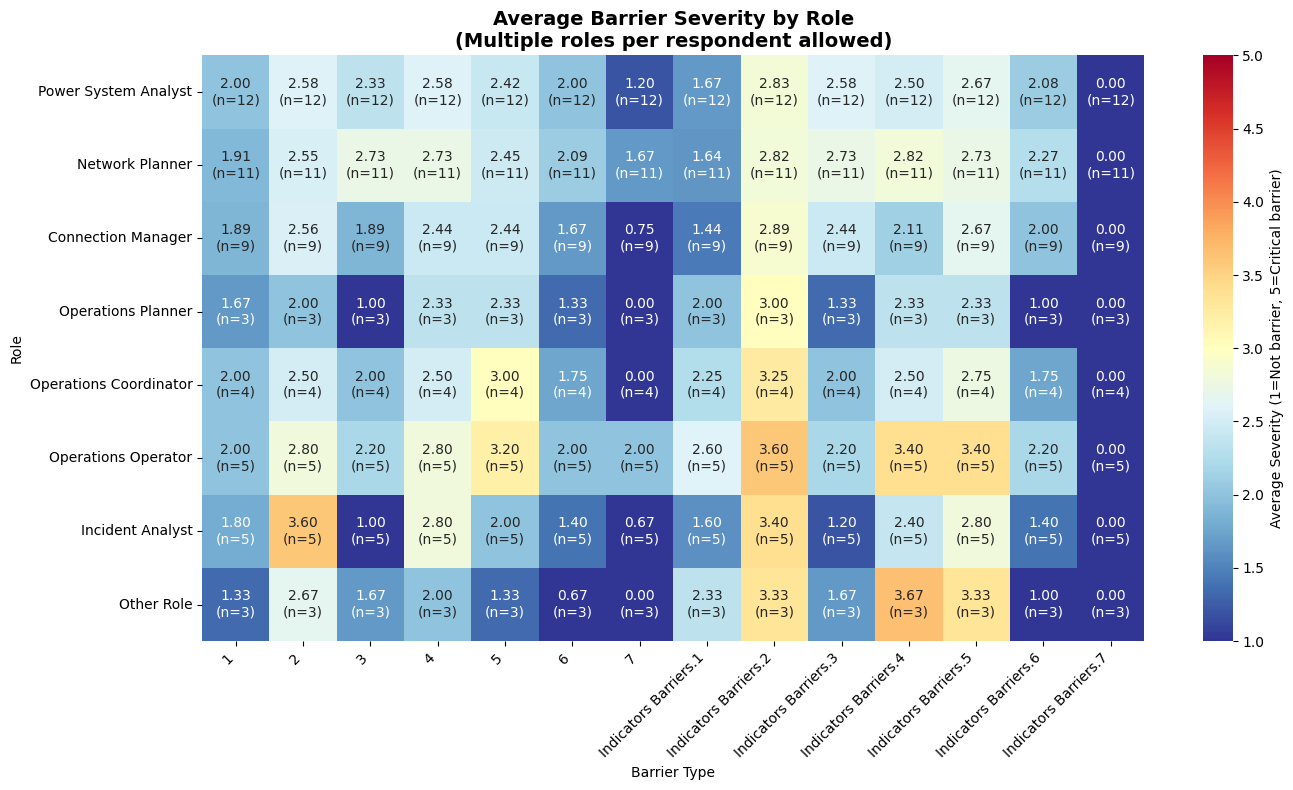


ROLE DISTRIBUTION SUMMARY:
----------------------------------------
Power System Analyst: 12 respondents (50.0%)
Network Planner: 11 respondents (45.8%)
Connection Manager: 9 respondents (37.5%)
Operations Planner: 3 respondents (12.5%)
Operations Coordinator: 4 respondents (16.7%)
Operations Operator: 5 respondents (20.8%)
Incident Analyst: 5 respondents (20.8%)
Other Role: 3 respondents (12.5%)

BARRIER SEVERITY BY ROLE SUMMARY:
Power System Analyst (n=12):
  Average severity: 2.10
  Biggest barrier: Indicators Barriers.2 (2.83)
Network Planner (n=11):
  Average severity: 2.22
  Biggest barrier: Indicators Barriers.2 (2.82)
Connection Manager (n=9):
  Average severity: 1.94
  Biggest barrier: Indicators Barriers.2 (2.89)
Operations Planner (n=3):
  Average severity: 1.62
  Biggest barrier: Indicators Barriers.2 (3.00)
Operations Coordinator (n=4):
  Average severity: 2.02
  Biggest barrier: Indicators Barriers.2 (3.25)
Operations Operator (n=5):
  Average severity: 2.46
  Biggest ba

In [69]:
def create_barrier_severity_heatmap_with_roles_fixed(df, barrier_cols, role_mappings):
    """Create heatmap showing average barrier severity by role - handles Series values"""
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    
    # Filter out description columns if not already done
    barrier_cols = [col for col in barrier_cols if not col.lower().endswith('desc')]
    
    # Get barrier labels
    barrier_labels = [col.replace('software_barrieres.', '').replace('_', ' ').title() 
                     for col in barrier_cols]
    
    # Initialize DataFrame for heatmap data
    role_names = list(role_mappings.values())
    heatmap_data = pd.DataFrame(index=role_names, columns=barrier_labels, dtype=float)
    role_counts = {}
    
    # Calculate average barrier severity for each role
    for role_col, role_name in role_mappings.items():
        if role_col in df.columns:
            role_mask = df[role_col] == 1
            n_respondents = role_mask.sum()
            role_counts[role_name] = n_respondents
            
            if n_respondents > 0:
                barrier_data = df.loc[role_mask, barrier_cols]
                numeric_barriers = barrier_data.apply(pd.to_numeric, errors='coerce')
                role_barrier_means = numeric_barriers.mean()
                heatmap_data.loc[role_name] = role_barrier_means.values
            else:
                heatmap_data.loc[role_name] = np.nan
        else:
            print(f"Warning: Column {role_col} not found in dataframe")
            heatmap_data.loc[role_name] = np.nan
            role_counts[role_name] = 0
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Create annotations with proper scalar handling
    annotations = []
    for role in role_names:
        row_annotations = []
        for barrier in barrier_labels:
            value = heatmap_data.loc[role, barrier]
            
            # Convert Series to scalar if needed
            if isinstance(value, pd.Series):
                value = value.iloc[0] if len(value) > 0 else np.nan
            
            count = role_counts.get(role, 0)
            
            # Use in boolean context
            if pd.notna(value) and count > 0:
                row_annotations.append(f'{value:.2f}\n(n={count})')
            else:
                row_annotations.append('')
        annotations.append(row_annotations)
    
    # Plot heatmap
    mask = heatmap_data.isna()
    sns.heatmap(heatmap_data.astype(float), 
                annot=annotations, 
                fmt='', 
                cmap='RdYlBu_r', 
                center=3, 
                vmin=1, 
                vmax=5,
                mask=mask,
                cbar_kws={'label': 'Average Severity (1=Not barrier, 5=Critical barrier)'},
                ax=ax)
    
    ax.set_title('Average Barrier Severity by Role\n(Multiple roles per respondent allowed)', 
                fontsize=14, fontweight='bold')
    ax.set_ylabel('Role')
    ax.set_xlabel('Barrier Type')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nROLE DISTRIBUTION SUMMARY:")
    print("-" * 40)
    total_responses = len(df)
    for role_name, count in role_counts.items():
        if count > 0:
            percentage = (count / total_responses) * 100
            print(f"{role_name}: {count} respondents ({percentage:.1f}%)")
    
    return heatmap_data, role_counts

def create_barrier_severity_by_role_stacked(df, barrier_cols, role_mappings):
    """Create stacked bar chart showing barrier severity distribution by role"""
    
    # Get barrier labels
    barrier_labels = [BARRIERS_MAPPINGS.get(col, col.replace('_', ' ').title()) for col in barrier_cols]
    
    fig, axes = plt.subplots(len(role_mappings), 1, figsize=(12, 3*len(role_mappings)))
    if len(role_mappings) == 1:
        axes = [axes]
    
    colors = ['#d4ed91', '#ffe066', '#ffb347', '#ff8c42', '#d32f2f']
    labels = ['1: Not barrier', '2: Minor', '3: Partial', '4: Significant', '5: Critical']
    
    for idx, (role_col, role_name) in enumerate(role_mappings.items()):
        if role_col in df.columns:
            # Get respondents with this role
            role_mask = df[role_col] == 1
            n_respondents = role_mask.sum()
            
            if n_respondents == 0:
                axes[idx].text(0.5, 0.5, f'No respondents with {role_name}', 
                              ha='center', va='center', transform=axes[idx].transAxes)
                axes[idx].set_title(f'{role_name} (n=0)')
                continue
            
            # Calculate severity distribution for each barrier
            severity_data = np.zeros((len(barrier_cols), 5))
            for i, col in enumerate(barrier_cols):
                role_barrier_data = df.loc[role_mask, col]
                counts = role_barrier_data.value_counts().reindex(range(1, 6), fill_value=0)
                severity_data[i] = counts.values
            
            # Create stacked bar
            left = np.zeros(len(barrier_cols))
            for severity in range(5):
                axes[idx].barh(barrier_labels, severity_data[:, severity], 
                              left=left, color=colors[severity], 
                              label=labels[severity] if idx == 0 else "")
                left += severity_data[:, severity]
            
            axes[idx].set_title(f'{role_name} (n={n_respondents})')
            axes[idx].set_xlabel('Number of Respondents')
            
            if idx == 0:
                axes[idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.suptitle('Barrier Severity Distribution by Role', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def analyze_barriers_by_roles_complete(df):
    """Complete barrier analysis by roles workflow - with all fixes"""
    
    # Define barrier columns, EXCLUDING description columns
    barrier_cols = [col for col in df.columns 
                   if ('barriers' in col.lower() or 'software_barrieres' in col) 
                   and not col.lower().endswith('desc')]
    
    if not barrier_cols:
        print("No barrier columns found. Please check column names.")
        return
    
    print(f"Found {len(barrier_cols)} barrier columns (excluding description columns):")
    for col in barrier_cols[:5]:  # Show first 5
        print(f"  - {col}")
    if len(barrier_cols) > 5:
        print(f"  ... and {len(barrier_cols)-5} more")
    
    print(f"\nFound {len(ROLE_MAPPINGS)} role types")
    
    # 1. Analyze role overlap
    roles_per_respondent, role_combinations = analyze_role_overlap(df, ROLE_MAPPINGS)
    
    # 2. Create heatmap (FIXED VERSION)
    heatmap_data, role_counts = create_barrier_severity_heatmap_with_roles_fixed(
        df, barrier_cols, ROLE_MAPPINGS)
    
    # 3. Summary statistics
    print("\nBARRIER SEVERITY BY ROLE SUMMARY:")
    print("=" * 50)
    
    for role_name in ROLE_MAPPINGS.values():
        if role_name in heatmap_data.index and role_counts[role_name] > 0:
            role_means = heatmap_data.loc[role_name].dropna()
            if not role_means.empty:
                avg_severity = role_means.mean()
                max_barrier_idx = role_means.idxmax()
                print(f"{role_name} (n={role_counts[role_name]}):")
                print(f"  Average severity: {avg_severity:.2f}")
                print(f"  Biggest barrier: {max_barrier_idx} ({role_means[max_barrier_idx]:.2f})")
    
    return heatmap_data, role_counts, roles_per_respondent

# Run the complete analysis
barrier_analysis_results = analyze_barriers_by_roles_complete(df)



## Validity checks


In [ ]:
# Identify similar questions / questions that ask about more or less the same. 


# Role power system analyst and grid planner should do the following analyses
# Role Grid operation planner/opertaor should do the following analysis:
#Power system analyst and network planner should also make descisions about New Connections and do load flow analysis
#Grid operators should also make descisions about operation and coordination and do outage analysis /operation analysis
#respondents that use one or know of the following: LOLE, LOLP, EENS, LOLF, LOLD or COPT should also know about the others
#Respondents that are using Fever indicators should report higher on barriers
#Respondents that are using very few or none softwares should answer that it is not important 
#respondents that answer that they are very satisfied or satisfied (4 and 5) with software support should not score high (<4) on software beeing a barrier and vice versa
#If software is deemed very important, not satisfactory this should also be found in the Barriers. 
#Users of the same software should have some similarity in the satisfaction With software
#Same roles in same Company should also use the same software
#respondents that answer that they do outage analysis should also answer that the do state enumeration. 
#Some correlation between modeling of uncertainty in different analysis (Load/Production analysis and simulations)





In [48]:

def cronbach_alpha(items_df):
    """Calculate Cronbach's alpha for internal consistency"""
    items_clean = items_df.dropna()
    k = items_clean.shape[1]
    if k < 2:
        return 0
    
    item_variances = items_clean.var(axis=0, ddof=1).sum()
    total_variance = items_clean.sum(axis=1).var(ddof=1)
    
    if total_variance == 0:
        return 0
    
    alpha = (k / (k - 1)) * (1 - item_variances / total_variance)
    return alpha

def distance_matrix(X, Y):
    """Calculate distance matrix between two sets of points"""
    from scipy.spatial.distance import pdist, squareform
    return squareform(pdist(X, metric='hamming'))


def comprehensive_questionnaire_validity_analysis(df):
    """
    Comprehensive validity analysis using logical relationships in your questionnaire
    """
    
    validation_results = {}
    
    print("🔍 COMPREHENSIVE QUESTIONNAIRE VALIDITY ANALYSIS")
    print("="*70)
    
    # 1. Role-Decision Consistency Validation
    print("\n1. ROLE-DECISION CONSISTENCY VALIDATION")
    role_decision_validity = validate_role_decision_consistency(df)
    validation_results['role_decision'] = role_decision_validity
    
    # 2. Technical Knowledge Consistency 
    print("\n2. TECHNICAL KNOWLEDGE CONSISTENCY VALIDATION")
    knowledge_consistency = validate_technical_knowledge_consistency(df)
    validation_results['knowledge_consistency'] = knowledge_consistency
    
    # 3. Software-Satisfaction-Barriers Convergent Validity
    print("\n3. SOFTWARE-SATISFACTION-BARRIERS CONVERGENT VALIDITY")
    software_validity = validate_software_satisfaction_barriers(df)
    validation_results['software_validity'] = software_validity
    
    # 4. Experience-Usage Correlation Validity
    print("\n4. EXPERIENCE-USAGE CORRELATION VALIDITY")
    experience_validity = validate_experience_usage_patterns(df)
    validation_results['experience_validity'] = experience_validity
    
    # 5. Organizational Consistency
    #print("\n5. ORGANIZATIONAL CONSISTENCY VALIDATION")
    #org_validity = validate_organizational_consistency(df)
    #validation_results['organizational_validity'] = org_validity
    
    # 6. Technical Method Correlation
    #print("\n6. TECHNICAL METHOD CORRELATION VALIDATION")
    #method_validity = validate_method_correlations(df)
    #validation_results['method_validity'] = method_validity
    
    # 7. Uncertainty Modeling Consistency
    #print("\n7. UNCERTAINTY MODELING CONSISTENCY")
    #uncertainty_validity = validate_uncertainty_consistency(df)
    #validation_results['uncertainty_validity'] = uncertainty_validity
    
    return validation_results

def validate_role_decision_consistency(df):
    """
    Validate that roles align with expected decision types
    """
    results = {}
    
    # Define expected role-decision mappings from your description
    planner_roles = ['Role_type.1', 'Role_type.2','Role_type.3']  # 1= Power system analyst, 2=Network planner, 3=Grid planner
    planner_decisions = ['decision_type.1','decision_type.3'] # 1=New connections, 3=Load flow analysis
    
    operator_roles = ['Role_type.4', 'Role_type.5', 'Role_type.6']  # 4=Grid operation planner, 5=Grid operator, 6=Operatoins operator
    operator_decisions = ['decision_type.2']    # 2=Operation and coordination
    
    # Test planners do planning decisions
    if all(col in df.columns for col in planner_roles + planner_decisions):
        planner_mask = df[planner_roles].any(axis=1)
        planner_decision_rate = df[planner_mask][planner_decisions].mean().mean()
        non_planner_decision_rate = df[~planner_mask][planner_decisions].mean().mean()
        
        from scipy.stats import ttest_ind
        t_stat, p_val = ttest_ind(
            df[planner_mask][planner_decisions].mean(axis=1),
            df[~planner_mask][planner_decisions].mean(axis=1)
        )
        
        results['planner_validity'] = {
            'planner_rate': planner_decision_rate,
            'non_planner_rate': non_planner_decision_rate,
            't_statistic': t_stat,
            'p_value': p_val,
            'significant': p_val < 0.05
        }
        
        print(f"   Planners vs Non-planners in planning decisions:")
        print(f"   Planner rate: {planner_decision_rate:.3f}, Non-planner: {non_planner_decision_rate:.3f}")
        print(f"   t-test: t={t_stat:.3f}, p={p_val:.3f} {'✓' if p_val < 0.05 else '✗'}")
    
    # Similar for operators
    if all(col in df.columns for col in operator_roles + operator_decisions):
        operator_mask = df[operator_roles].any(axis=1)
        operator_decision_rate = df[operator_mask][operator_decisions].mean().mean()
        non_operator_decision_rate = df[~operator_mask][operator_decisions].mean().mean()
        
        t_stat, p_val = ttest_ind(
            df[operator_mask][operator_decisions].mean(axis=1),
            df[~operator_mask][operator_decisions].mean(axis=1)
        )
        
        results['operator_validity'] = {
            'operator_rate': operator_decision_rate,
            'non_operator_rate': non_operator_decision_rate,
            't_statistic': t_stat,
            'p_value': p_val,
            'significant': p_val < 0.05
        }
        
        print(f"   Operators vs Non-operators in operational decisions:")
        print(f"   Operator rate: {operator_decision_rate:.3f}, Non-operator: {non_operator_decision_rate:.3f}")
        print(f"   t-test: t={t_stat:.3f}, p={p_val:.3f} {'✓' if p_val < 0.05 else '✗'}")
    
    return results

def validate_technical_knowledge_consistency(df):
    """
    Validate that knowledge of related technical concepts correlates
    """
    results = {}
    
    # Reliability indices should correlate
    reliability_indices = ['indicators_type.4','indicators_type.8', 'indicators_type.9','indicators_type.10'] # 4=EENS, 8=LOLE, 9=LOLF/LOLD, 10=LOLP
    available_indices = [col for col in reliability_indices if col in df.columns] # Check columns exist
    
    if len(available_indices) >= 3:  # Need at least 3 for meaningful correlation
        reliability_df = df[available_indices].dropna()  # Remove rows with ANY missing values
        
        print(f"   Found {len(available_indices)} reliability indices, {len(reliability_df)} complete responses")
        
        if len(reliability_df) >= 5:  # Need sufficient data
            # Calculate pairwise correlations
            corr_matrix = reliability_df.corr() # Pearson by default

        
        # Get average correlation (excluding diagonal)
        mask = ~np.eye(corr_matrix.shape[0], dtype=bool) # Mask to exclude diagonal
        avg_correlation = corr_matrix.values[mask].mean() # Average of off-diagonal
        min_correlation = corr_matrix.values[mask].min() # Min of off-diagonal
        max_correlation = corr_matrix.values[mask].max() # Max of off-diagonal
        
        results['reliability_indices'] = {
            'average_correlation': avg_correlation, # Average Pearson r
            'min_correlation': min_correlation, # Min Pearson r
            'max_correlation': max_correlation, # Max Pearson r
            'consistent': avg_correlation > 0.4  # Reasonable threshold
        }
        
        print(f"   Reliability indices correlation:")
        print(f"   Average r={avg_correlation:.3f}, Range: {min_correlation:.3f} to {max_correlation:.3f}")
        print(f"   Consistency: {'✓' if avg_correlation > 0.4 else '✗'}")
        
        # Calculate Cronbach's alpha for reliability indices
        alpha = cronbach_alpha(reliability_df) 
        results['reliability_indices']['cronbach_alpha'] = alpha # Cronbach's alpha
        print(f"   Cronbach's α = {alpha:.3f} {'✓' if alpha > 0.7 else '✗'}") # Threshold for acceptable reliability
    else:
        print(f"   ⚠️ Insufficient complete data for reliability analysis ({len(reliability_df)} observations)")
        results['reliability_indices'] = {
            'average_correlation': 0,
            'min_correlation': 0, 
            'max_correlation': 0,
            'consistent': False,
            'cronbach_alpha': 0,
            'error': 'Insufficient data'
        }

    # Outage analysis should correlate with state enumeration
    if 'analyze_type.1' in df.columns and 'simulation_type.2' in df.columns: # 1=Outage analysis, 2=State enumeration
        valid_data = df[['analyze_type.1', 'simulation_type.2']].dropna()
        
        if len(valid_data) >= 5:
            correlation, p_val = pearsonr(valid_data['analyze_type.1'], valid_data['simulation_type.2'])
            results['outage_state_enum'] = {
                'correlation': correlation,
                'p_value': p_val,
                'n_observations': len(valid_data),
                'significant': p_val < 0.05
            }
            print(f"   Outage analysis vs State enumeration (n={len(valid_data)}): r={correlation:.3f}, p={p_val:.3f}")
        else:
            print(f"   ⚠️ Outage-state enumeration: Insufficient data ({len(valid_data)} observations)")

    
    return results

def validate_software_satisfaction_barriers(df):
    """
    Validate convergent validity between software satisfaction and barriers
    """
    results = {}
    
    # Software satisfaction should negatively correlate with software barriers
# Software satisfaction should negatively correlate with software barriers
    software_dep_barriers = ['software_barrieres.4','software_barrieres.5'] # 4=Takes too long, 5=Software does not provide the support
    satisfaction_cols = [col for col in df.columns if 'software_satisfaction' in col.lower()]
    barrier_cols = [col for col in df.columns if col in software_dep_barriers]  # Only check specific barriers

    
    print(f"   Found {len(satisfaction_cols)} satisfaction columns and {len(barrier_cols)} barrier columns")

    if satisfaction_cols and barrier_cols:
        for sat_col in satisfaction_cols: 
            for bar_col in barrier_cols:
                # Create subset with both columns having valid data
                valid_data = df[[sat_col, bar_col]].dropna()
                
                if len(valid_data) >= 3:  # Need at least 3 observations
                    # Convert to numeric, coerce errors to NaN
                    sat_numeric = pd.to_numeric(valid_data[sat_col], errors='coerce')
                    bar_numeric = pd.to_numeric(valid_data[bar_col], errors='coerce')
                    
                    # Remove any rows that couldn't be converted
                    final_valid = ~(sat_numeric.isna() | bar_numeric.isna())
                    
                    if final_valid.sum() >= 3:
                        correlation, p_val = pearsonr(sat_numeric[final_valid], bar_numeric[final_valid])
                        
                        results[f'{sat_col}_vs_{bar_col}'] = {
                            'correlation': correlation,
                            'p_value': p_val,
                            'n_observations': final_valid.sum(),
                            'expected_negative': correlation < -0.2,
                            'significant': p_val < 0.05
                        }
                        
                        print(f"   {sat_col} vs {bar_col} (n={final_valid.sum()}): r={correlation:.3f}, p={p_val:.3f}")
                        print(f"   Expected negative: {'✓' if correlation < -0.2 else '✗'}")
                    else:
                        print(f"   ⚠️ {sat_col} vs {bar_col}: No valid numeric data ({final_valid.sum()} observations)")
                else:
                    print(f"   ⚠️ {sat_col} vs {bar_col}: Insufficient valid data ({len(valid_data)} observations)")

        
    # Software importance vs barriers relationship
    importance_cols = [col for col in df.columns if 'software_importance' in col.lower()]
    
    if importance_cols and barrier_cols:
        print(f"\n   IMPORTANCE-BARRIERS ANALYSIS:")
        for imp_col in importance_cols:
            for bar_col in barrier_cols:
                # Create subset with both columns having valid data
                valid_data = df[[imp_col, bar_col]].dropna()
                
                if len(valid_data) >= 5:
                    # Convert to numeric
                    imp_numeric = pd.to_numeric(valid_data[imp_col], errors='coerce')
                    bar_numeric = pd.to_numeric(valid_data[bar_col], errors='coerce')
                    
                    # Remove rows with conversion errors
                    final_valid = ~(imp_numeric.isna() | bar_numeric.isna())
                    
                    if final_valid.sum() >= 5:
                        # High importance + high barriers should indicate problems
                        high_importance = imp_numeric[final_valid] >= 4  # based on 1-5 scale
                        
                        if high_importance.sum() >= 2:  # Need at least 2 in each group
                            barrier_for_important = bar_numeric[final_valid][high_importance].mean()
                            barrier_for_unimportant = bar_numeric[final_valid][~high_importance].mean()
                            
                            print(f"   {imp_col} vs {bar_col} (n={final_valid.sum()}):")
                            print(f"   High importance barriers: {barrier_for_important:.3f} (n={high_importance.sum()})")
                            print(f"   Low importance barriers: {barrier_for_unimportant:.3f} (n={(~high_importance).sum()})")
                        else:
                            print(f"   ⚠️ {imp_col} vs {bar_col}: Insufficient data in importance groups")
                    else:
                        print(f"   ⚠️ {imp_col} vs {bar_col}: No valid numeric data ({final_valid.sum()} observations)")
                else:
                    print(f"   ⚠️ {imp_col} vs {bar_col}: Insufficient valid data ({len(valid_data)} observations)")

    return results

def validate_experience_usage_patterns(df):
    """
    Validate that software usage aligns with experience and needs
    """
    results = {}
    
    # Users of few/no software should rate software as not important
    software_usage_cols = [col for col in df.columns if 'software_type' in col.lower()]
    software_importance_cols = [col for col in df.columns if 'software_importance' in col.lower()]
    
    print(f"   Found {len(software_usage_cols)} software usage columns and {len(software_importance_cols)} importance columns")
    
    if software_usage_cols and software_importance_cols:
        # Convert software usage columns to numeric and handle missing data
        software_usage_numeric = df[software_usage_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
        
        # Calculate total software usage (sum of numeric values)
        software_usage_total = software_usage_numeric.sum(axis=1)
        
        # Define usage groups
        low_usage = software_usage_total <= 1  # Using 1 or fewer software
        high_usage = software_usage_total >= 2  # Using 2+ software
        
        print(f"   Low usage group: {low_usage.sum()} respondents")
        print(f"   High usage group: {high_usage.sum()} respondents")
        
        for imp_col in software_importance_cols:
            # Convert importance column to numeric
            importance_numeric = pd.to_numeric(df[imp_col], errors='coerce')
            
            # Calculate means for each group (excluding NaN)
            low_usage_importance = importance_numeric[low_usage].mean()
            high_usage_importance = importance_numeric[high_usage].mean()
            
            # Statistical test (only if both groups have sufficient data)
            low_usage_valid = importance_numeric[low_usage].dropna()
            high_usage_valid = importance_numeric[high_usage].dropna()
            
            if len(low_usage_valid) >= 3 and len(high_usage_valid) >= 3:
                from scipy.stats import ttest_ind
                t_stat, p_val = ttest_ind(low_usage_valid, high_usage_valid)
                
                results[f'usage_importance_{imp_col}'] = {
                    'low_usage_importance': low_usage_importance,
                    'high_usage_importance': high_usage_importance,
                    't_statistic': t_stat,
                    'p_value': p_val,
                    'n_low_usage': len(low_usage_valid),
                    'n_high_usage': len(high_usage_valid),
                    'logical_difference': high_usage_importance > low_usage_importance,
                    'significant': p_val < 0.05
                }
                
                print(f"   Software importance by usage level ({imp_col}):")
                print(f"   Low users: {low_usage_importance:.3f} (n={len(low_usage_valid)})")
                print(f"   High users: {high_usage_importance:.3f} (n={len(high_usage_valid)})")
                print(f"   t-test: t={t_stat:.3f}, p={p_val:.3f}")
                print(f"   Expected difference: {'✓' if high_usage_importance > low_usage_importance else '✗'}")
            else:
                print(f"   ⚠️ {imp_col}: Insufficient data for statistical test")
                print(f"   Low users: {len(low_usage_valid)} valid responses")
                print(f"   High users: {len(high_usage_valid)} valid responses")
                
                results[f'usage_importance_{imp_col}'] = {
                    'low_usage_importance': low_usage_importance,
                    'high_usage_importance': high_usage_importance,
                    't_statistic': None,
                    'p_value': None,
                    'n_low_usage': len(low_usage_valid),
                    'n_high_usage': len(high_usage_valid),
                    'logical_difference': high_usage_importance > low_usage_importance if not (pd.isna(low_usage_importance) or pd.isna(high_usage_importance)) else False,
                    'significant': False,
                    'error': 'Insufficient data'
                }
    else:
        missing = []
        if not software_usage_cols:
            missing.append("software_type columns")
        if not software_importance_cols:
            missing.append("software_importance columns")
        
        print(f"   ⚠️ Missing columns: {', '.join(missing)}")
        results['error'] = f"Missing columns: {missing}"
    
    return results



# Usage:
# validation_results = comprehensive_questionnaire_validity_analysis(df)

# Create summary report
def create_validity_summary_report(validation_results):
    """
    Create summary report of all validity checks
    """
    print("\n" + "="*70)
    print("📋 QUESTIONNAIRE VALIDITY SUMMARY REPORT")
    print("="*70)
    
    total_tests = 0
    passed_tests = 0
    
    for category, results in validation_results.items():
        print(f"\n{category.upper().replace('_', ' ')}:")
        
        if isinstance(results, dict):
            for test_name, test_result in results.items():
                total_tests += 1
                if isinstance(test_result, dict):
                    # Check if test passed
                    passed = False
                    if 'significant' in test_result and test_result['significant']:
                        passed = True
                    elif 'consistent' in test_result and test_result['consistent']:
                        passed = True
                    elif 'expected_negative' in test_result and test_result['expected_negative']:
                        passed = True
                    
                    if passed:
                        passed_tests += 1
                    
                    status = "✓ PASS" if passed else "✗ FAIL"
                    print(f"   {test_name}: {status}")
    
    overall_validity = passed_tests / total_tests if total_tests > 0 else 0
    
    print(f"\n📊 OVERALL VALIDITY SCORE: {passed_tests}/{total_tests} ({overall_validity:.1%})")
    
    if overall_validity >= 0.8:
        print("🎉 EXCELLENT: Questionnaire shows strong construct validity")
    elif overall_validity >= 0.6:
        print("👍 GOOD: Questionnaire shows acceptable construct validity")
    elif overall_validity >= 0.4:
        print("⚠️ MODERATE: Some validity concerns - review failed tests")
    else:
        print("❌ POOR: Significant validity issues - major revision needed")
    
    return overall_validity



In [49]:
validation_results = comprehensive_questionnaire_validity_analysis(df)
overall_score = create_validity_summary_report(validation_results)

🔍 COMPREHENSIVE QUESTIONNAIRE VALIDITY ANALYSIS

1. ROLE-DECISION CONSISTENCY VALIDATION
   Planners vs Non-planners in planning decisions:
   Planner rate: 0.906, Non-planner: 0.250
   t-test: t=4.894, p=0.000 ✓
   Operators vs Non-operators in operational decisions:
   Operator rate: 1.000, Non-operator: 0.167
   t-test: t=5.244, p=0.000 ✓

2. TECHNICAL KNOWLEDGE CONSISTENCY VALIDATION
   Found 4 reliability indices, 24 complete responses
   Reliability indices correlation:
   Average r=0.827, Range: 0.667 to 0.987
   Consistency: ✓
   Cronbach's α = 0.951 ✓
   Outage analysis vs State enumeration (n=24): r=-0.183, p=0.393

3. SOFTWARE-SATISFACTION-BARRIERS CONVERGENT VALIDITY
   Found 2 satisfaction columns and 2 barrier columns
   software_satisfaction vs software_barrieres.4 (n=23): r=0.521, p=0.011
   Expected negative: ✗
   software_satisfaction vs software_barrieres.5 (n=23): r=0.426, p=0.043
   Expected negative: ✗
   ⚠️ software_satisfaction_comments vs software_barrieres.4: 

In [ ]:
#Role vs descion making
# need to convert roles and descisions to common variable values for comparison
# planner roles and planner descions
#response role types 1,2 and 3 should answer descision types 1,3 
# operator roles and operator descions
#response role types 4,5 and 6 should answer descision types 2,

# cronbach's alpha for internal consistency of barrier questions
from scipy.stats import pearsonr
def cronbach_alpha(df, cols):
    """Calculate Cronbach's alpha for internal consistency of barrier questions"""
    # Extract barrier data
    df_clean = df[cols].dropna()
    
    # Number of items
    k = df_clean.shape[1]
    if k < 2:
        print("Cronbach's alpha requires at least two items.")
        return None
    # Variance of each item
    item_vars = df_clean.var(axis=0, ddof=1)
    total_var = df_clean.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - item_vars.sum() / total_var)
        
    return alpha

decision_cols = [col for col in df.columns if 'decisions' in col.lower() and not col.lower().endswith('desc')]
role_cols = list(ROLE_MAPPINGS.keys())
#prepare data for cronbach's alpha calculation
#role_type_1, role_type_2, role_type_3 compared with decision_type_1 and decision_type_3
planner_roles = ['role_type_1', 'role_type_2', 'role_type_3']
operator_roles = ['role_type_4', 'role_type_5', 'role_type_6']
planner_decisions = ['decision_type_1', 'decision_type_3']
operator_decisions = ['decision_type_2']
#planner_role_decision_data = df[planner_roles + planner_decisions].dropna()
#operator_role_decision_data = df[operator_roles + operator_decisions].dropna()
#Calculate cronbach's alpha
alpha_planner_decision = cronbach_alpha(df, planner_roles + planner_decisions)
alpha_operator_decision = cronbach_alpha(df, operator_roles + operator_decisions)
print(f"Cronbach's alpha for role vs decision making: {alpha_planner_decision:.3f}")
print(f"Cronbach's alpha for operator role vs decision making: {alpha_operator_decision:.3f}")






KeyError: "None of [Index(['role_type_1', 'role_type_2', 'role_type_3', 'decision_type_1',\n       'decision_type_3'],\n      dtype='object')] are in the [columns]"

## Older plots

In [21]:
def create_uncertainty_barriers_bars(df):
    # Usage by uncertainty method
    unc_usage = defaultdict(int)
    for col, group in UNCERTAINTY_GROUP_MAP.items():
        if col in df:
            unc_usage[group] += (df[col]==1).sum()
    methods = list(unc_usage.keys())
    total_unc = sum(unc_usage.values())
    pct = [val/total_unc*100 for val in unc_usage.values()]
    plt.bar(methods, pct, color='orange')
    plt.ylabel("Usage (%)")
    plt.title("Uncertainty Modeling Usage")
    plt.xticks(rotation=45, ha='right')
    plt.show()

    # Barrier severity
    bar_sev = defaultdict(list)
    for col, name in BARRIERS_MAPPINGS.items():
        if col in df:
            bar_sev[name].append(df[col].mean())
    bars, avgs = list(bar_sev.keys()), [np.mean(bar_sev[k]) for k in bar_sev]
    plt.bar(bars, avgs, color='crimson')
    plt.ylabel("Mean Severity")
    plt.title("Average Barrier Severity (1=No, 5=Critical)")
    plt.xticks(rotation=45, ha='right')
    plt.show()

import matplotlib.pyplot as plt
import numpy as np

def plot_uncertainty_bars(df, method="bar"):
    # Build count of unique respondents per uncertainty method
    method_names = list(set(UNCERTAINTY_GROUP_MAP.values()))
    method_counts = {m: 0 for m in method_names}
    total = len(df)
    for m in method_names:
        # find all columns mapped to this method
        cols = [col for col, name in UNCERTAINTY_GROUP_MAP.items() if name == m]
        selection = df[cols].any(axis=1)
        method_counts[m] = selection.sum()
    # Sort for presentation
    method_names_sorted = sorted(method_counts.keys(), key=lambda x: -method_counts[x])
    counts = [method_counts[m] for m in method_names_sorted]
    percentages = [100*c/total for c in counts]

    fig, ax = plt.subplots(figsize=(8,5))
    bars = ax.bar(method_names_sorted, percentages, color='orange', alpha=0.7)
    # Add value labels
    for bar, pct, n in zip(bars, percentages, percentages):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8, f"{n}", ha='center', va='bottom', fontsize=11, fontweight="bold")
    # Tilt x-labels for room
    plt.xticks(rotation=20, ha='right')
    ax.set_ylabel("Respondents Using Method (%)")
    ax.set_ylim(0, max(percentages) * 1.18)
    ax.set_title("Prevalence of Uncertainty Modelling Methods")
    plt.tight_layout()
    plt.show()

def plot_uncertainty_stacked(df, stack_on='simulation'):  # or stack_on='analysis'
    # Prepare the stack categories
    if stack_on=='simulation':
        stacks = list(SIMULATION_GROUPS.keys())
        stack_map = {}
        for key, group in SIMULATION_GROUPS.items():
            for col in group:
                stack_map[col] = key
    else:
        stacks = list(ANALYSIS_MAPPINGS.keys())
        stack_map = {}
        for key, group in ANALYSIS_MAPPINGS.items():
            for col in group:
                stack_map[col] = key

    method_names = sorted(set(UNCERTAINTY_GROUP_MAP.values()))
    total = len(df)

    # Build a count matrix: rows=uncertainty method, cols=stack (sim or analysis group)
    matrix = np.zeros((len(method_names), len(stacks)))
    for i, m in enumerate(method_names):
        u_cols = [col for col, u_m in UNCERTAINTY_GROUP_MAP.items() if u_m == m]
        u_mask = df[u_cols].any(axis=1)
        for j, s in enumerate(stacks):
            s_cols = [col for col, g in stack_map.items() if g == s]
            s_mask = df[s_cols].any(axis=1)
            matrix[i, j] = ((u_mask) & (s_mask)).sum()

    # Now plot it, stacking across the selected grouping
    fig, ax = plt.subplots(figsize=(10,6))
    bottoms = np.zeros(len(method_names))
    for j, s in enumerate(stacks):
        vals = matrix[:, j]
        bars = ax.bar(method_names, vals, bottom=bottoms, label=s)
        bottoms += vals
    # Add value labels to the top segment only
    for idx, (x, y) in enumerate(zip(method_names, bottoms)):
        if y>0:
            ax.text(idx, y+0.3, f"{int(y)}", ha='center', va='bottom', fontsize=10, fontweight="bold")
    plt.xticks(rotation=20, ha='right')
    ax.set_ylabel("Number of Respondents")
    ax.set_title(f"Uncertainty Methods by {'Simulation Type' if stack_on=='simulation' else 'Analysis Method'}")
    plt.legend(title=("Simulation Type" if stack_on=='simulation' else "Analysis Method"), bbox_to_anchor=(1.04,1), loc="upper left")
    plt.tight_layout()
    plt.show()



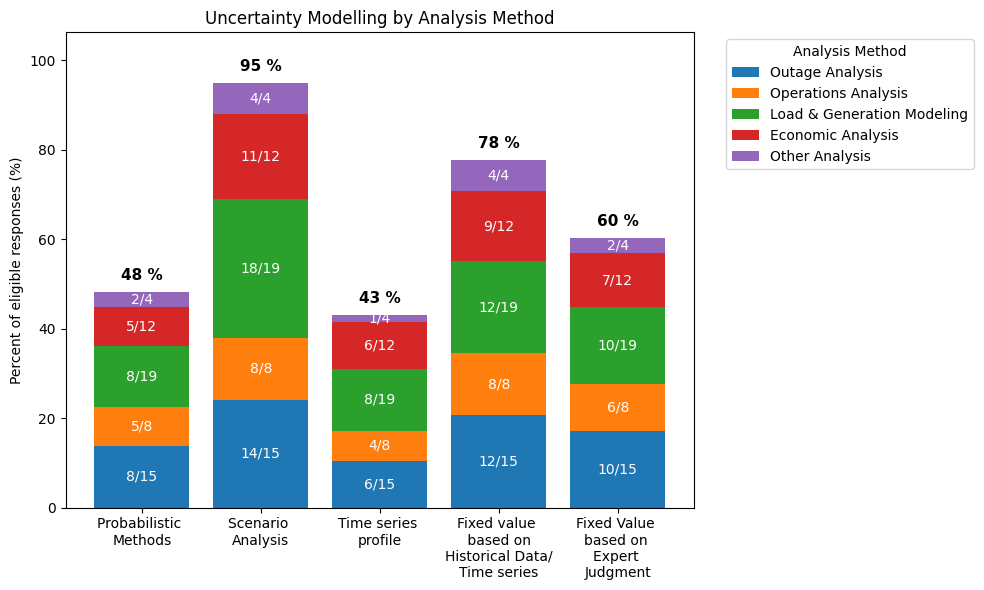

In [9]:
def plot_uncertainty_stacked_per_eligibility(df):
    # Define in the order you prefer:
    analyses = [k for k, v in ANALYSIS_MAPPINGS.items() if v !="None of These"] # where k is the column name, v is the display name
    unc_methods = ["Probabilistic Methods","Scenario Analysis","Time series profile","Fixed value based on Historical Data/Time series","Fixed Value based on Expert Judgment"]
    unc_methods_labels = ["Probabilistic \nMethods","Scenario \nAnalysis","Time series \nprofile","Fixed value \n based on \nHistorical Data/\nTime series","Fixed Value \nbased on \nExpert \nJudgment"]
    
    numer = np.zeros((len(unc_methods), len(analyses)), dtype=int) #matrix with uncertainty methods as rows, analyses as columns for the numerator
    denom = np.zeros((len(unc_methods), len(analyses)), dtype=int) #matrix with uncertainty methods as rows, analyses as columns for the denominator
    for j, acol in enumerate(analyses):
        # Eligible: respondents who answer any in analysis-group
        

        eligible = df[acol] ==1 if acol in df else np.zeros(lned(df),dtype=bool) # check if analysis column exists and create a boolean mask to filter eligible respondents (only elegible respondents will be counted)

        for i, u_method in enumerate(unc_methods):
            # All uncertainty cols for this method and this analysis type
            unc_cols = [
                col for col, val in UNCERTAINTY_GROUP_MAP.items() # find all uncertainty columns that match the current method
                if val == u_method and any(pcol.split('.')[0] in col for pcol in acol) # check if the uncertainty column is related to the current analysis type
            ]
            if not unc_cols: # if no uncertainty columns found for this method and analysis, skip
                continue
            # n/N: sum YES for this unc across analyses / sum eligible for that analysis
            numer[i,j] = (df[unc_cols].any(axis=1) & eligible).sum() # count how many respondents answered YES to any of the uncertainty columns for this method and analysis
            denom[i,j] = eligible.sum() # count how many respondents are eligible for this analysis type

    # Now, collapse across all analyses for "overall" bar: sum across columns (per method = ALL eligible for any analysis)
    numer_sum = numer.sum(axis=1)
    denom_sum = denom.sum(axis=1)
    total_pct = np.divide(numer_sum, denom_sum, out=np.zeros_like(numer_sum, dtype=float), where=denom_sum>0) * 100

    # --- Stacked Bar: each analysis as stack for every unc-method
    fig, ax = plt.subplots(figsize=(10,6))
    bottoms = np.zeros(len(unc_methods))
    for j, analysis in enumerate(analyses):
        aname= ANALYSIS_MAPPINGS[analysis]
        
        pct = np.divide(numer[:,j], denom_sum, out=np.zeros_like(numer[:,j], dtype=float), where=denom[:,j]>0) * 100
        bars = ax.bar(unc_methods_labels, pct, bottom=bottoms, label=aname)
        # label each segment with n/N
        for i in range(len(unc_methods)):
            if pct[i]>0.1:
                ax.text(i, bottoms[i]+pct[i]/2, f"{numer[i,j]}/{denom[i,j]}", ha="center", va="center", fontsize=10, color='white')#, fontweight="bold")
        bottoms += pct
    # Also add the overall bar value at the top
    for i, height in enumerate(bottoms):
        if denom_sum[i]>0:
            ax.text(i, height+2, f"{(numer_sum[i]/denom_sum[i])*100:.0f} %", ha="center", va="bottom", fontsize=11, fontweight="bold", color='k')

    ax.set_ylim(0, min(110, 1.12*bottoms.max()))
    #plt.xticks(rotation=00, ha='center')
    plt.ylabel("Percent of eligible responses (%)")
    plt.title("Uncertainty Modelling by Analysis Method")
    plt.legend(title="Analysis Method", bbox_to_anchor=(1.04,1), loc="upper left")
    plt.tight_layout()
    plt.show()
plot_uncertainty_stacked_per_eligibility(df)

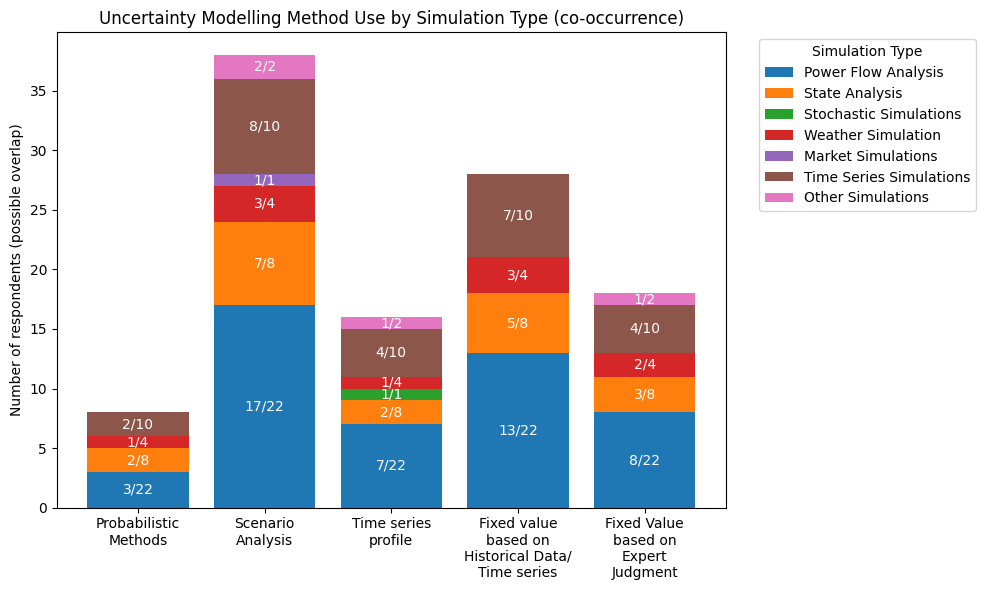

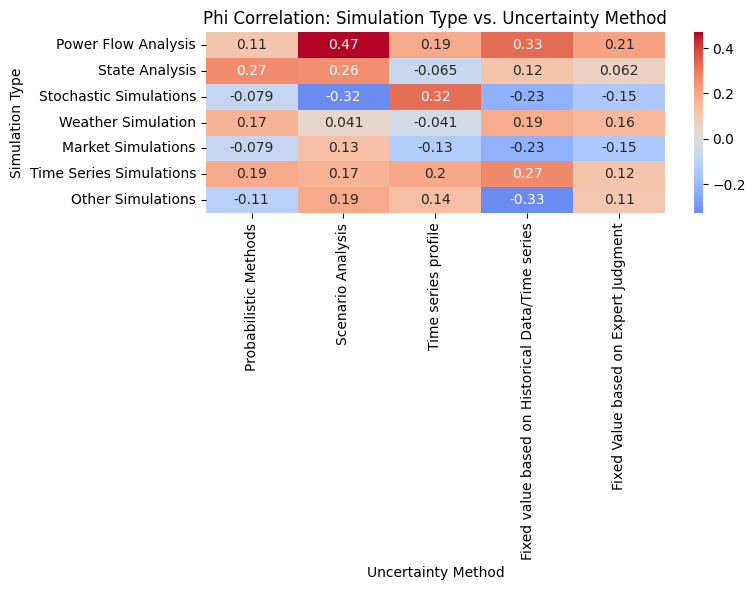

In [10]:
def plot_simulation_uncertainty_stacked_counts(df):
    sims = [k for k, v in SIMULATION_MAPPINGS.items() if v != "No Simulations"]
    unc_methods = [
        "Probabilistic Methods",
        "Scenario Analysis",
        "Time series profile",
        "Fixed value based on Historical Data/Time series",
        "Fixed Value based on Expert Judgment"
    ]
    unc_labels = [
        "Probabilistic\nMethods",
        "Scenario\nAnalysis",
        "Time series\nprofile",
        "Fixed value\nbased on\nHistorical Data/\nTime series",
        "Fixed Value\nbased on\nExpert\nJudgment"
    ]

    counts = np.zeros((len(unc_methods), len(sims)), dtype=int)
    eligible = np.zeros(len(sims), dtype=int)
    for j, scol in enumerate(sims):
        eligible_mask = df[scol] == 1 if scol in df else np.zeros(len(df), dtype=bool)
        eligible[j] = eligible_mask.sum()
        for i, u_method in enumerate(unc_methods):
            # Find all simulation uncertainty columns mapped to this method
            unc_cols = [
                col for col, val in UNCERTAINTY_GROUP_MAP.items()
                if val == u_method and "simulation" in col  # Only simulation-based uncertainty columns
            ]
            if not unc_cols: continue
            counts[i, j] = (df[unc_cols].any(axis=1) & eligible_mask).sum()

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10,6))
    bottoms = np.zeros(len(unc_methods))
    colors = plt.get_cmap("Set2")(np.linspace(0, 1, len(sims)))
    for j, scol in enumerate(sims):
        sname = SIMULATION_MAPPINGS[scol]
        bar_counts = counts[:, j]
        bars = ax.bar(unc_labels, bar_counts, bottom=bottoms, label=sname)#, color=colors[j])
        for i in range(len(unc_methods)):
            if bar_counts[i] > 0:
                ax.text(i, bottoms[i] + bar_counts[i] / 2, f"{bar_counts[i]}/{eligible[j]}",
                        ha="center", va="center", fontsize=10, color="white")
        bottoms += bar_counts
    ax.set_ylabel("Number of respondents (possible overlap)")
    plt.title("Uncertainty Modelling Method Use by Simulation Type (co-occurrence)")
    plt.legend(title="Simulation Type", bbox_to_anchor=(1.04,1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
def simulation_uncertainty_correlation_heatmap(df):
    import seaborn as sns

    sims = [k for k, v in SIMULATION_MAPPINGS.items() if v != "No Simulations"]
    unc_methods = [
        "Probabilistic Methods",
        "Scenario Analysis",
        "Time series profile",
        "Fixed value based on Historical Data/Time series",
        "Fixed Value based on Expert Judgment"
    ]

    matrix = np.zeros((len(sims), len(unc_methods)))
    for i, scol in enumerate(sims):
        sim_yes = df[scol] == 1 if scol in df else np.zeros(len(df), dtype=bool)
        for j, u_method in enumerate(unc_methods):
            unc_cols = [
                col for col, val in UNCERTAINTY_GROUP_MAP.items()
                if val == u_method and "simulation" in col
            ]
            if not unc_cols or not sim_yes.any(): continue
            method_yes = df[unc_cols].any(axis=1)
            # Phi coefficient (correlation between binary variables)
            a = sim_yes & method_yes
            b = sim_yes & ~method_yes
            c = ~sim_yes & method_yes
            d = ~sim_yes & ~method_yes
            n = len(df)
            ad = (a.sum()*d.sum())
            bc = (b.sum()*c.sum())
            den = np.sqrt((a.sum()+b.sum()) * (c.sum()+d.sum()) * (a.sum()+c.sum()) * (b.sum()+d.sum()))
            phi = ((a.sum()*d.sum() - b.sum()*c.sum()) / den) if den > 0 else np.nan
            matrix[i, j] = phi

    fig, ax = plt.subplots(figsize=(8,6))
    sns.heatmap(matrix, annot=True, xticklabels=unc_methods, yticklabels=[SIMULATION_MAPPINGS[k] for k in sims],
                cmap="coolwarm", center=0, ax=ax)
    plt.title("Phi Correlation: Simulation Type vs. Uncertainty Method")
    plt.xlabel("Uncertainty Method")
    plt.ylabel("Simulation Type")
    plt.tight_layout()
    plt.show()

plot_simulation_uncertainty_stacked_counts(df)
simulation_uncertainty_correlation_heatmap(df)

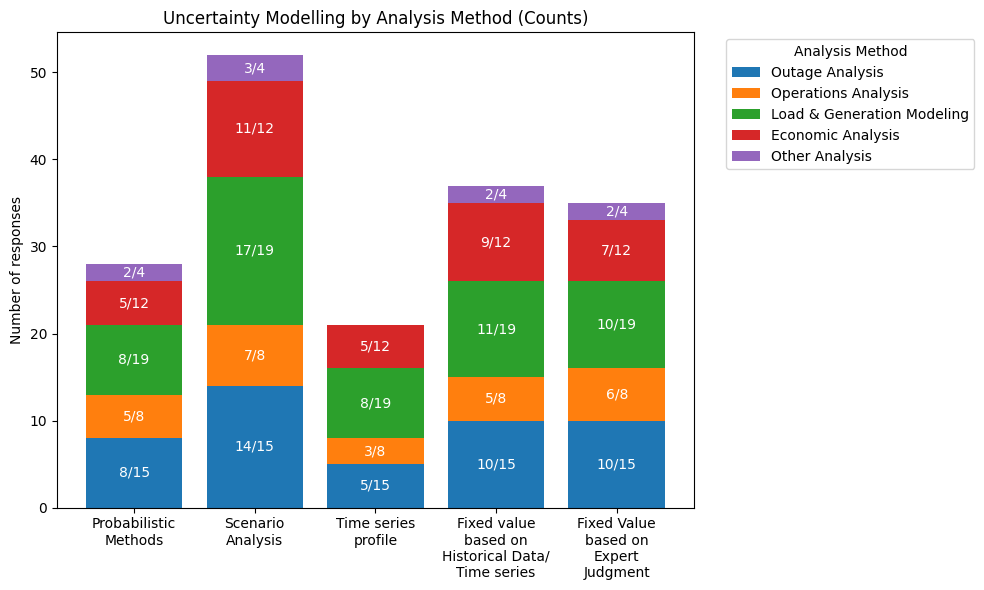

In [11]:
def plot_uncertainty_stacked_counts(df):
    # Only use meaningful atomic analysis (exclude 'None of These')
    analyses = [k for k, v in ANALYSIS_MAPPINGS.items() if v != "None of These"]
    unc_methods = [
        "Probabilistic Methods",
        "Scenario Analysis",
        "Time series profile",
        "Fixed value based on Historical Data/Time series",
        "Fixed Value based on Expert Judgment"
    ]
    unc_methods_labels = [
        "Probabilistic\nMethods",
        "Scenario\nAnalysis",
        "Time series\nprofile",
        "Fixed value\nbased on\nHistorical Data/\nTime series",
        "Fixed Value\nbased on\nExpert\nJudgment"
    ]

    numer = np.zeros((len(unc_methods), len(analyses)), dtype=int)
    denom = np.zeros((len(unc_methods), len(analyses)), dtype=int)
    for j, acol in enumerate(analyses):
        eligible = df[acol] == 1 if acol in df else np.zeros(len(df), dtype=bool)
        for i, u_method in enumerate(unc_methods):
            unc_cols = [
                col for col, val in UNCERTAINTY_GROUP_MAP.items()
                if val == u_method and acol.split('.')[0] in col
            ]
            if not unc_cols:
                continue
            numer[i, j] = (df[unc_cols].any(axis=1) & eligible).sum()
            denom[i, j] = eligible.sum()

    # Make the stacked barplot with counts only
    fig, ax = plt.subplots(figsize=(10, 6))
    bottoms = np.zeros(len(unc_methods))
    colors = plt.get_cmap("Set2")(np.linspace(0, 1, len(analyses)))
    for j, acol in enumerate(analyses):
        aname = ANALYSIS_MAPPINGS[acol]
        counts = numer[:, j]
        bars = ax.bar(unc_methods_labels, counts, bottom=bottoms, label=aname)#, color=colors[j])
        # label each segment with n/N (count/eligible)
        for i in range(len(unc_methods)):
            if counts[i] > 0:
                ax.text(i, bottoms[i] + counts[i] / 2, f"{counts[i]}/{denom[i, j]}",
                        ha="center", va="center", fontsize=10, color="white")
        bottoms += counts
    # y-axis, legend, and labels
    plt.xticks(rotation=0, ha='center')
    ax.set_ylabel("Number of responses")
    plt.title("Uncertainty Modelling by Analysis Method (Counts)")
    plt.legend(title="Analysis Method", bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
plot_uncertainty_stacked_counts(df)

In [12]:
### new method
import matplotlib.pyplot as plt
import numpy as np


def plot_uncertainty_stacked_atomic(df):
    unc_methods = ["Probabilistic Methods","Scenario Analysis","Historical Data","Expert Judgment"]
    analyses = list(ANALYSIS_MAPPINGS.values())
    numer = np.zeros((len(unc_methods), len(analyses)), dtype=int)
    denom = np.zeros((len(unc_methods), len(analyses)), dtype=int)
    denom_total = 0

    for j, (acol, aname) in enumerate(ANALYSIS_MAPPINGS.items()):
        eligible = (df[acol] == 1) if acol in df else np.zeros(len(df), dtype=bool) # eligible for this analysis if they answered YES
        denom_total += eligible.sum()
        for i, u_method in enumerate(unc_methods):
            unc_cols = [
                col for col, val in UNCERTAINTY_GROUP_MAP.items()
                if val == u_method and acol.split('.')[0] in col # atomic analysis match   
            ]
            if not unc_cols: continue
            selected = df[unc_cols].any(axis=1) & eligible
            numer[i, j] = selected.sum()

    total_numer = numer.sum(axis=1)
    pct = numer / denom_total * 100
    fig, ax = plt.subplots(figsize=(10,6))
    bottoms = np.zeros(len(unc_methods))
    colors = plt.get_cmap("Set2")(np.linspace(0,1,len(analyses)))
    for j, aname in enumerate(analyses):
        bars = ax.bar(unc_methods, pct[:,j], bottom=bottoms, label=aname, color=colors[j])
        for i in range(len(unc_methods)):
            if numer[i,j]>0:
                ax.text(i, bottoms[i]+pct[i,j]/2, f"{numer[i,j]}/{denom[i,j]}", ha="center", va="center", fontsize=10)
        bottoms += pct[:,j]
    for i in range(len(unc_methods)):
        if bottoms[i]>0:
            ax.text(i, bottoms[i]+2, f"Total {total_numer[i]}/{denom_total}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    plt.xticks(rotation=18, ha='right')
    plt.ylim(0, min(110, 1.12*bottoms.max()))
    ax.set_ylabel("Percent of all eligible uncertainty answers (%)")
    ax.set_title("Uncertainty Methods by (Atomic) Analysis (normalized by all eligible opportunities)")
    plt.legend(title="Analysis Type", bbox_to_anchor=(1.04,1), loc="upper left")
    plt.tight_layout()
    plt.show()
    print(f"Each segment = YES for (method, analysis) / all YES opportunities (all respondents × all analyses); bar heights never exceed 100%.")


def plot_uncertainty_stacked_totalcorrect(df):
    unc_methods = ["Probabilistic Methods", "Scenario Analysis", "Historical Data", "Expert Judgment"]
    analyses = list(ANALYSIS_MAPPINGS.values())
    n_methods = len(unc_methods)
    n_analyses = len(analyses)
    numer = np.zeros((n_methods, n_analyses), dtype=int)
    denom_total = 0

    for j, (acol, aname) in enumerate(ANALYSIS_MAPPINGS.items()):
        eligible = (df[acol] == 1) if acol in df else np.zeros(len(df), dtype=bool)
        denom_total += eligible.sum()
        for i, u_method in enumerate(unc_methods):
            unc_cols = [
                col for col, val in UNCERTAINTY_GROUP_MAP.items()
                if val == u_method and acol.split('.')[0] in col
            ]
            if not unc_cols: continue
            selected = df[unc_cols].any(axis=1) & eligible
            numer[i, j] = selected.sum()

    total_numer = numer.sum(axis=1)
    pct = numer / denom_total * 100

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10,6))
    bottoms = np.zeros(len(unc_methods))
    colors = plt.get_cmap("Set2")(np.linspace(0,1,len(analyses)))
    for j, aname in enumerate(analyses):
        bars = ax.bar(unc_methods, pct[:,j], bottom=bottoms, label=aname, color=colors[j])
        for i in range(len(unc_methods)):
            if numer[i,j]>0:
                ax.text(i, bottoms[i]+pct[i,j]/2, f"{numer[i,j]}/{denom_total}", ha="center", va="center", fontsize=10)
        bottoms += pct[:,j]
    for i in range(len(unc_methods)):
        if bottoms[i]>0:
            ax.text(i, bottoms[i]+2, f"Total {total_numer[i]}/{denom_total}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    plt.xticks(rotation=18, ha='right')
    plt.ylim(0, min(110, 1.12*bottoms.max()))
    ax.set_ylabel("Percent of all eligible responses (%)")
    ax.set_title("Uncertainty Methods by Analysis (atomic; normalized by all eligible)")
    plt.legend(title="Analysis Type", bbox_to_anchor=(1.04,1), loc="upper left")
    plt.tight_layout()
    plt.show()



In [13]:
# Main Sankey
flows, labels = create_main_sankey_flows_linear(df)
fig1 = build_main_sankey(flows, labels)
fig1.show()


In [14]:
# Detailed software Sankey
flows_detail = create_detailed_software_flows(df)
fig2 = build_detailed_software_sankey(flows_detail)
fig2.show()

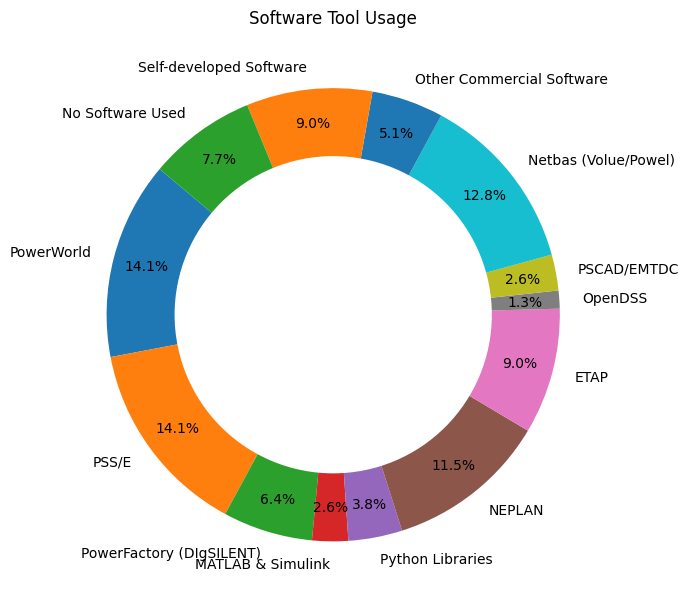

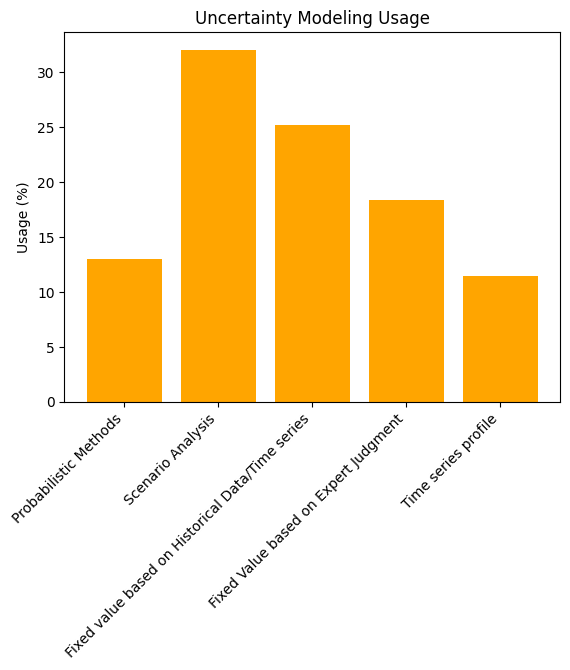

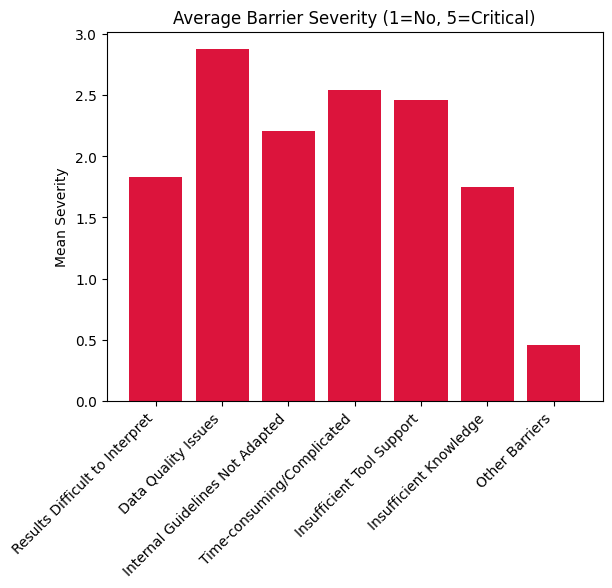

In [22]:


# Pie chart of software distribution
create_software_pie_chart(df)
#plot_uncertainty_bars(df)
#plot_uncertainty_stacked_per_eligibility(df)
#plot_uncertainty_stacked_atomic(df)
#plot_uncertainty_stacked_totalcorrect(df)
# Uncertainty/barrier barplots
create_uncertainty_barriers_bars(df)

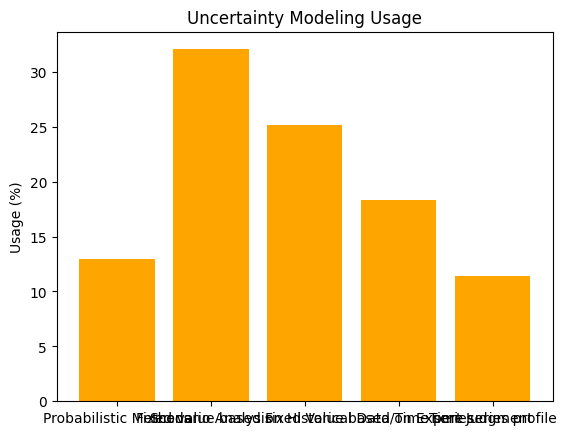

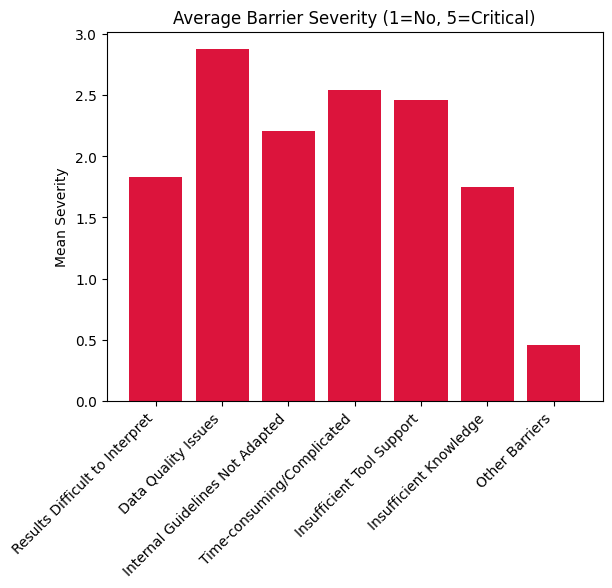

In [20]:
create_uncertainty_barriers_bars(df)

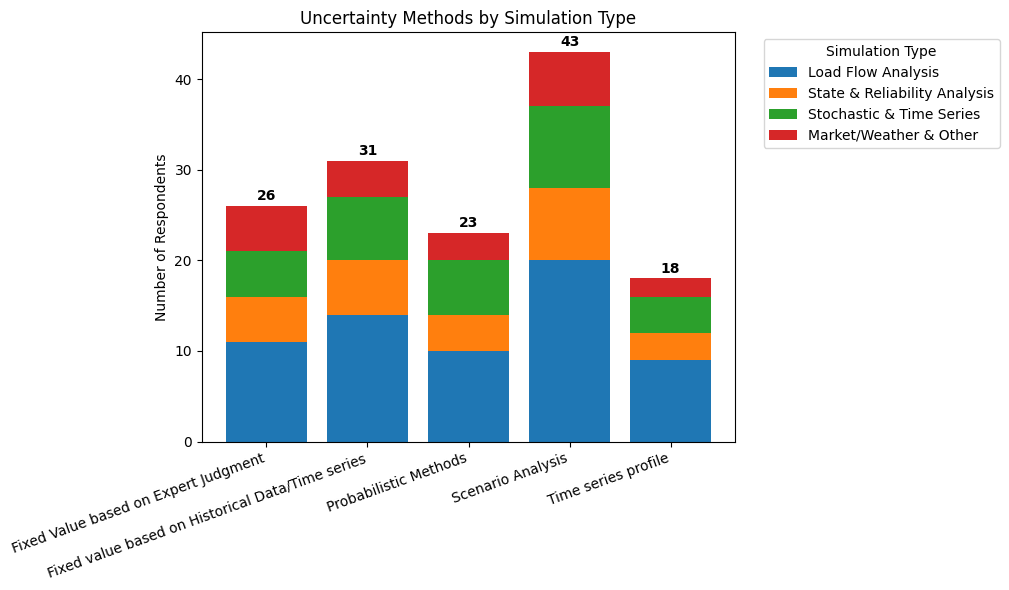

KeyError: "None of [Index(['u'], dtype='object')] are in the [columns]"

In [16]:
plot_uncertainty_stacked(df, stack_on='simulation')   # stack by simulation type
plot_uncertainty_stacked(df, stack_on='analysis')     # stack by analysis method


In [ ]:
def get_main_choice(df, columns, labels):
    result = []
    for _, row in df.iterrows():
        main = "None"
        for col in columns:
            if col in df.columns and row[col] == 1:
                main = labels.get(col, col)
                break
        result.append(main)
    return result

def parallel_categories_mainpaths(df):
    dec_map = {c: g for g, cs in DECISION_GROUPS.items() for c in cs}
    anal_map = ANALYSIS_MAPPINGS # now atomic
    sim_map = {c: g for g, cs in SIMULATION_GROUPS.items() for c in cs}
    pdata = pd.DataFrame({
        'role': get_main_choice(df, list(ROLE_MAPPINGS.keys()), ROLE_MAPPINGS),
        'decision': get_main_choice(df, [c for cs in DECISION_GROUPS.values() for c in cs], dec_map),
        'analysis': get_main_choice(df, list(ANALYSIS_MAPPINGS.keys()), anal_map),
        'simulation': get_main_choice(df, [c for cs in SIMULATION_GROUPS.values() for c in cs], sim_map),
        'uncertainty': get_main_choice(df, list(UNCERTAINTY_GROUP_MAP.keys()), UNCERTAINTY_GROUP_MAP),
        'barrier': get_main_choice(df, list(BARRIERS_MAPPINGS.keys()), BARRIERS_MAPPINGS)
    })
    import plotly.express as px
    fig = px.parallel_categories(
        pdata, 
        dimensions=["role", "decision", "analysis", "simulation", "uncertainty", "barrier"],
        color="role"
    )
    fig.update_layout(title="Parallel Categories: Main Path Choices (Atomic Analysis)")
    fig.show()
parallel_categories_mainpaths(df)


ValueError: 
    Invalid element(s) received for the 'color' property of parcats.line
        Invalid elements include: ['Operations Planner', 'Connection Manager', 'Power System Analyst', 'Power System Analyst', 'Operations Operator', 'Other Role', 'Power System Analyst', 'Power System Analyst', 'Power System Analyst', 'Power System Analyst']

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color: see https://plotly.com/python/css-colors/ for a list
      - A number that will be interpreted as a color
        according to parcats.line.colorscale
      - A list or array of any of the above

In [ ]:
def build_full_parcoords_df(df):
    rows = []
    for idx, row in df.iterrows():
        for rcol, rlab in ROLE_MAPPINGS.items():
            if rcol in df and row[rcol]==1:
                for dec_g, dec_cols in DECISION_GROUPS.items():
                    for dcol in dec_cols:
                        if dcol in df and row[dcol]==1:
                            for anal_g, anal_cols in ANALYSIS_MAPPINGS.items():
                                for acol in anal_cols:
                                    if acol in df and row[acol]==1:
                                        for sim_g, sim_cols in SIMULATION_GROUPS.items():
                                            for scol in sim_cols:
                                                if scol in df and row[scol]==1:
                                                    for ucol, ulag in UNCERTAINTY_GROUP_MAP.items():
                                                        if ucol in df and row[ucol]==1:
                                                            for bcol, blag in BARRIERS_MAPPINGS.items():
                                                                if bcol in df and row[bcol]>=4:
                                                                    rows.append({
                                                                        "role": rlab,
                                                                        "decision": dec_g,
                                                                        "analysis": anal_g,
                                                                        "simulation": sim_g,
                                                                        "uncertainty": ulag,
                                                                        "barrier": blag
                                                                    })
    return pd.DataFrame(rows)

pcat_df = build_full_parcoords_df(df)
if len(pcat_df)>0:
    fig = px.parallel_categories(
        pcat_df.sample(300) if len(pcat_df)>300 else pcat_df,
        dimensions=["role","decision","analysis","simulation","uncertainty","barrier"],
        labels={k: k.title() for k in pcat_df.columns}
    )
    fig.update_layout(title="Parallel Categories: All Selected Paths (subset for readability)")
    fig.show()
    print(len(pcat_df), "valid cross-selections found in data.")
else:
    print("No valid cross-selections found in data.")


14407 valid cross-selections found in data.


In [ ]:
from collections import defaultdict
import pandas as pd
import plotly.express as px

# Build a dataframe for parallel categories (one row per respondent)
def build_parallel_categories_df(df):
    # For each respondent, map the highest-ranking (or any "Yes"/selected) in each group
    records = []
    for idx, row in df.iterrows():
        # pick first True in each group (if multiple are checked, you may want to adapt this!)
        def pick(mapping):
            for col, label in mapping.items():
                if col in df.columns and row[col]==1:
                    return label
            return "None"
        def pick_group(group):
            for col in group:
                if col in df.columns and row[col]==1:
                    return col  # returns colname
            return "None"
        # Roles
        role = pick(ROLE_MAPPINGS)
        # Decision (flatten combined groups built earlier)
        decision = None
        for gname,gcols in DECISION_GROUPS.items():
            for col in gcols:
                if col in df.columns and row[col]==1:
                    decision = gname; break
            if decision: break
        if not decision: decision = "None"
        # Analysis
        analysis = None
        for gname,gcols in ANALYSIS_MAPPINGS.items():
            for col in gcols:
                if col in df.columns and row[col]==1:
                    analysis = gname; break
            if analysis: break
        if not analysis: analysis = "None"
        # Simulation
        simulation = None
        for gname,gcols in SIMULATION_GROUPS.items():
            for col in gcols:
                if col in df.columns and row[col]==1:
                    simulation = gname; break
            if simulation: break
        if not simulation: simulation = "None"
        # Uncertainty
        uncertainty = None
        for col, label in UNCERTAINTY_GROUP_MAP.items():
            if col in df.columns and row[col]==1:
                uncertainty = label; break
        if not uncertainty: uncertainty = "None"
        # Barriers
        barrier = None
        for col,label in BARRIERS_MAPPINGS.items():
            if col in df.columns and (row[col] >= 4):
                barrier = label; break
        if not barrier: barrier = "None"
        records.append(dict(role=role, decision=decision, analysis=analysis,
                            simulation=simulation, uncertainty=uncertainty, barrier=barrier))
    return pd.DataFrame(records)

# Build dataframe and plot
pdata = build_parallel_categories_df(df)
fig = px.parallel_categories(
    pdata,
    dimensions=["role","decision","analysis","simulation","uncertainty","barrier"],
    color="role",  # or any variable of interest, or no color
    width=1100, height=700,
    labels={k:k.title() for k in pdata.columns}
)
fig.update_layout(title="Parallel Coordinates / Parallel Categories Visualization of Profiles")
fig.show()


ValueError: 
    Invalid element(s) received for the 'color' property of parcats.line
        Invalid elements include: ['Operations Planner', 'Connection Manager', 'Power System Analyst', 'Power System Analyst', 'Operations Operator', 'Other Role', 'Power System Analyst', 'Power System Analyst', 'Power System Analyst', 'Power System Analyst']

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color: see https://plotly.com/python/css-colors/ for a list
      - A number that will be interpreted as a color
        according to parcats.line.colorscale
      - A list or array of any of the above